# Morisco 2020 Hybrid FEA-PEEC: AC Loss ($k_{ih}$) 산출

**논문**: Morisco 2020, PhD Thesis (Cuvillier Verlag) — "Berechnung der Stromverdrängung in Mehrleiteranordnungen"  
**방법**: Hybrid FEA → PEEC (Partial Element Equivalent Circuit)  
**HYB 패키지**: `eMach/tools/loss/ACLOSS/HYB/`

## Pipeline 구조 (Morisco Ch.5 Fig.5.1 기반)
1. Motor-CAD `.mot`에서 형상/권선 정보 로드
2. Static FEM (uniform J) → B/H 시계열 export
3. Slot-wall boundary 자화전류 추출: eq.4.52 $k_{mag} = \frac{1}{\mu_0}(M_\nu - M_\xi)\times n_\theta$, eq.4.53 $i_{mag} = k_{mag}\cdot|w_\theta|$
4. Filament grid 생성 + Dirichlet Z-matrix 구성 (eq.3.166, R = 축방향 길이)
5. FFT 분해: $i_{mag}(t) \rightarrow \hat{I}_{mag}[n]$ (DC 제거, eq.4.83)
6. Per-harmonic PEEC solve: $Z(n\omega) \cdot i = V_{mag,n}$ with constraint $C^T i = I_{cond}$
7. Linear superposition: $P_{total} = \sum_n P_n$, $k_{ih} = P_{total}/P_{dc}$

## 핵심 수식 (Thesis Chapter 3-4)
- Dirichlet Green's function (eq.3.166): $L(\xi,\xi') = -\frac{\mu_0 l}{2\pi}[\ln|\xi-\xi'| - \frac{1}{2}\ln(|\xi|^2|\xi'|^2 - 2\xi\cdot\xi' + 1)]$
- PEEC solve (eq.4 system): $\mathbf{i}_\Lambda = Z_\Lambda^{-1} C (C^T Z_\Lambda^{-1} C)^{-1} \mathbf{I}$
- Surface magnetization current (eq.4.52-4.53)
- AC/DC ratio: $k_{ih} = P_{AC} / P_{DC}$

## 참고: Morisco의 한계
- p.144: "overestimates local magnetizations near conductor edges" (static FEM의 uniform J 가정)
- Morisco OP에서 1-4% → 우리 IPM에서 ~39x → R_dirichlet 경계조건 재검토 필요

## [1] Imports & 경로 설정

In [1]:
import pathlib, sys, importlib, time, re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, solve as np_solve

# ─── Repo root ───
repo_root = pathlib.Path.cwd().resolve()
while not (repo_root / "tools").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# HYB 패키지 (ACLOSS 폴더 기준)
acloss_root = repo_root / "tools" / "loss" / "ACLOSS"
if str(acloss_root) not in sys.path:
    sys.path.insert(0, str(acloss_root))

# ─── HYB 모듈 로드 ───
import HYB.filament as _fil
import HYB.impedance as _imp
import HYB.magnetization as _mag_ext
import HYB.solver as _sol
import HYB.loss as _loss
import HYB.morisco_pipeline as _pipe
for m in [_fil, _imp, _mag_ext, _sol, _loss, _pipe]:
    importlib.reload(m)
from HYB.filament import build_filament_grid, skin_depth, FilamentGrid
from HYB.impedance import build_impedance_matrix, build_connectivity_matrix
from HYB.solver import solve_peec, PEECResult
from HYB.loss import calculate_losses, LossResult
from HYB.magnetization import extract_magnetization_currents, extract_magnetization_fundamental, MagnetizationCurrent
from HYB.morisco_pipeline import MoriscoPipeline, MoriscoConfig

# ─── pyMCAD 파싱 ───
import tools.motorCAD.pyMCAD.magnetic_parse as _mparse
import tools.motorCAD.pyMCAD.magnetic as _mag
importlib.reload(_mparse); importlib.reload(_mag)
from tools.motorCAD.pyMCAD.magnetic import get_magnetic_timeseries_from_file

MU_0 = 4 * np.pi * 1e-7
print(f"✓ HYB + pyMCAD loaded from: {acloss_root}")

✓ HYB + pyMCAD loaded from: D:\KangDH\EveryMotor\eMach\tools\loss\ACLOSS


## [2] Motor-CAD에서 모터 파라미터 로드

`.mot` 파일에서 도체 형상, 적층장, 권선 정보를 읽습니다.  
Motor-CAD가 열려있지 않으면 수동 상수로 대체합니다.

In [2]:
# ─── Motor-CAD 연결 시도 → 형상 파라미터 로드 ───
try:
    import ansys.motorcad.core as pymotorcad
    mcad = pymotorcad.MotorCAD(open_new_instance=False)
    
    COND_WIDTH_MM = float(mcad.get_variable("Copper_Width"))
    COND_HEIGHT_MM = float(mcad.get_variable("Copper_Height"))
    ACTIVE_LENGTH_MM = float(mcad.get_variable("Stator_Lam_Length"))
    n_parallel = int(mcad.get_variable("ParallelPaths"))
    n_turns = int(mcad.get_variable("WindingLayers"))
    N_POLES = int(mcad.get_variable("Pole_Number"))
    print(f"✓ Motor-CAD 연결 성공")
    print(f"  Conductor: {COND_WIDTH_MM:.2f} × {COND_HEIGHT_MM:.2f} mm")
    print(f"  Active length: {ACTIVE_LENGTH_MM:.1f} mm")
    print(f"  Poles: {N_POLES}, Turns/cond: {n_turns}, Parallel: {n_parallel}")
    MCAD_AVAILABLE = True

except Exception as e:
    print(f"⚠ Motor-CAD 미연결: {e}")
    print("  → e10 기본값 사용")
    MCAD_AVAILABLE = False
    
    # e10 모터 기본값 (8-pole, 48-slot, hairpin 6-layer)
    COND_WIDTH_MM = 2.80    # tangential [mm]
    COND_HEIGHT_MM = 2.50   # radial [mm]
    ACTIVE_LENGTH_MM = 100.0  # [mm]
    N_POLES = 8
    n_turns = 6
    n_parallel = 1

# ─── SI 변환 & 파생 상수 ───
SIGMA_CU = 5.8e7              # Cu conductivity @ 20°C [S/m]
# Motor-CAD 정의: Copper_Width = tangential, Copper_Height = radial
# PEEC 정의: b = tangential width, h = radial height
h_m = COND_HEIGHT_MM * 1e-3   # radial height [m] (Motor-CAD "Height")
b_m = COND_WIDTH_MM * 1e-3    # tangential width [m] (Motor-CAD "Width")
L_a = ACTIVE_LENGTH_MM * 1e-3 # active length [m]   
POLE_PAIRS = N_POLES // 2
N_COND_PER_SLOT = n_turns     # 슬롯 내 도체 수 (radial stack)
I_rms = 460.0                 # RMS current [A]

# ─── MoriscoPipeline 생성 (kwargs 방식) ───
pipe = MoriscoPipeline(
    cond_width=b_m,
    cond_height=h_m,
    stack_length=L_a,
    sigma_copper=SIGMA_CU,
    n_poles=N_POLES,
    subdivision_ratio=0.15,
    dirichlet_radius=0.1275,  # Morisco 2019: R = l (axial length)
)
config = pipe.config  # MoriscoConfig 참조

print(f"\n─── Morisco PEEC Configuration ───")
print(f"  Dirichlet R = l = {0.1275*1e3:.0f} mm (axial length)")
print(f"  Conductor: {b_m*1e3:.2f} × {h_m*1e3:.2f} mm")
print(f"  Conductors/slot: {N_COND_PER_SLOT}")
print(f"  σ_Cu = {SIGMA_CU:.2e} S/m")

✓ Motor-CAD 연결 성공
  Conductor: 5.57 × 2.53 mm
  Active length: 150.0 mm
  Poles: 8, Turns/cond: 6, Parallel: 1

─── Morisco PEEC Configuration ───
  Dirichlet R = l = 128 mm (axial length)
  Conductor: 5.57 × 2.53 mm
  Conductors/slot: 6
  σ_Cu = 5.80e+07 S/m


## [3] FEA Export TXT 로드

`pyMotorCAD_Hybrid_AClossCode.ipynb`에서 생성된 `ACLossCalcExport` 디렉토리의 TXT 파일을 파싱합니다.  
- Ref (k=1.0), HalfSC (k=1.5), SC (k=2.0) 모델 지원
- Hybrid mode FEA: B-field timeseries (128 steps/period)

In [3]:
# ─── FEA Export TXT 파일 탐색 ───
export_root = Path(r"D:\KangDH\Thesis\e10\SLFEA\ACLossCalcExport")

found_txts = {}
if export_root.exists():
    for model_dir in export_root.iterdir():
        if not model_dir.is_dir():
            continue
        for mode_dir in model_dir.iterdir():
            if not mode_dir.is_dir():
                continue
            for txt in sorted(mode_dir.glob("*.txt")):
                key = f"{model_dir.name}/{mode_dir.name}/{txt.stem}"
                found_txts[key] = txt

if found_txts:
    print(f"✓ Found {len(found_txts)} TXT files:")
    for k in list(found_txts.keys())[:8]:
        print(f"  {k}")
    if len(found_txts) > 8:
        print(f"  ... ({len(found_txts)-8} more)")
else:
    print("⚠ TXT 파일을 찾지 못했습니다.")
    print(f"  경로: {export_root}")
    print("  → pyMotorCAD_Hybrid_AClossCode.ipynb [3b-exec] 셀을 먼저 실행하세요.")

✓ Found 16 TXT files:
  halfsc/fullfea/fullfea_halfsc_16000RPM
  halfsc/fullfea/fullfea_halfsc_2000RPM
  halfsc/fullfea/fullfea_halfsc_4000RPM
  halfsc/fullfea/fullfea_halfsc_8000RPM
  halfsc/hybrid/hybrid_halfsc_16000RPM
  halfsc/hybrid/hybrid_halfsc_2000RPM
  halfsc/hybrid/hybrid_halfsc_4000RPM
  halfsc/hybrid/hybrid_halfsc_8000RPM
  ... (8 more)


In [4]:
# ─── 분석 대상 선택 & 파싱 ───
# 여기서 모델/속도를 변경하세요
TARGET_MODEL = "halfsc"   # "ref", "halfsc", "sc"
TARGET_MODE = "hybrid"    # "hybrid", "fullfea"
TARGET_SPEED = 16000       # RPM
POLE_PAIRS=N_POLES/2
# 자동 키 매칭
target_key = None
for k in found_txts:
    if TARGET_MODEL in k and TARGET_MODE in k and str(TARGET_SPEED) in k:
        target_key = k
        break

if target_key is None:
    print(f"⚠ {TARGET_MODEL}/{TARGET_MODE}/{TARGET_SPEED}RPM 파일 없음")
    print(f"  사용 가능: {[k for k in found_txts.keys()][:5]}")
else:
    test_path = found_txts[target_key]
    print(f"─── 파싱: {target_key} ───")
    print(f"  File: {test_path.name}")
    
    ts_morisco = get_magnetic_timeseries_from_file(str(test_path))
    n_steps = len(ts_morisco.steps)
    freq = POLE_PAIRS * TARGET_SPEED / 60.0
    
    print(f"  Steps: {n_steps}")
    print(f"  Speed: {TARGET_SPEED} RPM → f_e = {freq:.0f} Hz")
    print(f"  Skin depth δ = {skin_depth(freq, SIGMA_CU)*1e3:.3f} mm")

─── 파싱: halfsc/hybrid/hybrid_halfsc_16000RPM ───
  File: hybrid_halfsc_16000RPM.txt
  Steps: 128
  Speed: 16000 RPM → f_e = 1067 Hz
  Skin depth δ = 1.431 mm


## [4] DXF 기반 도체 식별 + 슬롯 로컬 좌표 설정

**DXF polygon 기반 정밀 도체 식별** (`conductor_polygons_dxf.pkl`)  
- FEA 메시의 winding region은 균질화(insulation, gap, corner radius 포함)되어 도체 경계를 직접 구분 불가  
- DXF에서 추출한 도체 polygon → `MplPath.contains_points()`로 mesh element가 Cu 내부인지 판별  
- Polygon centroid = 정확한 도체 중심 → PEEC filament grid 좌표 기준  

Morisco 2019: 좌표를 도체 번들 중심 기준 **로컬**로 변환하여 $|\xi| \ll 1$ 조건을 충족합니다.

✓ DXF polygon 로드: 36개 도체
  슬롯 수: 6 (DXF 기반 자동 식별)
  도체/슬롯: [6, 6, 6, 6, 6, 6]
  → N_COND_PER_SLOT = 6 (DXF 기준)

  선택 슬롯 #0: 6개 도체
  DXF Cu 면적: 83.41 mm² (기대값: 84.46 mm²)
  도체 평균: 13.90 mm² (b×h = 14.08 mm²)

─── Mesh Element Classification ───
  Winding elements: 2040
  Copper (DXF):     1014 (49.7%)
  Insulation:       1026 (50.3%)
  Conductor IDs:    36 unique

─── 슬롯 로컬 좌표 (Slot #0) ───
  중심: (88.76, -77.84) mm
  도체 6개, radial span: 15.27 mm
  |ξ|_max = 0.05090 ≪ 1 ✓


C:\Users\user\AppData\Local\Temp\ipykernel_40620\1649670092.py:183: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  slot_cmap = cm.get_cmap('tab10', n_slots_found)
C:\Users\user\AppData\Local\Temp\ipykernel_40620\1649670092.py:222: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cond_cmap = cm.get_cmap('Set1', n_cond)
C:\Users\user\AppData\Local\Temp\ipykernel_40620\1649670092.py:272: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\1649670092.py:272: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  p

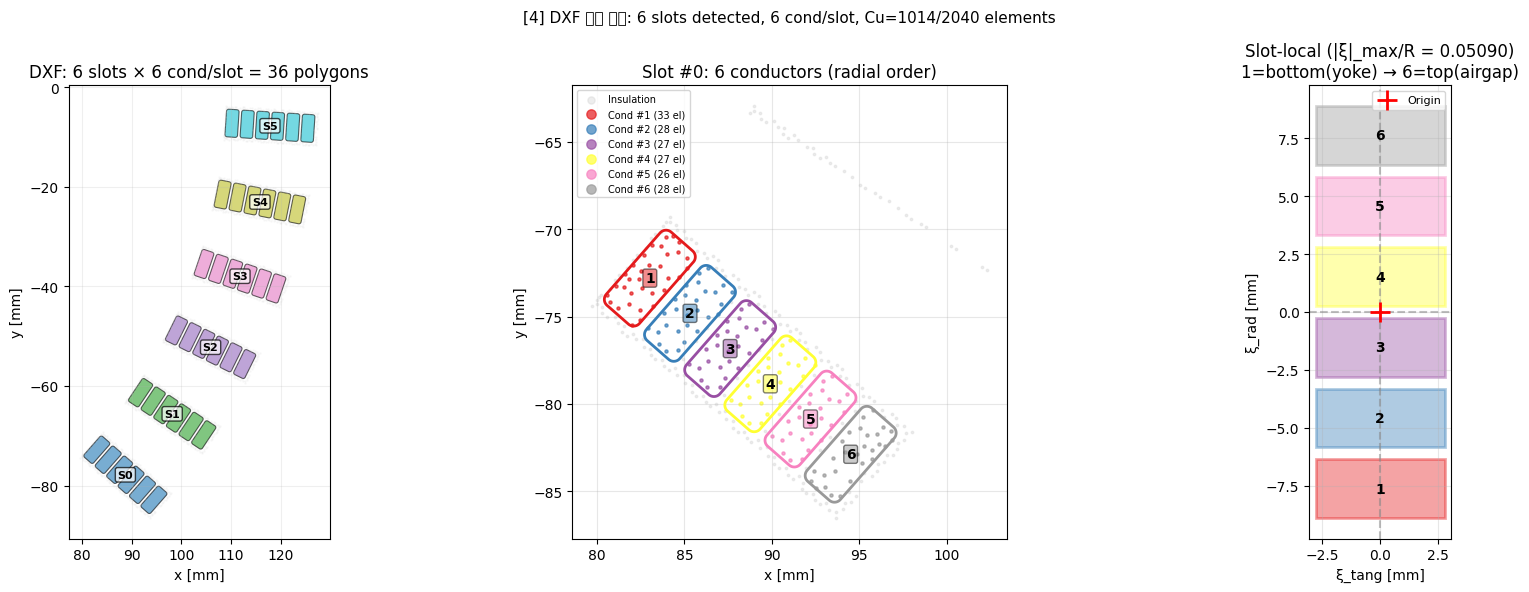


─── Slot Statistics ───
  Slot | Conds | Angle [°] | Cu Area [mm²]
  ─────┼───────┼───────────┼──────────────
     0 |     6 |    -41.25 |         83.41 ◀
     1 |     6 |    -33.75 |         83.41
     2 |     6 |    -26.25 |         83.41
     3 |     6 |    -18.75 |         83.41
     4 |     6 |    -11.25 |         83.41
     5 |     6 |     -3.75 |         83.41


In [5]:
# ─── DXF 기반 도체 식별 + 슬롯/도체 분류 + 시각화 ───
import pickle
from matplotlib.path import Path as MplPath
from matplotlib.patches import Rectangle, Polygon as MplPolygon
from matplotlib.colors import Normalize
import matplotlib.cm as cm

mr0 = ts_morisco.by_step[ts_morisco.steps[0]]

# ═══════════════════════════════════════════════════════════════
# (A) DXF 도체 polygon 로드
# ═══════════════════════════════════════════════════════════════
pkl_path = Path(r"D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\conductor_polygons_dxf.pkl")
with open(pkl_path, "rb") as f:
    dxf_data = pickle.load(f)

cond_polys_all = dxf_data["all_conductor_polygons_6slots"]
n_polys_total = len(cond_polys_all)
print(f"✓ DXF polygon 로드: {n_polys_total}개 도체")

# Polygon centroids & areas (mm 단위)
poly_centroids_mm = np.array([cp["vertices"].mean(axis=0) for cp in cond_polys_all])
poly_areas_mm2_all = np.array([cp.get("area_mm2", 0) for cp in cond_polys_all])
all_cond_paths = [MplPath(cp["vertices"]) for cp in cond_polys_all]

# ═══════════════════════════════════════════════════════════════
# (B) 슬롯 분류 (angular clustering by slot pitch)
# ═══════════════════════════════════════════════════════════════
N_SLOTS = 48
slot_pitch_rad = 2 * np.pi / N_SLOTS  # 7.5°

poly_angles = np.arctan2(poly_centroids_mm[:, 1], poly_centroids_mm[:, 0])
# Normalize angles to [0, 2π)
poly_angles_norm = poly_angles % (2 * np.pi)

# Sort by angle and group into slots
sorted_poly_idx = np.argsort(poly_angles_norm)
sorted_angles = poly_angles_norm[sorted_poly_idx]

# Detect slot boundaries: large angular gap between consecutive polygons
slot_assignments = np.zeros(n_polys_total, dtype=int)  # slot ID per polygon
slot_groups = {}  # slot_id → list of polygon indices

# Group by angular proximity
current_slot = 0
slot_start_angle = sorted_angles[0]
current_group = [sorted_poly_idx[0]]

for i in range(1, n_polys_total):
    idx = sorted_poly_idx[i]
    angle_diff = sorted_angles[i] - sorted_angles[i-1]
    # If gap > half slot pitch → new slot
    if angle_diff > slot_pitch_rad * 0.4:
        slot_groups[current_slot] = current_group
        for gi in current_group:
            slot_assignments[gi] = current_slot
        current_slot += 1
        current_group = [idx]
    else:
        current_group.append(idx)

# Last group
slot_groups[current_slot] = current_group
for gi in current_group:
    slot_assignments[gi] = current_slot

n_slots_found = len(slot_groups)
conds_per_slot = [len(v) for v in slot_groups.values()]
N_COND_PER_SLOT = max(conds_per_slot)  # Override Motor-CAD value

print(f"  슬롯 수: {n_slots_found} (DXF 기반 자동 식별)")
print(f"  도체/슬롯: {conds_per_slot}")
print(f"  → N_COND_PER_SLOT = {N_COND_PER_SLOT} (DXF 기준)")

# 각 슬롯 내 도체를 radial 순서로 정렬 (bottom→top)
slot_groups_sorted = {}
for sid, poly_indices in slot_groups.items():
    centroids = poly_centroids_mm[poly_indices]
    radii = np.sqrt(centroids[:, 0]**2 + centroids[:, 1]**2)
    radial_order = np.argsort(radii)
    slot_groups_sorted[sid] = [poly_indices[j] for j in radial_order]

# ═══════════════════════════════════════════════════════════════
# (C) 타겟 슬롯 선택 (첫 번째 슬롯)
# ═══════════════════════════════════════════════════════════════
TARGET_SLOT = 0
slot_poly_idx = np.array(slot_groups_sorted[TARGET_SLOT])
slot_polys = [cond_polys_all[i] for i in slot_poly_idx]
slot_paths = [MplPath(cp["vertices"]) for cp in slot_polys]

# DXF polygon centroid = 정확한 도체 중심 [mm → m]
cond_centers_all_mm = poly_centroids_mm
cond_centers = poly_centroids_mm[slot_poly_idx] * 1e-3  # [m]
n_cond = len(cond_centers)
n_cond_all = n_polys_total

# 면적 검증
slot_areas = poly_areas_mm2_all[slot_poly_idx]
if slot_areas.sum() > 0:
    expected_area = n_cond * b_m * h_m * 1e6
    print(f"\n  선택 슬롯 #{TARGET_SLOT}: {n_cond}개 도체")
    print(f"  DXF Cu 면적: {slot_areas.sum():.2f} mm² (기대값: {expected_area:.2f} mm²)")
    print(f"  도체 평균: {slot_areas.mean():.2f} mm² (b×h = {b_m*h_m*1e6:.2f} mm²)")

# ═══════════════════════════════════════════════════════════════
# (D) 슬롯 로컬 좌표 변환
#   회전 후: x → radial (slot axis 방향), y → tangential
#   PEEC 관례: ξ_tang (col 0), ξ_rad (col 1)
#   → swap columns: col0 = tangential, col1 = radial
# ═══════════════════════════════════════════════════════════════
slot_center_global = cond_centers.mean(axis=0)
cond_centers_local = cond_centers - slot_center_global

slot_angle_rad = np.arctan2(slot_center_global[1], slot_center_global[0])
cos_rot = np.cos(-slot_angle_rad)
sin_rot = np.sin(-slot_angle_rad)
# 회전: x_rot = radial, y_rot = tangential
x_rot = cond_centers_local[:, 0] * cos_rot - cond_centers_local[:, 1] * sin_rot
y_rot = cond_centers_local[:, 0] * sin_rot + cond_centers_local[:, 1] * cos_rot
# PEEC 관례로 swap: col0 = ξ_tang, col1 = ξ_rad
cond_local_rotated = np.column_stack([y_rot, x_rot])

# ═══════════════════════════════════════════════════════════════
# (E) FEA mesh element → per-conductor ID 할당
# ═══════════════════════════════════════════════════════════════
winding_elem_centroids_mm = []
winding_elem_indices = []
elem_global_idx = 0
for reg in mr0._regions:
    if not reg.elements:
        continue
    avg_j = np.mean([abs(getattr(e, 'j', 0) or 0) for e in reg.elements[:20]])
    if avg_j > 0.1:
        for el in reg.elements:
            cx_cy = mr0._element_centroid_xy(el)
            if cx_cy is not None:
                winding_elem_centroids_mm.append(cx_cy)
                winding_elem_indices.append(elem_global_idx)
            elem_global_idx += 1
    else:
        elem_global_idx += len(reg.elements)

winding_centroids_mm = np.array(winding_elem_centroids_mm)
n_winding_elems = len(winding_centroids_mm)

# is_copper (binary) + conductor_id (per-element → which polygon)
is_copper_winding = np.zeros(n_winding_elems, dtype=bool)
conductor_id_winding = np.full(n_winding_elems, -1, dtype=int)  # -1 = insulation

for ci, path in enumerate(all_cond_paths):
    inside = path.contains_points(winding_centroids_mm)
    is_copper_winding |= inside
    conductor_id_winding[inside] = ci

n_copper = is_copper_winding.sum()
n_insulation = n_winding_elems - n_copper

print(f"\n─── Mesh Element Classification ───")
print(f"  Winding elements: {n_winding_elems}")
print(f"  Copper (DXF):     {n_copper} ({100*n_copper/n_winding_elems:.1f}%)")
print(f"  Insulation:       {n_insulation} ({100*n_insulation/n_winding_elems:.1f}%)")
print(f"  Conductor IDs:    {len(np.unique(conductor_id_winding[conductor_id_winding>=0]))} unique")

# ═══════════════════════════════════════════════════════════════
# (F) Dirichlet validation
# ═══════════════════════════════════════════════════════════════
R_dirichlet = L_a
max_xi = np.max(np.linalg.norm(cond_local_rotated, axis=1)) / R_dirichlet
print(f"\n─── 슬롯 로컬 좌표 (Slot #{TARGET_SLOT}) ───")
print(f"  중심: ({slot_center_global[0]*1e3:.2f}, {slot_center_global[1]*1e3:.2f}) mm")
print(f"  도체 {n_cond}개, radial span: {(cond_local_rotated[:,1].max()-cond_local_rotated[:,1].min())*1e3:.2f} mm")
print(f"  |ξ|_max = {max_xi:.5f} ≪ 1 ✓")

slot_idx = slot_poly_idx  # 호환용

# ═══════════════════════════════════════════════════════════════
# (G) 시각화: 슬롯/도체 분류 (AClossCode 스타일)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- (1) 전체 뷰: 슬롯별 색상 분류 ---
ax = axes[0]
slot_cmap = cm.get_cmap('tab10', n_slots_found)
for sid, poly_indices in slot_groups_sorted.items():
    color = slot_cmap(sid)
    for pi in poly_indices:
        verts = cond_polys_all[pi]["vertices"]
        poly_patch = MplPolygon(verts, closed=True, linewidth=0.8,
                                edgecolor='black', facecolor=color, alpha=0.6)
        ax.add_patch(poly_patch)
    # Slot label at centroid of slot group
    slot_cx = poly_centroids_mm[poly_indices, 0].mean()
    slot_cy = poly_centroids_mm[poly_indices, 1].mean()
    ax.text(slot_cx, slot_cy, f'S{sid}', ha='center', va='center',
            fontsize=8, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Winding mesh background
ax.scatter(winding_centroids_mm[~is_copper_winding, 0],
           winding_centroids_mm[~is_copper_winding, 1],
           s=0.3, c='lightgray', alpha=0.2)
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title(f'DXF: {n_slots_found} slots × {N_COND_PER_SLOT} cond/slot = {n_polys_total} polygons')
ax.set_aspect('equal')
ax.autoscale()
ax.grid(True, alpha=0.2)

# --- (2) 선택 슬롯 확대: 도체별 번호 + Cu/insulation scatter ---
ax = axes[1]
# Insulation elements (in selected slot angular range)
slot_angle = np.arctan2(cond_centers[:, 1], cond_centers[:, 0]).mean()
elem_angles = np.arctan2(winding_centroids_mm[:, 1], winding_centroids_mm[:, 0])
angle_diff = np.abs(elem_angles - slot_angle)
angle_diff = np.minimum(angle_diff, 2*np.pi - angle_diff)
in_slot_view = angle_diff < slot_pitch_rad * 0.8

ax.scatter(winding_centroids_mm[in_slot_view & ~is_copper_winding, 0],
           winding_centroids_mm[in_slot_view & ~is_copper_winding, 1],
           s=3, c='lightgray', alpha=0.4, label=f'Insulation')

# Per-conductor coloring
cond_cmap = cm.get_cmap('Set1', n_cond)
for ci_local, pi_global in enumerate(slot_poly_idx):
    mask_ci = (conductor_id_winding == pi_global) & in_slot_view
    if mask_ci.sum() > 0:
        ax.scatter(winding_centroids_mm[mask_ci, 0],
                   winding_centroids_mm[mask_ci, 1],
                   s=5, c=[cond_cmap(ci_local)], alpha=0.7,
                   label=f'Cond #{ci_local+1} ({mask_ci.sum()} el)')
    # DXF polygon outline
    verts = cond_polys_all[pi_global]["vertices"]
    poly_patch = MplPolygon(verts, closed=True, linewidth=2,
                            edgecolor=cond_cmap(ci_local), facecolor='none', zorder=5)
    ax.add_patch(poly_patch)
    cx_p, cy_p = verts.mean(axis=0)
    ax.text(cx_p, cy_p, f'{ci_local+1}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='black', zorder=6,
            bbox=dict(boxstyle='round,pad=0.15', facecolor=cond_cmap(ci_local), alpha=0.5))

ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title(f'Slot #{TARGET_SLOT}: {n_cond} conductors (radial order)')
ax.set_aspect('equal')
ax.legend(fontsize=7, loc='upper left', markerscale=3)
ax.autoscale()
ax.grid(True, alpha=0.3)

# --- (3) Slot-local 좌표 + Dirichlet domain ---
ax = axes[2]
for ci_local in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci_local] * 1e3
    color = cond_cmap(ci_local)
    rect = Rectangle((cx_l - b_m/2*1e3, cy_l - h_m/2*1e3),
                     b_m*1e3, h_m*1e3,
                     linewidth=2, edgecolor=color, facecolor=color, alpha=0.4)
    ax.add_patch(rect)
    ax.text(cx_l, cy_l, f'{ci_local+1}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='black')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.plot(0, 0, 'r+', markersize=15, markeredgewidth=2, label='Origin')
ax.set_xlabel('ξ_tang [mm]'); ax.set_ylabel('ξ_rad [mm]')
ax.set_title(f'Slot-local (|ξ|_max/R = {max_xi:.5f})\n1=bottom(yoke) → {n_cond}=top(airgap)')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.autoscale()

plt.suptitle(f'[4] DXF 도체 식별: {n_slots_found} slots detected, '
             f'{N_COND_PER_SLOT} cond/slot, Cu={n_copper}/{n_winding_elems} elements',
             fontsize=11)
plt.tight_layout()
plt.show()

# ─── Per-slot statistics table ───
print(f"\n─── Slot Statistics ───")
print(f"  {'Slot':>4} | {'Conds':>5} | {'Angle [°]':>9} | {'Cu Area [mm²]':>13}")
print(f"  {'─'*4}─┼─{'─'*5}─┼─{'─'*9}─┼─{'─'*13}")
for sid, poly_indices in slot_groups_sorted.items():
    n_c = len(poly_indices)
    a_deg = np.degrees(np.arctan2(poly_centroids_mm[poly_indices, 1].mean(),
                                   poly_centroids_mm[poly_indices, 0].mean()))
    area = poly_areas_mm2_all[poly_indices].sum()
    marker = " ◀" if sid == TARGET_SLOT else ""
    print(f"  {sid:>4} | {n_c:>5} | {a_deg:>9.2f} | {area:>13.2f}{marker}")

C:\Users\user\AppData\Local\Temp\ipykernel_40620\3080468.py:80: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\3080468.py:80: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\3080468.py:80: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\3080468.py:80: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\3080468.py:80: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\3080468.py:80: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
 

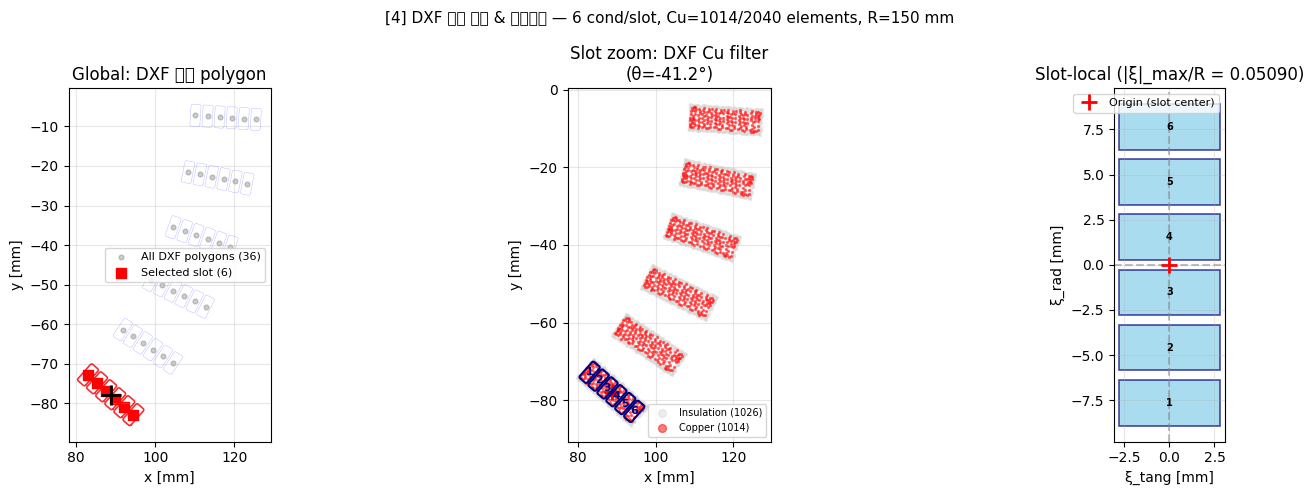

In [6]:
# ─── [4b] DXF 도체 식별 & 슬롯 로컬 좌표 시각화 ───
from matplotlib.patches import Rectangle, Polygon as MplPolygon

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) 전체 도체 polygon centroids (global) + 선택 슬롯
ax = axes[0]
ax.scatter(cond_centers_all_mm[:, 0], cond_centers_all_mm[:, 1],
           s=12, c='gray', alpha=0.4, label=f'All DXF polygons ({n_cond_all})')
ax.scatter(cond_centers_all_mm[slot_poly_idx, 0], cond_centers_all_mm[slot_poly_idx, 1],
           s=50, c='red', marker='s', label=f'Selected slot ({n_cond})')
# Draw DXF polygon outlines (all)
for cp in cond_polys_all:
    verts = np.vstack([cp["vertices"], cp["vertices"][0]])
    ax.plot(verts[:, 0], verts[:, 1], 'b-', linewidth=0.3, alpha=0.3)
# Highlight selected slot polygons
for cp in slot_polys:
    verts = np.vstack([cp["vertices"], cp["vertices"][0]])
    ax.plot(verts[:, 0], verts[:, 1], 'r-', linewidth=1.2, alpha=0.8)
ax.plot(slot_center_global[0]*1e3, slot_center_global[1]*1e3, 'k+', markersize=15, markeredgewidth=2)
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title('Global: DXF 도체 polygon')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (2) 선택 슬롯 zoom: DXF polygon + is_copper scatter
ax = axes[1]
# Winding elements colored by copper/insulation
ax.scatter(winding_centroids_mm[~is_copper_winding, 0],
           winding_centroids_mm[~is_copper_winding, 1],
           s=2, c='lightgray', alpha=0.4, label=f'Insulation ({n_insulation})')
ax.scatter(winding_centroids_mm[is_copper_winding, 0],
           winding_centroids_mm[is_copper_winding, 1],
           s=2, c='red', alpha=0.5, label=f'Copper ({n_copper})')
# DXF polygon outlines (selected slot)
for i, cp in enumerate(slot_polys):
    verts = cp["vertices"]
    poly_patch = MplPolygon(verts, closed=True, linewidth=1.5,
                            edgecolor='navy', facecolor='none', zorder=5)
    ax.add_patch(poly_patch)
    cx_p, cy_p = verts.mean(axis=0)
    ax.text(cx_p, cy_p, str(i+1), ha='center', va='center',
            fontsize=8, fontweight='bold', color='navy', zorder=6)
# Slot angle arrow
ax.plot(slot_center_global[0]*1e3, slot_center_global[1]*1e3, 'r+', markersize=12, markeredgewidth=2)
arrow_len = 3.0
ax.annotate('', xy=(slot_center_global[0]*1e3 + arrow_len*np.cos(slot_angle_rad),
                    slot_center_global[1]*1e3 + arrow_len*np.sin(slot_angle_rad)),
            xytext=(slot_center_global[0]*1e3, slot_center_global[1]*1e3),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title(f'Slot zoom: DXF Cu filter\n(θ={np.degrees(slot_angle_rad):.1f}°)')
ax.set_aspect('equal')
ax.legend(fontsize=7, markerscale=4)
ax.autoscale()
ax.grid(True, alpha=0.3)

# (3) 슬롯 로컬 좌표 + DXF polygon (transformed)
ax = axes[2]
for i in range(n_cond):
    cx_l, cy_l = cond_local_rotated[i] * 1e3  # m → mm
    rect = Rectangle((cx_l - b_m/2*1e3, cy_l - h_m/2*1e3),
                     b_m*1e3, h_m*1e3,
                     linewidth=1.2, edgecolor='navy', facecolor='skyblue', alpha=0.7)
    ax.add_patch(rect)
    ax.text(cx_l, cy_l, str(i+1), ha='center', va='center', fontsize=7, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.plot(0, 0, 'r+', markersize=12, markeredgewidth=2, label='Origin (slot center)')
ax.set_xlabel('ξ_tang [mm]'); ax.set_ylabel('ξ_rad [mm]')
ax.set_title(f'Slot-local (|ξ|_max/R = {max_xi:.5f})')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.autoscale()

plt.suptitle(f'[4] DXF 도체 식별 & 좌표변환 — {n_cond} cond/slot, '
             f'Cu={n_copper}/{n_winding_elems} elements, R={R_dirichlet*1e3:.0f} mm', fontsize=11)
plt.tight_layout()
plt.show()

## [5] 메시 데이터 추출 (전 타임스텝)

PEEC 자화전류 계산을 위해 전체 타임스텝의 B/H-field와 iron mask를 추출합니다.

In [7]:
# ─── 전체 타임스텝 B/H/iron 데이터 추출 ───
t0 = time.perf_counter()

# Node 좌표 (mm → m)
node_ids_sorted = sorted(mr0.node_xy.keys())
node_id_to_idx = {nid: i for i, nid in enumerate(node_ids_sorted)}
node_xy_arr = np.array([mr0.node_xy[nid] for nid in node_ids_sorted]) * 1e-3  # m
n_nodes = len(node_xy_arr)

# Element connectivity (triangle node indices)
elements = []
for reg in mr0._regions:
    for el in reg.elements:
        n1 = node_id_to_idx.get(el.node_1, -1)
        n2 = node_id_to_idx.get(el.node_2, -1)
        n3 = node_id_to_idx.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            elements.append((n1, n2, n3))
triangles_arr = np.array(elements, dtype=int)
n_elem_total = len(triangles_arr)

# Iron mask & μr (from first step)
iron_mask_arr = np.zeros(n_elem_total, dtype=bool)
mur_arr = np.ones(n_elem_total)
elem_idx = 0
for reg in mr0._regions:
    for el in reg.elements:
        n1 = node_id_to_idx.get(el.node_1, -1)
        n2 = node_id_to_idx.get(el.node_2, -1)
        n3 = node_id_to_idx.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            el_mur = getattr(el, 'mur', 1.0) or 1.0
            if el_mur > 1.5:
                iron_mask_arr[elem_idx] = True
                mur_arr[elem_idx] = el_mur
            elem_idx += 1

# ─── DXF 기반 is_copper mask (전체 element 배열 기준) ───
# element centroid 계산 (mm 단위 — DXF polygon과 동일 좌표)
elem_centroids_mm = node_xy_arr[triangles_arr].mean(axis=1) * 1e3  # m→mm
is_copper_all = np.zeros(n_elem_total, dtype=bool)
for path in all_cond_paths:
    is_copper_all |= path.contains_points(elem_centroids_mm)

n_copper_all = is_copper_all.sum()
print(f"  DXF copper mask (전체 mesh): {n_copper_all}/{n_elem_total} elements "
      f"({100*n_copper_all/n_elem_total:.1f}%)")

# B/H timeseries
bx_ts_all = np.zeros((n_steps, n_elem_total))
by_ts_all = np.zeros((n_steps, n_elem_total))
hx_ts_all = np.zeros((n_steps, n_elem_total))
hy_ts_all = np.zeros((n_steps, n_elem_total))

for si, step_key in enumerate(ts_morisco.steps):
    mr_step = ts_morisco.by_step[step_key]
    ei = 0
    for reg in mr_step._regions:
        for el in reg.elements:
            n1 = node_id_to_idx.get(el.node_1, -1)
            n2 = node_id_to_idx.get(el.node_2, -1)
            n3 = node_id_to_idx.get(el.node_3, -1)
            if n1 >= 0 and n2 >= 0 and n3 >= 0:
                bx_ts_all[si, ei] = getattr(el, 'bx', 0) or 0
                by_ts_all[si, ei] = getattr(el, 'by', 0) or 0
                hx_ts_all[si, ei] = getattr(el, 'hx', 0) or 0
                hy_ts_all[si, ei] = getattr(el, 'hy', 0) or 0
                ei += 1

t_extract = time.perf_counter() - t0
print(f"✓ 메시 데이터 추출: {t_extract:.1f}s")
print(f"  Nodes: {n_nodes}, Elements: {n_elem_total}")
print(f"  Iron elements: {iron_mask_arr.sum()} ({100*iron_mask_arr.sum()/n_elem_total:.1f}%)")
print(f"  Copper elements (DXF): {n_copper_all} ({100*n_copper_all/n_elem_total:.1f}%)")
print(f"  B timeseries: {bx_ts_all.shape} (steps × elements)")

  DXF copper mask (전체 mesh): 1014/18704 elements (5.4%)
✓ 메시 데이터 추출: 3.8s
  Nodes: 9623, Elements: 18704
  Iron elements: 10375 (55.5%)
  Copper elements (DXF): 1014 (5.4%)
  B timeseries: (128, 18704) (steps × elements)


In [8]:
import importlib
import tools.motorCAD.pyMCAD.magnetic_plot as mp
importlib.reload(mp)
import tools.motorCAD.pyMCAD.magnetic_model as mm
importlib.reload(mm)

# 기존 인스턴스에 새 메서드 주입
mr_type = type(ts_morisco.by_step[next(iter(ts_morisco.steps))])
mr_type.plot_mesh = mm.MagneticRegions.plot_mesh
mr_type.plot = mm.MagneticRegions.plot

ts_morisco.interactive_plot = lambda **kw: mp.interactive_magnetic_plot(ts_morisco, **kw)
ts_morisco.interactive_plot()

In [ ]:
from tools.motorCAD.pyMCAD.b_locus import interactive_b_locus_field_plot

# 전체 필드 locus (winding 영역만)
interactive_b_locus_field_plot(ts_morisco, element_stride=3)

# 또는 단일 요소 locus
# MagElement.plot_b_locus_from_timeseries(ts_morisco, tri_index=100, reg_code=winding_reg_codes[0])

In [ ]:
ts_morisco.interactive_quiver()

## [6] Filament Grid + 임피던스 행렬 구성

슬롯 로컬 좌표에서 filament grid를 생성하고, Dirichlet Green's function 기반 임피던스 행렬을 구성합니다.  
이 행렬은 전 타임스텝에 걸쳐 동일하므로 1회만 계산합니다.

In [9]:
# ─── Filament Grid 생성 (슬롯 로컬 좌표) ───
grid_local = build_filament_grid(
    conductor_centers=cond_local_rotated,
    cond_width=config.cond_width,
    cond_height=config.cond_height,
    length=R_dirichlet,
    frequency=freq,
    sigma=SIGMA_CU,
    subdivision_ratio=config.subdivision_ratio,
)

print(f"─── Filament Grid ───")
print(f"  Grid: {grid_local.nx}×{grid_local.ny} = {grid_local.n_filaments_per_cond}/cond")
print(f"  Total filaments: {grid_local.n_total}")
print(f"  δ = {skin_depth(freq, SIGMA_CU)*1e3:.3f} mm")
print(f"  Matrix: {grid_local.n_total}×{grid_local.n_total} ({grid_local.n_total**2*16/1e6:.1f} MB)")

# ─── 임피던스 행렬 (전 스텝 공통) ───
t0 = time.perf_counter()
Z = build_impedance_matrix(grid_local, freq, SIGMA_CU, slot_boundary_radius=R_dirichlet)
C = build_connectivity_matrix(grid_local)
Z_inv = np.linalg.inv(Z)
ZiC = Z_inv @ C
CZiC = C.T @ ZiC
t_build = time.perf_counter() - t0

print(f"\n─── 임피던스 행렬 구성: {t_build*1e3:.0f} ms ───")
print(f"  use_dirichlet=True, R={R_dirichlet*1e3:.0f} mm")

# ─── 도체 전류 설정 ───
# 실전에서는 Motor-CAD에서 각 도체별 전류를 읽어야 하지만,
# Morisco 2019 검증에서는 동일 전류를 인가합니다.
I_cond_val = I_rms * np.sqrt(2) / n_parallel  # peak per conductor [A]
I_test = np.full(n_cond, I_cond_val + 0j)  # 동상 (simplification)
print(f"\n  I_cond = {I_cond_val:.1f} A (peak), {n_cond} conductors")

─── Filament Grid ───
  Grid: 26×12 = 312/cond
  Total filaments: 1872
  δ = 1.431 mm
  Matrix: 1872×1872 (56.1 MB)

─── 임피던스 행렬 구성: 491 ms ───
  use_dirichlet=True, R=150 mm

  I_cond = 650.5 A (peak), 6 conductors


## [7] 슬롯 벽면 자화전류 필터 파라미터

Morisco 2019는 단일 슬롯만 모델링합니다.  
전체 iron boundary 중 **슬롯 tooth wall**에 해당하는 소스만 선별하는 필터를 정의합니다.

In [10]:
# ─── 슬롯 벽면 필터 파라미터 설정 ───
# 도체 위치 기준 radial/angular 범위
cond_r = np.linalg.norm(cond_centers, axis=1)  # global [m]
cond_angles = np.arctan2(cond_centers[:, 1], cond_centers[:, 0])

if MCAD_AVAILABLE:
    stator_bore_mm = float(mcad.get_variable("Stator_Bore"))
    slot_depth_mm = float(mcad.get_variable("Slot_Depth"))
    tooth_tip_depth_mm = float(mcad.get_variable("Tooth_Tip_Depth"))
else:
    # e10 기본값 (Motor-CAD 미연결 시)
    print('미연결')

# 슬롯 경계 R 계산
# R_slot_inner = Stator_Bore/2 + Tooth_Tip_Depth (슬롯 입구, tooth tip 이후)
# R_slot_outer = (Stator_Bore + 2*Slot_Depth) / 2 (= Stator_Bore/2 + Slot_Depth)
R_slot_inner_mm = stator_bore_mm / 2 + tooth_tip_depth_mm
R_slot_outer_mm = (stator_bore_mm + 2 * slot_depth_mm) / 2


# Radial band: 실제 slot geometry 사용 (도체 중심 ±2mm이 yoke edge를 자르는 문제 방지)
slot_r_min_m = R_slot_inner_mm * 1e-3 - 0.5e-3   # slot inner - 0.5mm margin
slot_r_max_m = R_slot_outer_mm * 1e-3 + 0.5e-3   # slot outer + 0.5mm margin

# Angular sector (슬롯 중심 ± 슬롯 피치/2)
slot_angle_center = np.mean(cond_angles)
slot_angle_span = np.radians(360.0 / 48)  # 48-slot motor

print(f"─── 슬롯 벽면 필터 ───")
print(f"  Radial band: [{slot_r_min_m*1e3:.1f}, {slot_r_max_m*1e3:.1f}] mm")
print(f"  Angular center: {np.degrees(slot_angle_center):.2f}°")
print(f"  Angular span: ±{np.degrees(slot_angle_span/2):.2f}° (slot pitch)")


def filter_slot_wall(mag, slot_r_min, slot_r_max, angle_center, angle_span):
    """자화전류 중 슬롯 벽면에 해당하는 소스만 필터링."""
    r = np.linalg.norm(mag.positions, axis=1)
    a = np.arctan2(mag.positions[:, 1], mag.positions[:, 0])
    r_mask = (r >= slot_r_min) & (r <= slot_r_max)
    a_diff = np.abs(a - angle_center)
    a_diff = np.minimum(a_diff, 2*np.pi - a_diff)
    a_mask = a_diff < (angle_span / 2)
    mask = r_mask & a_mask
    return mask


def to_slot_local(positions_global, center, rotation_angle):
    """전역 좌표 → 슬롯 로컬 좌표 변환.
    Returns: col 0 = ξ_tang (tangential), col 1 = ξ_rad (radial)
    """
    local = positions_global - center
    c, s = np.cos(-rotation_angle), np.sin(-rotation_angle)
    # 회전 후: x_rot = radial, y_rot = tangential
    x_rot = local[:, 0] * c - local[:, 1] * s
    y_rot = local[:, 0] * s + local[:, 1] * c
    # PEEC 관례: col 0 = tang, col 1 = rad
    return np.column_stack([y_rot, x_rot])


print(f"\n✓ filter_slot_wall(), to_slot_local() 정의 완료")

─── 슬롯 벽면 필터 ───
  Radial band: [107.9, 128.2] mm
  Angular center: -41.25°
  Angular span: ±3.75° (slot pitch)

✓ filter_slot_wall(), to_slot_local() 정의 완료


In [12]:
# ─── [5b] 슬롯 필터 보정: Stator Bore + Slot Depth 기반 ───
# 기존: slot_r_max_m = cond_r.max() + 2mm (임의)
# 수정: Motor-CAD 기하학 → 실제 슬롯 내외경

if MCAD_AVAILABLE:
    stator_bore_mm = float(mcad.get_variable("Stator_Bore"))
    slot_depth_mm = float(mcad.get_variable("Slot_Depth"))
    tooth_tip_depth_mm = float(mcad.get_variable("Tooth_Tip_Depth"))
else:
    # e10 기본값 (Motor-CAD 미연결 시)
    print('미연결')

# 슬롯 경계 R 계산
# R_slot_inner = Stator_Bore/2 + Tooth_Tip_Depth (슬롯 입구, tooth tip 이후)
# R_slot_outer = (Stator_Bore + 2*Slot_Depth) / 2 (= Stator_Bore/2 + Slot_Depth)
R_slot_inner_mm = stator_bore_mm / 2 + tooth_tip_depth_mm
R_slot_outer_mm = (stator_bore_mm + 2 * slot_depth_mm) / 2

print(f"═══ 슬롯 기하학 (Motor-CAD) ═══")
print(f"  Stator Bore Ø: {stator_bore_mm:.1f} mm → R_bore = {stator_bore_mm/2:.1f} mm")
print(f"  Slot Depth: {slot_depth_mm:.1f} mm")
print(f"  Tooth Tip Depth: {tooth_tip_depth_mm:.1f} mm")
print(f"  → R_slot_inner = {R_slot_inner_mm:.1f} mm")
print(f"  → R_slot_outer = {R_slot_outer_mm:.1f} mm")
print(f"       (= (Stator_Bore + 2×Slot_Depth) / 2)")

# 기존 필터 vs 보정 비교
old_r_min = slot_r_min_m * 1e3
old_r_max = slot_r_max_m * 1e3
print(f"\n  기존 필터: [{old_r_min:.1f}, {old_r_max:.1f}] mm (cond_r ± 2mm)")
print(f"  보정 필터: [{R_slot_inner_mm:.1f}, {R_slot_outer_mm:.1f}] mm (기하학 기반)")
print(f"  → 외측 확장: {R_slot_outer_mm - old_r_max:.1f} mm")
print(f"  → 내측 확장: {old_r_min - R_slot_inner_mm:.1f} mm")


═══ 슬롯 기하학 (Motor-CAD) ═══
  Stator Bore Ø: 213.8 mm → R_bore = 106.9 mm
  Slot Depth: 20.7 mm
  Tooth Tip Depth: 1.5 mm
  → R_slot_inner = 108.4 mm
  → R_slot_outer = 127.7 mm
       (= (Stator_Bore + 2×Slot_Depth) / 2)

  기존 필터: [107.9, 128.2] mm (cond_r ± 2mm)
  보정 필터: [108.4, 127.7] mm (기하학 기반)
  → 외측 확장: -0.5 mm
  → 내측 확장: -0.5 mm


In [13]:

# ─── 보정 적용 (mesh node가 boundary R에 있으므로 margin 필요) ───
slot_r_min_m = R_slot_inner_mm * 1e-3 - 0.5e-3
slot_r_max_m = R_slot_outer_mm * 1e-3 + 0.5e-3

# R_dirichlet도 슬롯 기하학에서 유도 가능:
# Morisco: R = l (axial). 여기서는 일단 유지하되 비교 출력
slot_local_half_tang = slot_angle_span * (stator_bore_mm/2 + slot_depth_mm/2) * 1e-3 / 2
slot_local_half_rad = slot_depth_mm * 1e-3 / 2
R_circumscribed_slot = np.sqrt(slot_local_half_tang**2 + slot_local_half_rad**2)
print(f"\n─── R_dirichlet 비교 ───")
print(f"  Morisco (R=l): {L_a*1e3:.0f} mm")
print(f"  Slot circumscribed: {R_circumscribed_slot*1e3:.1f} mm")
print(f"  현재 사용: R = {R_dirichlet*1e3:.0f} mm")



─── R_dirichlet 비교 ───
  Morisco (R=l): 150 mm
  Slot circumscribed: 12.9 mm
  현재 사용: R = 150 mm


In [17]:
# ─── 보정 필터로 재추출하여 비교 ───

# mag_viz / mask_viz / boundary_cache 자동 생성 (없을 경우)
if 'boundary_cache' not in globals():
    from HYB.magnetization import precompute_boundary_edges
    boundary_cache = precompute_boundary_edges(node_xy_arr, triangles_arr, iron_mask_arr)
    print(f"  ✓ boundary_cache 생성: {len(boundary_cache.edge_midpoints)} edges")

if 'mag_viz' not in globals():
    mag_viz = extract_magnetization_currents(
        node_xy=node_xy_arr, triangles=triangles_arr,
        bx=bx_ts_all[0], by=by_ts_all[0],
        hx=hx_ts_all[0], hy=hy_ts_all[0],
        mur=mur_arr, iron_mask=iron_mask_arr,
        axial_length=L_a, boundary_cache=boundary_cache,
    )
    print(f"  ✓ mag_viz 생성: {len(mag_viz.currents)} edges")

if 'mask_viz' not in globals():
    # 기존 필터 기준 마스크가 없으면 old 범위로 생성
    mask_viz = filter_slot_wall(mag_viz, old_r_min, old_r_max,
                                slot_angle_center, slot_angle_span)
    print(f"  ✓ mask_viz 생성(기존 필터): {mask_viz.sum()} edges")

mask_new = filter_slot_wall(mag_viz, slot_r_min_m, slot_r_max_m,
                            slot_angle_center, slot_angle_span)
n_new = mask_new.sum()
n_old = mask_viz.sum()
print(f"\n─── 필터 결과 비교 (Step 0) ───")
print(f"  기존 필터: {n_old} edges")
print(f"  보정 필터: {n_new} edges (+{n_new - n_old})")

# 새로 추가된 edge의 위치 분석
if n_new > n_old:
    new_edges = mask_new & ~mask_viz
    new_pos = mag_viz.positions[new_edges]
    new_cur = np.abs(mag_viz.currents[new_edges])
    new_r = np.linalg.norm(new_pos, axis=1) * 1e3
    print(f"  새로 포함된 edges:")
    print(f"    R range: [{new_r.min():.1f}, {new_r.max():.1f}] mm")
    print(f"    |i_mag| range: [{new_cur.min():.1f}, {new_cur.max():.1f}] A")
    print(f"    |i_mag| mean: {new_cur.mean():.1f} A")

    # 이들이 외측(yoke) vs 내측(bore) 구분
    new_r_center = (R_slot_inner_mm + R_slot_outer_mm) / 2
    is_outer_new = new_r > new_r_center
    is_inner_new = new_r <= new_r_center
    if is_outer_new.sum() > 0:
        print(f"    → 외측(yoke쪽): {is_outer_new.sum()} edges, "
              f"|i_mag| mean={new_cur[is_outer_new].mean():.1f} A")
    if is_inner_new.sum() > 0:
        print(f"    → 내측(bore쪽): {is_inner_new.sum()} edges, "
              f"|i_mag| mean={new_cur[is_inner_new].mean():.1f} A")

# mask_viz 업데이트 (이후 셀에서 사용)
mask_viz = mask_new
print(f"\n✓ slot_r_min_m={slot_r_min_m*1e3:.1f}mm, slot_r_max_m={slot_r_max_m*1e3:.1f}mm 적용 완료")


─── 필터 결과 비교 (Step 0) ───
  기존 필터: 100 edges
  보정 필터: 100 edges (+0)

✓ slot_r_min_m=107.9mm, slot_r_max_m=128.2mm 적용 완료


In [18]:
# 새로 추가된 edge의 위치 분석
if n_new > n_old:
    new_edges = mask_new & ~mask_viz
    new_pos = mag_viz.positions[new_edges]
    new_cur = np.abs(mag_viz.currents[new_edges])
    new_r = np.linalg.norm(new_pos, axis=1) * 1e3
    print(f"  새로 포함된 edges:")
    print(f"    R range: [{new_r.min():.1f}, {new_r.max():.1f}] mm")
    print(f"    |i_mag| range: [{new_cur.min():.1f}, {new_cur.max():.1f}] A")
    print(f"    |i_mag| mean: {new_cur.mean():.1f} A")
    
    # 이들이 외측(yoke) vs 내측(bore) 구분
    new_r_center = (R_slot_inner_mm + R_slot_outer_mm) / 2
    is_outer_new = new_r > new_r_center
    is_inner_new = new_r <= new_r_center
    if is_outer_new.sum() > 0:
        print(f"    → 외측(yoke쪽): {is_outer_new.sum()} edges, "
              f"|i_mag| mean={new_cur[is_outer_new].mean():.1f} A")
    if is_inner_new.sum() > 0:
        print(f"    → 내측(bore쪽): {is_inner_new.sum()} edges, "
              f"|i_mag| mean={new_cur[is_inner_new].mean():.1f} A")

# mask_viz 업데이트 (이후 셀에서 사용)
mask_viz = mask_new
print(f"\n✓ slot_r_min_m={slot_r_min_m*1e3:.1f}mm, slot_r_max_m={slot_r_max_m*1e3:.1f}mm 적용 완료")


✓ slot_r_min_m=107.9mm, slot_r_max_m=128.2mm 적용 완료


═══ [5c] i_mag 부호 진단 (Step 0) ═══
  필터된 edge 수: 100
  분류: Outer(yoke)=26, Inner(bore)=28, Side=46

─── i_mag (실수부) 부호 분석 ───
  Outer(yoke)    : n= 26, positive= 26, negative=  0, mean=+619.3 A, sum=+16102.3 A
  Inner(bore)    : n= 28, positive= 24, negative=  4, mean=+344.7 A, sum=+9652.7 A
  Side(tooth)    : n= 46, positive= 26, negative= 20, mean=+289.9 A, sum=+13335.8 A

─── V_mag 기여 분해 (영역별) ───
  ALL            : |V_mag| RMS=23691.74 mV, max=25790.42 mV, Re(V) mean=0 μV
  Outer(yoke)    : |V_mag| RMS=9583.67 mV, max=13495.65 mV, Re(V) mean=0 μV
  Inner(bore)    : |V_mag| RMS=5753.83 mV, max=8644.11 mV, Re(V) mean=0 μV
  Side(tooth)    : |V_mag| RMS=8685.22 mV, max=11131.76 mV, Re(V) mean=0 μV


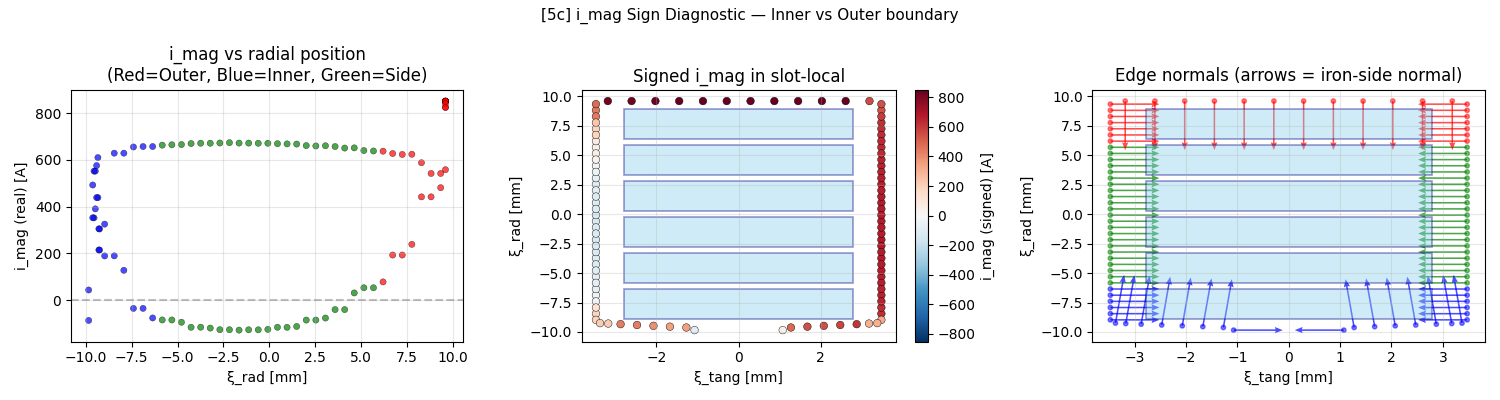


════════════════════════════════════════════════════════════
  Σi_mag(outer) = +16102.3 A
  Σi_mag(inner) = +9652.7 A
  Σi_mag(total) = +39090.8 A
  상쇄비율: |outer+inner|/max(|outer|,|inner|) = 159.9%
  (0%=완전상쇄, 200%=완전합산)
════════════════════════════════════════════════════════════


In [19]:
# ─── [5c] 외측/내측 i_mag 부호 진단 — V_mag 상쇄 여부 확인 ───
# 핵심 가설: 외측(yoke) vs 내측(bore) 벽면의 i_mag 부호가 맞으면 V_mag가 부분 상쇄됨
#            부호 오류 시 V_mag가 합산 → 과대 k_ih

from HYB.magnetization import precompute_boundary_edges, BoundaryEdgeCache

# boundary_cache가 없으면 여기서 생성
if 'boundary_cache' not in dir():
    boundary_cache = precompute_boundary_edges(node_xy_arr, triangles_arr, iron_mask_arr)
    print(f"  ✓ boundary_cache 생성: {len(boundary_cache.edge_midpoints)} edges")

# Step 0 기준, 보정 필터 적용
mag_step_diag = extract_magnetization_currents(
    node_xy=node_xy_arr, triangles=triangles_arr,
    bx=bx_ts_all[0], by=by_ts_all[0],
    hx=hx_ts_all[0], hy=hy_ts_all[0],
    mur=mur_arr, iron_mask=iron_mask_arr,
    axial_length=L_a, boundary_cache=boundary_cache,
)
mask_diag = filter_slot_wall(mag_step_diag, slot_r_min_m, slot_r_max_m,
                             slot_angle_center, slot_angle_span)

pos_filt = mag_step_diag.positions[mask_diag]
cur_filt = mag_step_diag.currents[mask_diag]  # COMPLEX (signed)
normals_filt = mag_step_diag.edge_normals[mask_diag]

# Slot-local 변환
pos_local_diag = to_slot_local(pos_filt, slot_center_global, slot_angle_rad)

# Inner vs Outer 분류 (radial position in local coords)
rad_local = pos_local_diag[:, 1]  # ξ_rad
tang_local = pos_local_diag[:, 0]  # ξ_tang

# 분류: outer = top 20%, inner = bottom 20%, side = 나머지
rad_range_d = rad_local.max() - rad_local.min()
outer_thresh = rad_local.max() - rad_range_d * 0.2
inner_thresh = rad_local.min() + rad_range_d * 0.2

is_outer_d = rad_local > outer_thresh
is_inner_d = rad_local < inner_thresh
is_side_d = ~is_outer_d & ~is_inner_d

print(f"═══ [5c] i_mag 부호 진단 (Step 0) ═══")
print(f"  필터된 edge 수: {mask_diag.sum()}")
print(f"  분류: Outer(yoke)={is_outer_d.sum()}, Inner(bore)={is_inner_d.sum()}, Side={is_side_d.sum()}")

# i_mag 부호 분석 (실수부만 — Step 0은 정상상태)
cur_real = cur_filt.real

print(f"\n─── i_mag (실수부) 부호 분석 ───")
for label, mask_d in [("Outer(yoke)", is_outer_d), 
                       ("Inner(bore)", is_inner_d),
                       ("Side(tooth)", is_side_d)]:
    if mask_d.sum() == 0:
        continue
    vals = cur_real[mask_d]
    n_pos = (vals > 0).sum()
    n_neg = (vals < 0).sum()
    print(f"  {label:15s}: n={mask_d.sum():3d}, "
          f"positive={n_pos:3d}, negative={n_neg:3d}, "
          f"mean={vals.mean():+.1f} A, sum={vals.sum():+.1f} A")

# ─── V_mag 기여 분해: 각 영역이 filament에 미치는 전압 ───
print(f"\n─── V_mag 기여 분해 (영역별) ───")

# V_mag를 영역별로 분리 계산
from HYB.solver import _compute_magnetization_voltage
from HYB.magnetization import MagnetizationCurrent

omega = 2 * np.pi * freq

for label, mask_d in [("ALL", np.ones(len(cur_filt), dtype=bool)),
                       ("Outer(yoke)", is_outer_d), 
                       ("Inner(bore)", is_inner_d),
                       ("Side(tooth)", is_side_d)]:
    if mask_d.sum() == 0:
        continue
    mag_partial = MagnetizationCurrent(
        positions=pos_local_diag[mask_d],
        currents=cur_filt[mask_d],
        edge_normals=normals_filt[mask_d],
    )
    V_partial = _compute_magnetization_voltage(
        grid_local, mag_partial, omega,
        dirichlet_radius=R_dirichlet,
    )
    # V_mag RMS over filaments
    V_rms = np.sqrt(np.mean(np.abs(V_partial)**2))
    V_max = np.abs(V_partial).max()
    V_mean_real = V_partial.real.mean()
    print(f"  {label:15s}: |V_mag| RMS={V_rms*1e3:.2f} mV, max={V_max*1e3:.2f} mV, "
          f"Re(V) mean={V_mean_real*1e6:.0f} μV")

# ─── 그래프: slot-local 위치별 signed i_mag ───
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) ξ_rad vs signed i_mag
ax = axes[0]
colors_d = np.where(is_outer_d, 'red', np.where(is_inner_d, 'blue', 'green'))
ax.scatter(rad_local*1e3, cur_real, c=colors_d, s=20, alpha=0.7, edgecolors='k', linewidths=0.3)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('ξ_rad [mm]')
ax.set_ylabel('i_mag (real) [A]')
ax.set_title('i_mag vs radial position\n(Red=Outer, Blue=Inner, Green=Side)')
ax.grid(True, alpha=0.3)

# (2) 2D scatter with signed i_mag as color
ax = axes[1]
sc = ax.scatter(tang_local*1e3, rad_local*1e3, c=cur_real, 
                cmap='RdBu_r', s=30, edgecolors='k', linewidths=0.3,
                vmin=-np.abs(cur_real).max(), vmax=np.abs(cur_real).max())
plt.colorbar(sc, ax=ax, label='i_mag (signed) [A]')
for ci_l in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci_l] * 1e3
    rect = Rectangle((cx_l-b_m/2*1e3, cy_l-h_m/2*1e3), b_m*1e3, h_m*1e3,
                     lw=1.2, edgecolor='navy', facecolor='skyblue', alpha=0.4)
    ax.add_patch(rect)
ax.set_xlabel('ξ_tang [mm]'); ax.set_ylabel('ξ_rad [mm]')
ax.set_title('Signed i_mag in slot-local')
ax.grid(True, alpha=0.3)

# (3) Normal vectors (slot-local 변환)
ax = axes[2]
# 법선도 slot-local로 회전 (col 0 = tang, col 1 = rad — to_slot_local과 동일)
c_rot = np.cos(-slot_angle_rad)
s_rot = np.sin(-slot_angle_rad)
x_rot_n = normals_filt[:, 0] * c_rot - normals_filt[:, 1] * s_rot  # radial
y_rot_n = normals_filt[:, 0] * s_rot + normals_filt[:, 1] * c_rot  # tangential
normals_local = np.column_stack([y_rot_n, x_rot_n])  # [tang, rad]

ax.scatter(tang_local*1e3, rad_local*1e3, c=colors_d, s=10, alpha=0.5)
# Quiver: normal direction (tang=x, rad=y)
scale = 8.0
ax.quiver(tang_local*1e3, rad_local*1e3, 
          normals_local[:, 0], normals_local[:, 1],
          color=colors_d, scale=scale, width=0.004, alpha=0.7,
          headwidth=4, headlength=5)
for ci_l in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci_l] * 1e3
    rect = Rectangle((cx_l-b_m/2*1e3, cy_l-h_m/2*1e3), b_m*1e3, h_m*1e3,
                     lw=1.2, edgecolor='navy', facecolor='skyblue', alpha=0.4)
    ax.add_patch(rect)
ax.set_xlabel('ξ_tang [mm]'); ax.set_ylabel('ξ_rad [mm]')
ax.set_title('Edge normals (arrows = iron-side normal)')
ax.grid(True, alpha=0.3)

plt.suptitle('[5c] i_mag Sign Diagnostic — Inner vs Outer boundary', fontsize=11)
plt.tight_layout()
plt.show()

# ─── 핵심 질문에 대한 답 ───
print(f"\n{'═'*60}")
total_sum = cur_real.sum()
outer_sum = cur_real[is_outer_d].sum()
inner_sum = cur_real[is_inner_d].sum()
print(f"  Σi_mag(outer) = {outer_sum:+.1f} A")
print(f"  Σi_mag(inner) = {inner_sum:+.1f} A")
print(f"  Σi_mag(total) = {total_sum:+.1f} A")
print(f"  상쇄비율: |outer+inner|/max(|outer|,|inner|) = "
      f"{abs(outer_sum+inner_sum)/max(abs(outer_sum),abs(inner_sum))*100:.1f}%")
print(f"  (0%=완전상쇄, 200%=완전합산)")
print(f"{'═'*60}")

═══ [5d] Boundary Edge Radial Coverage ═══
  전체 boundary edges: 1529
  슬롯 각도 내: 278
  슬롯 각도 내 R range: [75.6, 127.7] mm
  기대 슬롯 범위: [108.4, 127.7] mm
  → 최외경 차이: -0.04 mm

─── Element 분류 (슬롯 각도 내, R=[108,128]mm) ───
  Iron: 476
  Copper: 169
  Air/insulation: 205

─── 최외경 부근 (R > 125mm) ───
  Iron: 124
  Copper: 28
  Air/insulation: 35

─── [5d-4] 도체 기하학 비교 ───
  R_slot_outer (Motor-CAD): 127.65 mm
  ① Conductor DXF polygon vertex max: 126.98 mm
     → gap = -0.67 mm
  ② Conductor top-center (+h/2 in slot-local): 118.39 mm
     → gap = -9.26 mm
  [참고] 근사식(centroid+h/2 스칼라): 126.96 mm (과대추정 가능)

─── Slot-local 좌표 내 boundary edges ───
  슬롯 내 edges: 87
  ξ_rad range: [-9.62, 9.59] mm
  ξ_tang range: [-3.47, 3.47] mm

  filter_slot_wall 통과: 100 edges
  slot_bc_mask (직접 R+angle): 87 edges
  → 차이: -13 edges
  R range 탈락: 178 (R outside [107.9,128.2]mm)
  Angle 탈락: 500 (angle outside ±3.75°)
    R fail range: [75.64, 107.84] mm


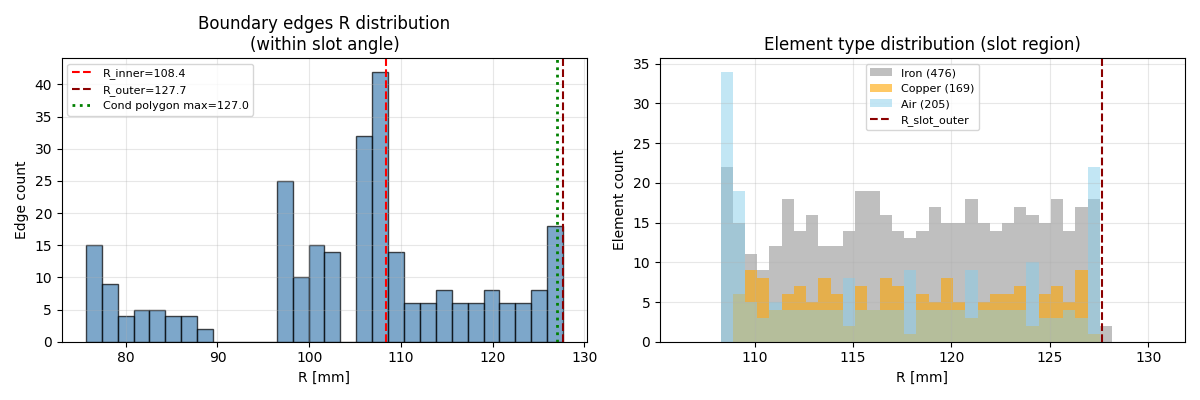

In [20]:
# ─── [5d] 슬롯 최외경 boundary edge 누락 원인 분석 ───
# Q: slot 최외경(yoke측) iron-air 경계 edge가 누락된 것인가?

# 1) boundary_cache 전체에서 slot radial range 분석
bc = boundary_cache
all_bc_r = np.linalg.norm(bc.edge_midpoints, axis=1) * 1e3  # mm
all_bc_a = np.arctan2(bc.edge_midpoints[:, 1], bc.edge_midpoints[:, 0])
a_diff_bc = np.abs(all_bc_a - slot_angle_center)
a_diff_bc = np.minimum(a_diff_bc, 2*np.pi - a_diff_bc)

# 슬롯 각도 내 boundary edges만 선택
in_slot_angle = a_diff_bc < (slot_angle_span / 2)
slot_bc_r = all_bc_r[in_slot_angle]

print(f"═══ [5d] Boundary Edge Radial Coverage ═══")
print(f"  전체 boundary edges: {len(bc.edge_midpoints)}")
print(f"  슬롯 각도 내: {in_slot_angle.sum()}")
print(f"  슬롯 각도 내 R range: [{slot_bc_r.min():.1f}, {slot_bc_r.max():.1f}] mm")
print(f"  기대 슬롯 범위: [{R_slot_inner_mm:.1f}, {R_slot_outer_mm:.1f}] mm")
print(f"  → 최외경 차이: {R_slot_outer_mm - slot_bc_r.max():.2f} mm")

# 2) Element centroid 기반 분석 (슬롯 부근)
# 이전 셀이 실행되지 않았으면 여기서 직접 계산
if 'ecx_m' not in globals() or 'ecy_m' not in globals():
    ec = node_xy_arr[triangles_arr].mean(axis=1)
    ecx_m = ec[:, 0]
    ecy_m = ec[:, 1]

elem_r_mm = np.sqrt(ecx_m**2 + ecy_m**2) * 1e3
elem_a = np.arctan2(ecy_m, ecx_m)
elem_a_diff = np.abs(elem_a - slot_angle_center)
elem_a_diff = np.minimum(elem_a_diff, 2*np.pi - elem_a_diff)
in_slot_elem = (elem_a_diff < slot_angle_span / 2)

iron_in_slot = iron_mask_arr & in_slot_elem
copper_in_slot = is_copper_all & in_slot_elem
air_in_slot = ~iron_mask_arr & ~is_copper_all & in_slot_elem

print(f"\n─── Element 분류 (슬롯 각도 내, R=[{R_slot_inner_mm:.0f},{R_slot_outer_mm:.0f}]mm) ───")
slot_r_mask = (elem_r_mm >= R_slot_inner_mm) & (elem_r_mm <= R_slot_outer_mm)

n_iron_slot = (iron_in_slot & slot_r_mask).sum()
n_copper_slot = (copper_in_slot & slot_r_mask).sum()
n_air_slot = (air_in_slot & slot_r_mask).sum()
print(f"  Iron: {n_iron_slot}")
print(f"  Copper: {n_copper_slot}")
print(f"  Air/insulation: {n_air_slot}")

# 3) 최외경 부근 element 유형 확인
outer_band = (elem_r_mm > R_slot_outer_mm - 3) & (elem_r_mm <= R_slot_outer_mm + 1)
outer_slot = outer_band & in_slot_elem
print(f"\n─── 최외경 부근 (R > {R_slot_outer_mm-3:.0f}mm) ───")
print(f"  Iron: {(iron_mask_arr & outer_slot).sum()}")
print(f"  Copper: {(is_copper_all & outer_slot).sum()}")
print(f"  Air/insulation: {(~iron_mask_arr & ~is_copper_all & outer_slot).sum()}")

# 4) 도체 기하학: DXF 폴리곤 vertex 기준 (정확한 방식)
slot_cond_verts = np.vstack([cp["vertices"] for cp in slot_polys])  # mm
slot_cond_r_mm = np.linalg.norm(slot_cond_verts, axis=1)
poly_r_max_mm = slot_cond_r_mm.max()

# 슬롯 로컬 +h/2 방식 (slot-local 변환)
c_g = np.cos(slot_angle_rad)
s_g = np.sin(slot_angle_rad)
top_local = cond_local_rotated.copy()
top_local[:, 1] = top_local[:, 1] + h_m / 2
top_global = np.column_stack([
    top_local[:, 0] * c_g - top_local[:, 1] * s_g,
    top_local[:, 0] * s_g + top_local[:, 1] * c_g,
]) + slot_center_global
top_r_mm = np.linalg.norm(top_global, axis=1) * 1e3

print(f"\n─── [5d-4] 도체 기하학 비교 ───")
print(f"  R_slot_outer (Motor-CAD): {R_slot_outer_mm:.2f} mm")
print(f"  ① Conductor DXF polygon vertex max: {poly_r_max_mm:.2f} mm")
print(f"     → gap = {poly_r_max_mm - R_slot_outer_mm:+.2f} mm")
print(f"  ② Conductor top-center (+h/2 in slot-local): {top_r_mm.max():.2f} mm")
print(f"     → gap = {top_r_mm.max() - R_slot_outer_mm:+.2f} mm")
print(f"  [참고] 근사식(centroid+h/2 스칼라): {cond_r.max()*1e3 + h_m*1e3/2:.2f} mm (과대추정 가능)")

# 5) slot-local 좌표에서 boundary edge 분석
slot_bc_mask = in_slot_angle & (all_bc_r >= R_slot_inner_mm) & (all_bc_r <= R_slot_outer_mm)
slot_bc_pos = bc.edge_midpoints[slot_bc_mask]
slot_bc_local = to_slot_local(slot_bc_pos, slot_center_global, slot_angle_rad)
slot_bc_rad = slot_bc_local[:, 1] * 1e3  # mm
slot_bc_tang = slot_bc_local[:, 0] * 1e3

print(f"\n─── Slot-local 좌표 내 boundary edges ───")
print(f"  슬롯 내 edges: {slot_bc_mask.sum()}")
print(f"  ξ_rad range: [{slot_bc_rad.min():.2f}, {slot_bc_rad.max():.2f}] mm")
print(f"  ξ_tang range: [{slot_bc_tang.min():.2f}, {slot_bc_tang.max():.2f}] mm")

# filter_slot_wall 결과와 비교
print(f"\n  filter_slot_wall 통과: {mask_diag.sum()} edges")
print(f"  slot_bc_mask (직접 R+angle): {slot_bc_mask.sum()} edges")
print(f"  → 차이: {slot_bc_mask.sum() - mask_diag.sum()} edges")

# 만약 filter_slot_wall이 더 적다면 원인 추적
if slot_bc_mask.sum() != mask_diag.sum():
    mag_r = np.linalg.norm(mag_step_diag.positions, axis=1)
    mag_a = np.arctan2(mag_step_diag.positions[:, 1], mag_step_diag.positions[:, 0])
    r_ok = (mag_r >= slot_r_min_m) & (mag_r <= slot_r_max_m)
    a_diff_check = np.abs(mag_a - slot_angle_center)
    a_diff_check = np.minimum(a_diff_check, 2*np.pi - a_diff_check)
    a_ok = a_diff_check < (slot_angle_span / 2)

    r_fail = ~r_ok & a_ok
    a_fail = r_ok & ~a_ok
    print(f"  R range 탈락: {r_fail.sum()} (R outside [{slot_r_min_m*1e3:.1f},{slot_r_max_m*1e3:.1f}]mm)")
    print(f"  Angle 탈락: {a_fail.sum()} (angle outside ±{np.degrees(slot_angle_span/2):.2f}°)")

    if r_fail.sum() > 0:
        fail_r = np.linalg.norm(mag_step_diag.positions[r_fail], axis=1) * 1e3
        print(f"    R fail range: [{fail_r.min():.2f}, {fail_r.max():.2f}] mm")

# 6) 히스토그램: boundary edge R 분포 (슬롯 내)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(slot_bc_r, bins=30, edgecolor='k', alpha=0.7, color='steelblue')
ax.axvline(R_slot_inner_mm, color='red', linestyle='--', label=f'R_inner={R_slot_inner_mm:.1f}')
ax.axvline(R_slot_outer_mm, color='darkred', linestyle='--', label=f'R_outer={R_slot_outer_mm:.1f}')
ax.axvline(poly_r_max_mm, color='green', linestyle=':', linewidth=2, label=f'Cond polygon max={poly_r_max_mm:.1f}')
ax.set_xlabel('R [mm]')
ax.set_ylabel('Edge count')
ax.set_title('Boundary edges R distribution\n(within slot angle)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Element type 분포
ax = axes[1]
bins = np.linspace(R_slot_inner_mm-2, R_slot_outer_mm+3, 40)
iron_r = elem_r_mm[iron_in_slot & slot_r_mask]
copper_r = elem_r_mm[copper_in_slot & slot_r_mask]
air_r = elem_r_mm[air_in_slot & slot_r_mask]
ax.hist(iron_r, bins=bins, alpha=0.5, label=f'Iron ({len(iron_r)})', color='gray')
ax.hist(copper_r, bins=bins, alpha=0.6, label=f'Copper ({len(copper_r)})', color='orange')
ax.hist(air_r, bins=bins, alpha=0.5, label=f'Air ({len(air_r)})', color='skyblue')
ax.axvline(R_slot_outer_mm, color='darkred', linestyle='--', label='R_slot_outer')
ax.set_xlabel('R [mm]')
ax.set_ylabel('Element count')
ax.set_title('Element type distribution (slot region)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

═══ [5d-2] Stator DXF Overlay ═══
  Stator DXF: D:\KangDH\Thesis\e10\SLFEA_Half\e10Turn6V261SLFEA_Half_RadialStator.dxf
  Lines: 1296, Arcs: 192
  R_slot_outer: 127.65 mm
  Conductor polygon max R: 126.98 mm
  Conductor top-center max R: 126.96 mm


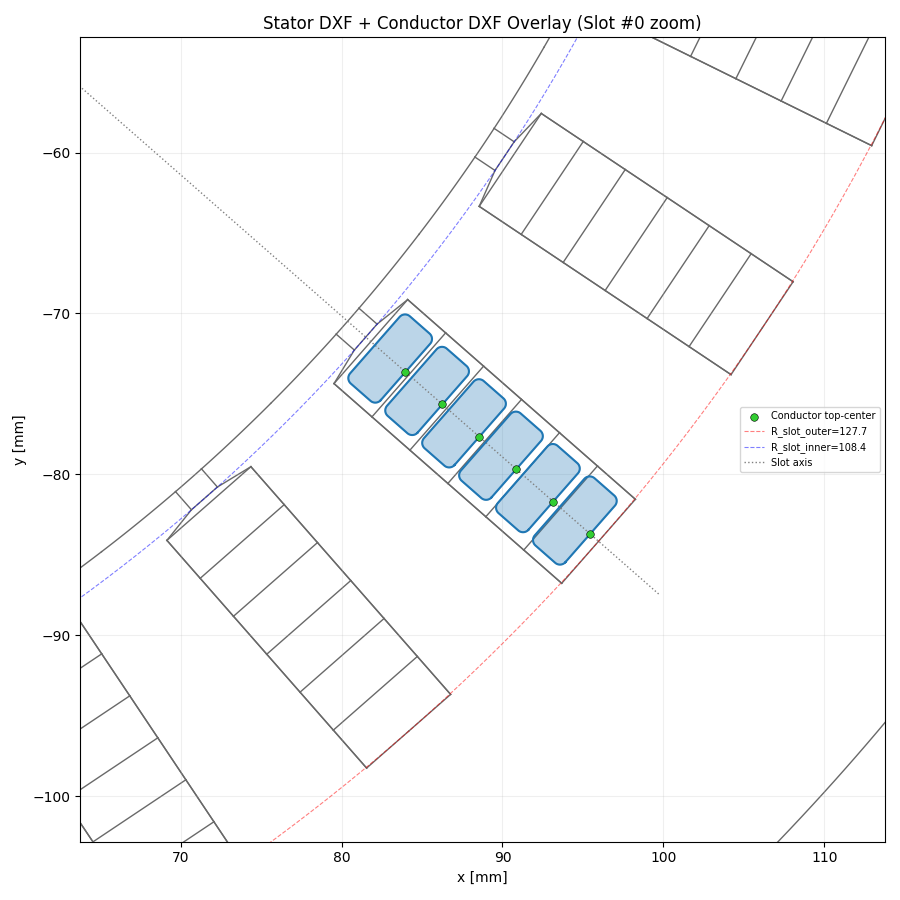

In [21]:
# ─── [5d-2] DXF 오버레이: Stator DXF + Conductor DXF ───
# 목적: Motor-CAD에서 내보낸 실제 stator 도면 위에 도체 오버레이
import ezdxf

# ─── (1) Stator DXF 로드 ───
stator_dxf_path = r"D:\KangDH\Thesis\e10\SLFEA_Half\e10Turn6V261SLFEA_Half_RadialStator.dxf"
stator_doc = ezdxf.readfile(stator_dxf_path)
stator_msp = stator_doc.modelspace()

# LINE, ARC 수집
stator_lines = []
stator_arcs = []
for e in stator_msp:
    if e.dxftype() == 'LINE':
        stator_lines.append(([e.dxf.start.x, e.dxf.start.y],
                             [e.dxf.end.x, e.dxf.end.y]))
    elif e.dxftype() == 'ARC':
        stator_arcs.append({
            'center': (e.dxf.center.x, e.dxf.center.y),
            'radius': e.dxf.radius,
            'start_angle': np.radians(e.dxf.start_angle),
            'end_angle': np.radians(e.dxf.end_angle),
        })

print(f"═══ [5d-2] Stator DXF Overlay ═══")
print(f"  Stator DXF: {stator_dxf_path}")
print(f"  Lines: {len(stator_lines)}, Arcs: {len(stator_arcs)}")

# ─── (2) 도체 top-center 계산 ───
# cond_local_rotated: col0=tang, col1=rad
# top-center = radial 방향으로 h_m/2 위로
c_g = np.cos(slot_angle_rad)
s_g = np.sin(slot_angle_rad)

top_local = cond_local_rotated.copy()
top_local[:, 1] = top_local[:, 1] + h_m / 2  # ξ_rad + h_m/2

# Inverse rotation: col1=x_rot(rad), col0=y_rot(tang), rotate by +θ
top_global = np.column_stack([
    top_local[:, 1] * c_g - top_local[:, 0] * s_g,
    top_local[:, 1] * s_g + top_local[:, 0] * c_g,
]) + slot_center_global
top_r_mm = np.linalg.norm(top_global, axis=1) * 1e3

slot_cond_verts = np.vstack([cp["vertices"] for cp in slot_polys])
poly_r_max_mm = np.linalg.norm(slot_cond_verts, axis=1).max()

print(f"  R_slot_outer: {R_slot_outer_mm:.2f} mm")
print(f"  Conductor polygon max R: {poly_r_max_mm:.2f} mm")
print(f"  Conductor top-center max R: {top_r_mm.max():.2f} mm")

# ─── (3) 플롯: Stator DXF + Conductor DXF ───
fig, ax = plt.subplots(figsize=(9, 9))

# Stator DXF lines (슬롯 부근만 필터링)
sc = slot_center_global * 1e3  # mm
view_half = 25.0  # mm

for (p1, p2) in stator_lines:
    # 뷰 범위 내 line만 그리기
    if (min(p1[0], p2[0]) < sc[0]+view_half and max(p1[0], p2[0]) > sc[0]-view_half and
        min(p1[1], p2[1]) < sc[1]+view_half and max(p1[1], p2[1]) > sc[1]-view_half):
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                color="dimgray", linewidth=1.0, zorder=1)

# Stator DXF arcs (슬롯 부근만 필터링)
for arc in stator_arcs:
    cx, cy = arc['center']
    r = arc['radius']
    # arc bounding box가 view 내에 있는지 확인
    if (cx - r < sc[0]+view_half and cx + r > sc[0]-view_half and
        cy - r < sc[1]+view_half and cy + r > sc[1]-view_half):
        sa = arc['start_angle']
        ea = arc['end_angle']
        if ea < sa:
            ea += 2*np.pi
        th_arc = np.linspace(sa, ea, max(20, int((ea-sa)*50)))
        ax.plot(cx + r*np.cos(th_arc), cy + r*np.sin(th_arc),
                color="dimgray", linewidth=1.0, zorder=1)

# DXF conductor polygons (현재 슬롯)
for cp in slot_polys:
    v = cp["vertices"]  # mm
    vv = np.vstack([v, v[:1]])
    ax.fill(v[:, 0], v[:, 1], color="tab:blue", alpha=0.3, zorder=2)
    ax.plot(vv[:, 0], vv[:, 1], color="tab:blue", linewidth=1.5, zorder=3)

# Conductor top-center 점들
ax.scatter(top_global[:, 0]*1e3, top_global[:, 1]*1e3,
           s=30, color="limegreen", edgecolor="k", linewidth=0.4, zorder=4,
           label="Conductor top-center")

# R 참조선
th = np.linspace(0, 2*np.pi, 600)
ax.plot(R_slot_outer_mm*np.cos(th), R_slot_outer_mm*np.sin(th),
        "r--", linewidth=0.8, alpha=0.5, label=f"R_slot_outer={R_slot_outer_mm:.1f}")
ax.plot(R_slot_inner_mm*np.cos(th), R_slot_inner_mm*np.sin(th),
        "b--", linewidth=0.8, alpha=0.5, label=f"R_slot_inner={R_slot_inner_mm:.1f}")

# 슬롯 중심 방사선
slot_ray_end = np.array([
    (R_slot_outer_mm + 5) * c_g,
    (R_slot_outer_mm + 5) * s_g,
])
ax.plot([0, slot_ray_end[0]], [0, slot_ray_end[1]],
        color="gray", linestyle=":", linewidth=1.0, label="Slot axis")

# 보기 범위
ax.set_xlim(sc[0]-view_half, sc[0]+view_half)
ax.set_ylim(sc[1]-view_half, sc[1]+view_half)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title("Stator DXF + Conductor DXF Overlay (Slot #0 zoom)")
ax.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

### Magnetizing Current 개념 (Morisco 2019, Section II-F)

FEA에서 추출한 **자화(Magnetization) $M$**을 PEEC 모델에서 사용 가능한 **등가 전류원**으로 변환하는 과정입니다.

#### 핵심 아이디어
- 강판(iron) 내 각 mesh element는 **균일한 $M$**을 가짐 (element 내부 $\nabla \times M = 0$)
- Element **내부**에는 등가전류 없음 (eq.35: $g_{mag} = \frac{1}{\mu_0}\nabla \times M = 0$)
- **인접 element 경계(edge)**에서 $M$이 불연속 → 그 차이가 **표면전류**로 표현됨

#### 변환 수식 흐름

| 단계 | 수식 | 의미 |
|------|------|------|
| ① 체적전류 소멸 | eq.35: $g_{mag} = \frac{1}{\mu_0}\nabla \times M$ | 균질 M → 0 |
| ② 표면전류밀도 | eq.37: $k_{mag,\theta} = \frac{1}{\mu_0}(M_\nu - M_\xi) \times n_\theta$ | 인접 element $V_\nu, V_\xi$ 간 M 차이 → edge에 z방향 전류밀도 |
| ③ 적분 (스칼라 전류) | eq.38: $i_{mag,\theta} = (k_{mag,\theta})_z \cdot |s_\theta|$ | edge 길이 곱 → [A] 단위 선전류 |

#### 기하학적 해석 (Fig.3 참조)

```
  Triangle V_ν (M_ν)   │   Triangle V_ξ (M_ξ)
                        │← s_θ (공유 edge, xy 평면)
                        │   n_θ (edge 법선, V_ν→V_ξ 방향)
                        │
           i_mag,θ : z-방향 전류가 이 edge midpoint에 존재
```

- $s_\theta$: 두 삼각형이 공유하는 edge (벡터, xy 평면 내)
- $n_\theta$: $s_\theta$에 수직인 법선 ($s_\theta, n_\theta, e_z$가 오른손 좌표계)
- $(M_\nu - M_\xi) \times n_\theta$: M 불연속에 의한 등가 표면전류 (z성분만 존재)

#### Fig.11과의 관계
- Fig.11의 각 점 = **iron mesh의 공유 edge 하나** (element 중심이 아님!)
- 값 = 해당 edge 양쪽 M 차이로부터 산출된 $|\hat{i}_{mag,\theta}|$ [A]
- 도체에 가까운 slot tooth wall의 edge에서 큰 값 → proximity effect에 기여

#### 구현에서의 대응
`extract_magnetization_currents()` 함수:
1. Iron element별 $M = B/\mu_0 - H$ 계산
2. 인접 삼각형 간 공유 edge 탐색
3. Edge 법선 $n_\theta$ 계산 (eq.37)
4. $k_{mag,\theta} \cdot |s_\theta|$ → scalar current $i_{mag}$ [A] (eq.38)
5. 반환: `positions` = edge midpoint, `currents` = $i_{mag,\theta}$

### # ─── [7b] Magnetization 추출 & 슬롯 벽면 필터 시각화 ───


In [ ]:
# ─── [7b] Magnetization 추출 & 슬롯 벽면 필터 시각화 ───
# Morisco 2019 Fig.4: FEA → M(magnetization) → n_θ → i_mag,θ → PEEC
# Step 0에서 magnetization 추출 → slot-wall filter 적용 시각화


#### 1. Extract magnetization for step 0


In [22]:

# 1. Extract magnetization for step 0
mag_viz = extract_magnetization_currents(
    node_xy=node_xy_arr, triangles=triangles_arr,
    bx=bx_ts_all[0], by=by_ts_all[0],
    hx=hx_ts_all[0], hy=hy_ts_all[0],
    mur=mur_arr, iron_mask=iron_mask_arr, axial_length=L_a,
)
n_mag_total = len(mag_viz.currents)


#### 2. Slot-wall filter

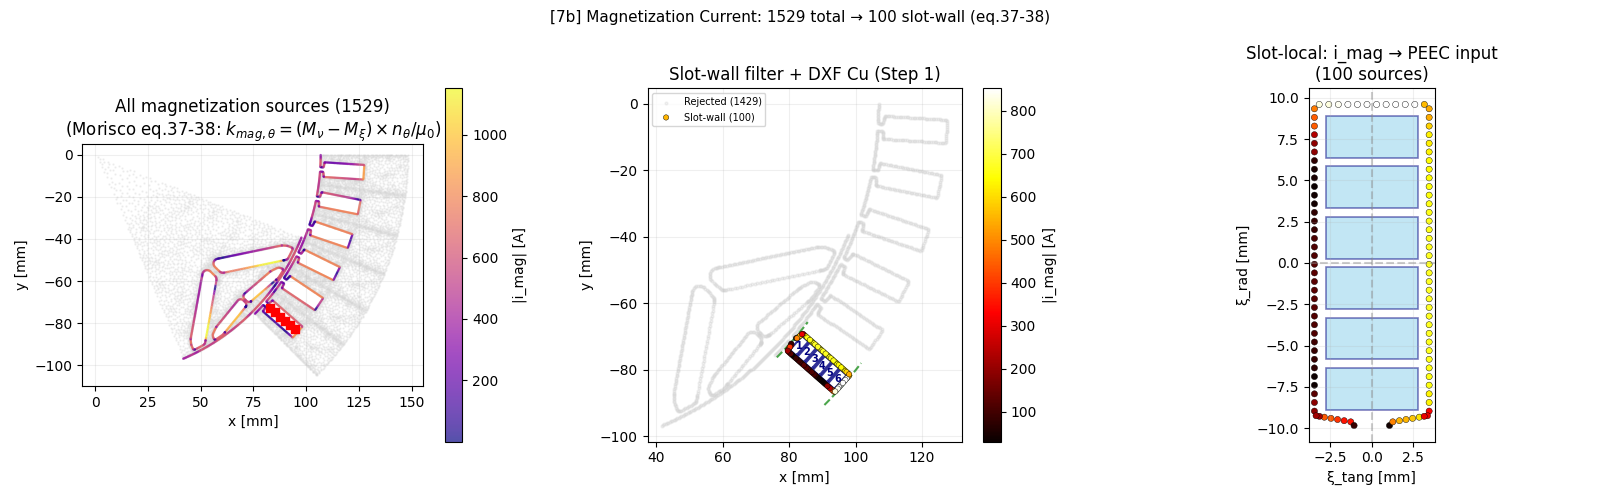


  전체 iron boundary 자화전류: 1529
  슬롯 벽면 필터 후: 100 (6.5%)
  Max |i_mag|: 851.55 A (slot-wall)


In [23]:
# 2. Slot-wall filter
mask_viz = filter_slot_wall(mag_viz, slot_r_min_m, slot_r_max_m,
                            slot_angle_center, slot_angle_span)
n_filtered = mask_viz.sum()
mag_amp = np.abs(mag_viz.currents)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) 전체 magnetization sources (Morisco Fig.4: "Magnetization")
ax = axes[0]
elem_cx = node_xy_arr[triangles_arr].mean(axis=1)[:, 0] * 1e3
elem_cy = node_xy_arr[triangles_arr].mean(axis=1)[:, 1] * 1e3
ax.scatter(elem_cx[iron_mask_arr], elem_cy[iron_mask_arr],
           s=0.5, c='lightgray', alpha=0.3)
mag_x = mag_viz.positions[:, 0] * 1e3
mag_y = mag_viz.positions[:, 1] * 1e3
sc = ax.scatter(mag_x, mag_y, s=3, c=mag_amp, cmap='plasma',
                edgecolors='none', alpha=0.7)
plt.colorbar(sc, ax=ax, label='|i_mag| [A]')
ax.scatter(cond_centers[:, 0]*1e3, cond_centers[:, 1]*1e3,
           s=30, c='red', marker='s', zorder=5)
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title(f'All magnetization sources ({n_mag_total})\n(Morisco eq.37-38: $k_{{mag,\\theta}} = (M_\\nu - M_\\xi) \\times n_\\theta / \\mu_0$)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)

# (2) Slot zoom: filtered vs rejected + DXF polygon overlay
ax = axes[1]
ax.scatter(mag_x[~mask_viz], mag_y[~mask_viz],
           s=4, c='lightgray', alpha=0.3, label=f'Rejected ({n_mag_total - n_filtered})')
sc2 = ax.scatter(mag_x[mask_viz], mag_y[mask_viz],
                 s=15, c=mag_amp[mask_viz], cmap='hot',
                 edgecolors='k', linewidths=0.3, zorder=4, label=f'Slot-wall ({n_filtered})')
plt.colorbar(sc2, ax=ax, label='|i_mag| [A]')
# DXF polygon outlines (selected slot)
for i, cp in enumerate(slot_polys):
    verts = np.vstack([cp["vertices"], cp["vertices"][0]])
    ax.plot(verts[:, 0], verts[:, 1], 'navy', linewidth=1.5, alpha=0.8)
    cx_p, cy_p = cp["vertices"].mean(axis=0)
    ax.text(cx_p, cy_p, str(i+1), ha='center', va='center',
            fontsize=7, color='navy', fontweight='bold', zorder=6)
# Filter boundary (radial band + angular sector)
theta_arc = np.linspace(slot_angle_center - slot_angle_span/2,
                        slot_angle_center + slot_angle_span/2, 50)
for r_b in [slot_r_min_m, slot_r_max_m]:
    ax.plot(r_b*np.cos(theta_arc)*1e3, r_b*np.sin(theta_arc)*1e3,
            'g--', linewidth=1.5, alpha=0.7)
ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
ax.set_title(f'Slot-wall filter + DXF Cu (Step 1)')
ax.set_aspect('equal')
ax.legend(fontsize=7)
ax.autoscale()
ax.grid(True, alpha=0.2)

# (3) Filtered → slot-local 좌표 (PEEC domain으로 입력되는 형태)
ax = axes[2]
pos_local_viz = to_slot_local(mag_viz.positions[mask_viz],
                               slot_center_global, slot_angle_rad)
ax.scatter(pos_local_viz[:, 0]*1e3, pos_local_viz[:, 1]*1e3,
           s=20, c=mag_amp[mask_viz], cmap='hot',
           edgecolors='k', linewidths=0.3)
from matplotlib.patches import Rectangle
for i in range(n_cond):
    cx_l, cy_l = cond_local_rotated[i] * 1e3
    rect = Rectangle((cx_l - b_m/2*1e3, cy_l - h_m/2*1e3),
                     b_m*1e3, h_m*1e3,
                     linewidth=1.2, edgecolor='navy', facecolor='skyblue', alpha=0.5)
    ax.add_patch(rect)
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('ξ_tang [mm]'); ax.set_ylabel('ξ_rad [mm]')
ax.set_title(f'Slot-local: i_mag → PEEC input\n({n_filtered} sources)')
ax.set_aspect('equal')
ax.autoscale()
ax.grid(True, alpha=0.2)

plt.suptitle(f'[7b] Magnetization Current: {n_mag_total} total → {n_filtered} slot-wall (eq.37-38)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n  전체 iron boundary 자화전류: {n_mag_total}")
print(f"  슬롯 벽면 필터 후: {n_filtered} ({100*n_filtered/max(1,n_mag_total):.1f}%)")
print(f"  Max |i_mag|: {mag_amp[mask_viz].max():.2f} A (slot-wall)")

### ─── [7b-2] Magnetization Vector + Magnetizing Current (Fig.10 & Fig.11) ───


In [25]:
# ─── [7b-2] Magnetization Vector + Magnetizing Current (Fig.10 & Fig.11) ───
# 한 슬롯 기준으로 Fig.10 (M vector) + Fig.11 (i_mag) 동시 시각화
# 분류: Outer = iron-air 경계 edge (벽면 법선), Inner = iron-iron 내부 edge
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Rectangle

# ═══════════════════════════════════════════════════════════════
# (A) Iron element M 벡터 계산 (Step 0)
# ═══════════════════════════════════════════════════════════════
bx0 = bx_ts_all[0]; by0 = by_ts_all[0]
hx0 = hx_ts_all[0]; hy0 = hy_ts_all[0]

Mx_all = np.where(iron_mask_arr, bx0 / MU_0 - hx0, 0.0)
My_all = np.where(iron_mask_arr, by0 / MU_0 - hy0, 0.0)
M_mag_all = np.sqrt(Mx_all**2 + My_all**2)


Slot iron elements (yoke+teeth): 1301
  Building edge adjacency (slot iron only)... 1811 edges, 0.02s

─── Fig.11 분류 (Morisco 2019) ───
  Outer (벽면 iron↔air): 100 edges
  Inner (내부 iron↔iron): 741 edges


C:\Users\user\AppData\Local\Temp\ipykernel_40620\2390177071.py:211: UserWarning: Glyph 48317 (\N{HANGUL SYLLABLE BYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\2390177071.py:211: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\2390177071.py:211: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_40620\2390177071.py:211: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


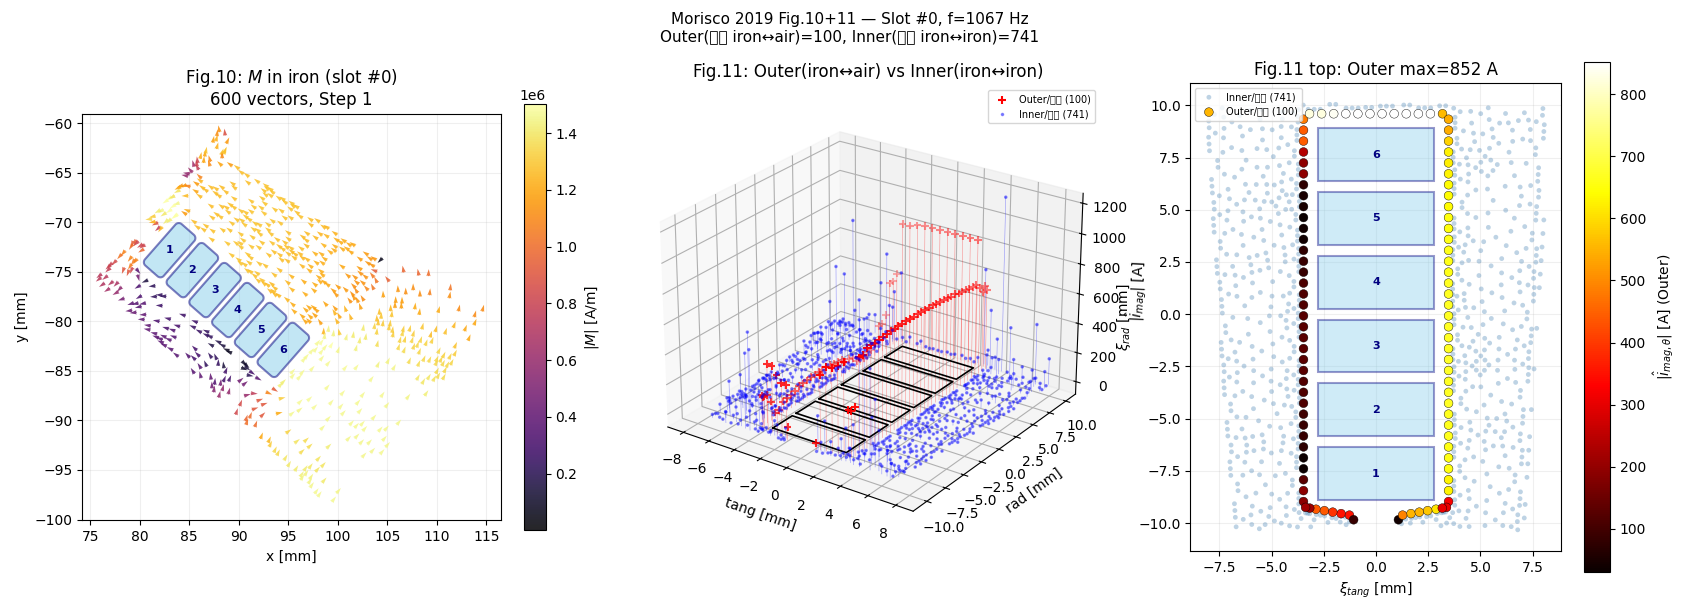


─── Fig.10: Magnetization ───
  Iron: 1301, |M|_max: 1503147 A/m

─── Fig.11: Magnetizing Current (Morisco eq.37-38) ───
            Region |       Type | Count |  Max[A] | Mean[A]
  ─────────────────┼────────────┼───────┼─────────┼────────
        Outer (벽면) |   iron↔air |   100 |   851.6 |   436.8
        Inner (내부) |  iron↔iron |   741 |  1178.7 |    40.3
             TOTAL |            |   841 |  1178.7 |    87.5

  물리적 의미:
  → Outer: M_iron ↔ 0 (air) = full M 불연속 → 큰 |i_mag| (proximity effect 주 기여)
  → Inner: M_ν ↔ M_ξ (iron간) = 작은 ΔM → 작은 |i_mag| (비선형 포화 기울기 차)


In [27]:

# Element centroids [m] for filtering
ecx_m = node_xy_arr[triangles_arr].mean(axis=1)[:, 0]
ecy_m = node_xy_arr[triangles_arr].mean(axis=1)[:, 1]
ecx_mm = ecx_m * 1e3
ecy_mm = ecy_m * 1e3

# 슬롯 주변 iron 필터 (백요크+공극 포함)
ec_r = np.sqrt(ecx_m**2 + ecy_m**2)
ec_angle = np.arctan2(ecy_m, ecx_m)
a_diff_e = np.abs(ec_angle - slot_angle_center)
a_diff_e = np.minimum(a_diff_e, 2*np.pi - a_diff_e)

YOKE_EXTEND_M = 12e-3
AIRGAP_EXTEND_M = 2e-3
slot_iron_mask = (iron_mask_arr &
                  (ec_r >= slot_r_min_m - AIRGAP_EXTEND_M) &
                  (ec_r <= slot_r_max_m + YOKE_EXTEND_M) &
                  (a_diff_e < slot_angle_span * 0.9))
n_slot_iron = slot_iron_mask.sum()
print(f"Slot iron elements (yoke+teeth): {n_slot_iron}")

# ═══════════════════════════════════════════════════════════════
# (B) 내부 iron-iron edge 추출 (논문 Fig.11 "Inner" 성분)
# ═══════════════════════════════════════════════════════════════
print("  Building edge adjacency (slot iron only)...", end=" ")
t0_edge = time.perf_counter()

# 슬롯 iron element만 순회 (최적화)
slot_iron_indices = np.where(slot_iron_mask)[0]
edge_to_tris: dict = {}
for ti in slot_iron_indices:
    tri = triangles_arr[ti]
    for i_e in range(3):
        n0_e = int(tri[i_e])
        n1_e = int(tri[(i_e + 1) % 3])
        edge_key = (min(n0_e, n1_e), max(n0_e, n1_e))
        if edge_key not in edge_to_tris:
            edge_to_tris[edge_key] = []
        edge_to_tris[edge_key].append(ti)

# Internal edges: 양쪽 모두 slot_iron_mask
internal_midpoints = []
internal_currents = []

for (n0_e, n1_e), tris_list in edge_to_tris.items():
    if len(tris_list) != 2:
        continue
    t0_idx, t1_idx = tris_list
    if not (slot_iron_mask[t0_idx] and slot_iron_mask[t1_idx]):
        continue

    p0 = node_xy_arr[n0_e]
    p1 = node_xy_arr[n1_e]
    edge_vec = p1 - p0
    edge_len = np.linalg.norm(edge_vec)
    if edge_len < 1e-15:
        continue

    midpoint = 0.5 * (p0 + p1)
    normal = np.array([-edge_vec[1], edge_vec[0]]) / edge_len

    # ΔM = M_ν - M_ξ (eq.37)
    dMx = Mx_all[t0_idx] - Mx_all[t1_idx]
    dMy = My_all[t0_idx] - My_all[t1_idx]
    # k_mag_z = (ΔM × n̂)_z = dMx·n_y - dMy·n_x
    k_mag_z = dMx * normal[1] - dMy * normal[0]
    i_mag = k_mag_z * edge_len

    internal_midpoints.append(midpoint)
    internal_currents.append(i_mag)

internal_pos = np.array(internal_midpoints) if internal_midpoints else np.zeros((0, 2))
internal_cur = np.abs(np.array(internal_currents)) if internal_currents else np.zeros(0)
t_edge = time.perf_counter() - t0_edge
print(f"{len(internal_cur)} edges, {t_edge:.2f}s")

# ═══════════════════════════════════════════════════════════════
# (C) 슬롯 벽면 필터 적용
# ═══════════════════════════════════════════════════════════════
# Outer (벽면): mag_viz의 slot-wall 필터 (iron-air boundary edges)
pos_filtered = mag_viz.positions[mask_viz]
cur_outer = np.abs(mag_viz.currents[mask_viz])
pos_local_outer = to_slot_local(pos_filtered, slot_center_global, slot_angle_rad)

# Inner (내부): internal iron-iron edges → 슬롯 도체 영역으로 필터
if len(internal_pos) > 0:
    int_r = np.linalg.norm(internal_pos, axis=1)
    int_a = np.arctan2(internal_pos[:, 1], internal_pos[:, 0])
    int_r_mask = (int_r >= slot_r_min_m) & (int_r <= slot_r_max_m)
    int_a_diff = np.abs(int_a - slot_angle_center)
    int_a_diff = np.minimum(int_a_diff, 2*np.pi - int_a_diff)
    int_a_mask = int_a_diff < (slot_angle_span / 2)
    int_slot_mask = int_r_mask & int_a_mask
    cur_inner = internal_cur[int_slot_mask]
    pos_local_inner = to_slot_local(internal_pos[int_slot_mask],
                                     slot_center_global, slot_angle_rad)
else:
    cur_inner = np.zeros(0)
    pos_local_inner = np.zeros((0, 2))

n_outer = len(cur_outer)
n_inner = len(cur_inner)
print(f"\n─── Fig.11 분류 (Morisco 2019) ───")
print(f"  Outer (벽면 iron↔air): {n_outer} edges")
print(f"  Inner (내부 iron↔iron): {n_inner} edges")

# 결합
if n_inner > 0:
    pos_local_all = np.vstack([pos_local_outer, pos_local_inner])
    cur_all = np.concatenate([cur_outer, cur_inner])
else:
    pos_local_all = pos_local_outer
    cur_all = cur_outer
outer_mask = np.zeros(len(cur_all), dtype=bool)
outer_mask[:n_outer] = True
inner_mask = ~outer_mask

# ═══════════════════════════════════════════════════════════════
# (D) 시각화: 3-panel
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(17, 6))

# ─── Panel 1: Fig.10 — M vector quiver ───
ax1 = fig.add_subplot(131)
low_m = slot_iron_mask & (M_mag_all <= 500)
ax1.scatter(ecx_mm[low_m], ecy_mm[low_m], s=1, c='lightgray', alpha=0.3)

high_m_mask = slot_iron_mask & (M_mag_all > 500)
high_m_idx = np.where(high_m_mask)[0]
if len(high_m_idx) > 600:
    rng = np.random.default_rng(42)
    sub_idx = rng.choice(high_m_idx, 600, replace=False)
else:
    sub_idx = high_m_idx

if len(sub_idx) > 0:
    qx = ecx_mm[sub_idx]; qy = ecy_mm[sub_idx]
    qu = Mx_all[sub_idx]; qv = My_all[sub_idx]; qm = M_mag_all[sub_idx]
    q = ax1.quiver(qx, qy, qu/qm, qv/qm, qm,
                   cmap='inferno', clim=[500, qm.max()],
                   angles='xy', scale=60, width=0.004, alpha=0.85, zorder=3)
    plt.colorbar(q, ax=ax1, label='$|M|$ [A/m]', fraction=0.046)

for i, cp in enumerate(slot_polys):
    ax1.fill(cp["vertices"][:, 0], cp["vertices"][:, 1],
             facecolor='skyblue', edgecolor='navy', linewidth=1.5, alpha=0.5, zorder=4)
    cx_p, cy_p = cp["vertices"].mean(axis=0)
    ax1.text(cx_p, cy_p, str(i+1), ha='center', va='center',
             fontsize=8, fontweight='bold', color='navy', zorder=6)

ax1.set_xlabel('x [mm]'); ax1.set_ylabel('y [mm]')
ax1.set_title(f'Fig.10: $M$ in iron (slot #{TARGET_SLOT})\n{len(sub_idx)} vectors, Step 1')
ax1.set_aspect('equal'); ax1.autoscale(); ax1.grid(True, alpha=0.2)

# ─── Panel 2: Fig.11 — 3D stem ───
ax3d = fig.add_subplot(132, projection='3d')
x_mm = pos_local_all[:, 0] * 1e3
y_mm = pos_local_all[:, 1] * 1e3

for i_pt in range(len(x_mm)):
    c = 'red' if outer_mask[i_pt] else 'blue'
    ax3d.plot([x_mm[i_pt], x_mm[i_pt]], [y_mm[i_pt], y_mm[i_pt]],
             [0, cur_all[i_pt]], color=c, linewidth=0.4, alpha=0.4)

ax3d.scatter(x_mm[outer_mask], y_mm[outer_mask], cur_all[outer_mask],
            c='red', marker='+', s=30, label=f'Outer/벽면 ({n_outer})')
ax3d.scatter(x_mm[inner_mask], y_mm[inner_mask], cur_all[inner_mask],
            c='blue', marker='.', s=10, alpha=0.4, label=f'Inner/내부 ({n_inner})')

for ci_l in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci_l] * 1e3
    rx = [cx_l-b_m/2*1e3, cx_l+b_m/2*1e3, cx_l+b_m/2*1e3, cx_l-b_m/2*1e3, cx_l-b_m/2*1e3]
    ry = [cy_l-h_m/2*1e3, cy_l-h_m/2*1e3, cy_l+h_m/2*1e3, cy_l+h_m/2*1e3, cy_l-h_m/2*1e3]
    ax3d.plot(rx, ry, [0]*5, 'k-', linewidth=1.2)

ax3d.set_xlabel('tang [mm]'); ax3d.set_ylabel('rad [mm]')
ax3d.set_zlabel('$|\\hat{i}_{mag}|$ [A]')
ax3d.set_title(f'Fig.11: Outer(iron↔air) vs Inner(iron↔iron)')
ax3d.legend(fontsize=7, loc='upper right')
ax3d.view_init(elev=25, azim=-55)

# ─── Panel 3: Fig.11 top view 2D ───
ax2 = fig.add_subplot(133)
if n_inner > 0:
    ax2.scatter(x_mm[inner_mask], y_mm[inner_mask], c='steelblue',
                s=12, alpha=0.35, edgecolors='none', zorder=3,
                label=f'Inner/내부 ({n_inner})')
sc2 = ax2.scatter(x_mm[outer_mask], y_mm[outer_mask],
                   c=cur_outer, s=40, cmap='hot',
                   edgecolors='k', linewidths=0.3, zorder=4,
                   label=f'Outer/벽면 ({n_outer})')
plt.colorbar(sc2, ax=ax2, label='$|\\hat{i}_{mag,\\theta}|$ [A] (Outer)')

for ci_l in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci_l] * 1e3
    rect = Rectangle((cx_l-b_m/2*1e3, cy_l-h_m/2*1e3), b_m*1e3, h_m*1e3,
                     lw=1.5, edgecolor='navy', facecolor='skyblue', alpha=0.4, zorder=2)
    ax2.add_patch(rect)
    ax2.text(cx_l, cy_l, str(ci_l+1), ha='center', va='center',
             fontsize=8, fontweight='bold', color='navy', zorder=5)

ax2.set_xlabel('$\\xi_{tang}$ [mm]'); ax2.set_ylabel('$\\xi_{rad}$ [mm]')
ax2.set_title(f'Fig.11 top: Outer max={cur_outer.max():.0f} A')
ax2.set_aspect('equal')
ax2.legend(fontsize=7, loc='upper left')
ax2.grid(True, alpha=0.2); ax2.autoscale()

plt.suptitle(f'Morisco 2019 Fig.10+11 — Slot #{TARGET_SLOT}, f={freq:.0f} Hz\n'
             f'Outer(벽면 iron↔air)={n_outer}, Inner(내부 iron↔iron)={n_inner}',
             fontsize=11)
plt.tight_layout()
plt.show()

# ─── 통계 ───
print(f"\n─── Fig.10: Magnetization ───")
print(f"  Iron: {n_slot_iron}, |M|_max: {M_mag_all[slot_iron_mask].max():.0f} A/m")
print(f"\n─── Fig.11: Magnetizing Current (Morisco eq.37-38) ───")
print(f"  {'Region':>16} | {'Type':>10} | {'Count':>5} | {'Max[A]':>7} | {'Mean[A]':>7}")
print(f"  {'─'*16}─┼─{'─'*10}─┼─{'─'*5}─┼─{'─'*7}─┼─{'─'*7}")
if n_outer > 0:
    print(f"  {'Outer (벽면)':>16} | {'iron↔air':>10} | {n_outer:>5} | {cur_outer.max():>7.1f} | {cur_outer.mean():>7.1f}")
if n_inner > 0:
    print(f"  {'Inner (내부)':>16} | {'iron↔iron':>10} | {n_inner:>5} | {cur_inner.max():>7.1f} | {cur_inner.mean():>7.1f}")
print(f"  {'TOTAL':>16} | {'':>10} | {n_outer+n_inner:>5} | {cur_all.max():>7.1f} | {cur_all.mean():>7.1f}")
print(f"\n  물리적 의미:")
print(f"  → Outer: M_iron ↔ 0 (air) = full M 불연속 → 큰 |i_mag| (proximity effect 주 기여)")
print(f"  → Inner: M_ν ↔ M_ξ (iron간) = 작은 ΔM → 작은 |i_mag| (비선형 포화 기울기 차)")

### ─── [7c] 임피던스 행렬 시각화 (Morisco 2019 Fig.4 스타일) ───


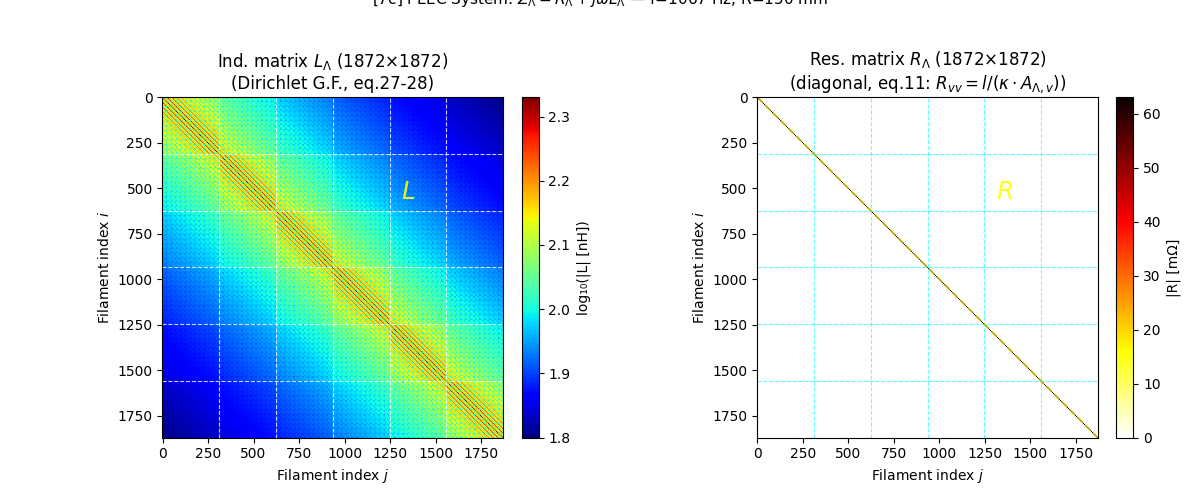


─── PEEC Matrix (eq.2): Z_Λ = R_Λ + jωL_Λ ───
  Size: 1872×1872 = 6 conductors × 312 filaments/cond
  L_Λ: fully populated (mutual inductance via Dirichlet G.F.)
    Self L_vv range: [213.85, 213.97] nH
    Mutual L_vw max: 197.03 nH
  R_Λ: diagonal (ohmic resistance per filament)
    R_vv = l/(κ·A_Λ) = 57.3226 mΩ
    Off-diag max: 0.00e+00 mΩ (≈0, numerical)
  Condition number κ(Z): 2.2e+01


In [28]:
# ─── [7c] 임피던스 행렬 시각화 (Morisco 2019 Fig.4 스타일) ───
# Z_Λ = R_Λ + jωL_Λ  (eq.2)
# R_Λ: diagonal matrix (eq.11) — 각 filament 저항 R_vv = l/(κ·A_Λ,v)
# L_Λ: fully populated (eq.27-28,32) — Dirichlet Green's function 기반

omega = 2 * np.pi * freq
L_matrix = np.imag(Z) / omega   # Inductance matrix [H]
R_matrix = np.real(Z)           # Resistance matrix [Ω]

n_fil = grid_local.n_filaments_per_cond
N = grid_local.n_total

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ─── (1) Inductance matrix L_Λ (log scale, 논문처럼 full 구조 표시) ───
ax = axes[0]
L_abs = np.abs(L_matrix) * 1e9  # [nH]
# log scale로 self/mutual 차이를 잘 보여줌
L_log = np.log10(L_abs + 1e-15)
im1 = ax.imshow(L_log, aspect='equal', cmap='jet',
                interpolation='nearest', origin='upper')
cb1 = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cb1.set_label('log₁₀(|L| [nH])')

# Conductor block boundaries (흰 점선 — 논문 스타일)
for k in range(1, n_cond):
    ax.axhline(k * n_fil - 0.5, color='white', linewidth=0.8, linestyle='--', alpha=0.8)
    ax.axvline(k * n_fil - 0.5, color='white', linewidth=0.8, linestyle='--', alpha=0.8)

# 대각선 표시 (논문: 노란 점선 "L")
ax.plot([0, N-1], [0, N-1], 'y--', linewidth=1.5, alpha=0.8)
ax.text(N*0.7, N*0.3, '$L$', fontsize=18, color='yellow', fontweight='bold', alpha=0.9)

ax.set_xlabel('Filament index $j$')
ax.set_ylabel('Filament index $i$')
ax.set_title(f'Ind. matrix $L_\\Lambda$ ({N}×{N})\n'
             f'(Dirichlet G.F., eq.27-28)')

# ─── (2) Resistance matrix R_Λ (논문처럼 sparse diagonal 패턴) ───
ax = axes[1]
R_abs = np.abs(R_matrix) * 1e3  # [mΩ]

# 논문 스타일: R은 대각만 있으므로 spy plot + colorbar
# 대각 위주로 보여주되, off-diagonal 잔여값도 구분
R_diag_val = np.diag(R_abs)
R_offdiag = R_abs - np.diag(R_diag_val)

# 배경은 off-diagonal (거의 0), 대각은 밝게
im2 = ax.imshow(R_abs, aspect='equal', cmap='hot_r',
                interpolation='nearest', origin='upper',
                vmin=0, vmax=R_diag_val.max() * 1.1)
cb2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
cb2.set_label('|R| [mΩ]')

# Conductor block boundaries
for k in range(1, n_cond):
    ax.axhline(k * n_fil - 0.5, color='cyan', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axvline(k * n_fil - 0.5, color='cyan', linewidth=0.8, linestyle='--', alpha=0.6)

# 대각선 표시
ax.plot([0, N-1], [0, N-1], 'y--', linewidth=1.5, alpha=0.8)
ax.text(N*0.7, N*0.3, '$R$', fontsize=18, color='yellow', fontweight='bold', alpha=0.9)

ax.set_xlabel('Filament index $j$')
ax.set_ylabel('Filament index $i$')
ax.set_title(f'Res. matrix $R_\\Lambda$ ({N}×{N})\n'
             f'(diagonal, eq.11: $R_{{vv}} = l / (\\kappa \\cdot A_{{\\Lambda,v}})$)')

plt.suptitle(f'[7c] PEEC System: $Z_\\Lambda = R_\\Lambda + j\\omega L_\\Lambda$ — '
             f'f={freq:.0f} Hz, R={R_dirichlet*1e3:.0f} mm',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ─── 통계 (논문 Table 대응) ───
print(f"\n─── PEEC Matrix (eq.2): Z_Λ = R_Λ + jωL_Λ ───")
print(f"  Size: {N}×{N} = {n_cond} conductors × {n_fil} filaments/cond")
print(f"  L_Λ: fully populated (mutual inductance via Dirichlet G.F.)")
print(f"    Self L_vv range: [{np.diag(L_abs).min():.2f}, {np.diag(L_abs).max():.2f}] nH")
print(f"    Mutual L_vw max: {(L_abs - np.diag(np.diag(L_abs))).max():.2f} nH")
print(f"  R_Λ: diagonal (ohmic resistance per filament)")
print(f"    R_vv = l/(κ·A_Λ) = {R_diag_val.mean():.4f} mΩ")
print(f"    Off-diag max: {R_offdiag.max():.2e} mΩ (≈0, numerical)")
print(f"  Condition number κ(Z): {np.linalg.cond(Z):.1e}")

## [8] Full-Period Time-Average $k_{ih}$ 계산

**최종 파이프라인**: 128 타임스텝 × (자화전류 추출 + 슬롯필터 + 좌표변환 + PEEC solve)  
회전자 위치에 따른 비대칭 포화 효과를 시간 평균으로 포착합니다.

$$k_{ih} = \frac{1}{N}\sum_{j=1}^{N} \frac{P_{AC}(t_j)}{P_{DC}}$$

In [29]:
# ─── Full-Period PEEC: Per-step magnetization + time-average k_ih ───
# ★ 가속화:
#   1. BoundaryEdgeCache → 경계 edge 기하학 1회 계산
#   2. Z_inv, ZiC, CZiC 재사용 (Cell [6]에서 precomputed)
#   3. V_mag만 per-step 계산 → 매 스텝 ~ms급

# Reload 모듈 (코드 수정 반영)
importlib.reload(_mag_ext)
from HYB.magnetization import (
    extract_magnetization_currents, precompute_boundary_edges, BoundaryEdgeCache
)
from HYB.solver import _compute_magnetization_voltage

print(f"═══ Morisco 2019 — Full-Period Time-Average k_ih (Accelerated) ═══\n")
print(f"  {n_steps} steps × PEEC solve (slot-wall magnetization per step)")
print(f"  Grid: {grid_local.n_total} filaments, freq={freq:.0f} Hz")
print(f"  R = l = {R_dirichlet*1e3:.0f} mm (Dirichlet)")
print(f"  Precomputed: Z_inv ({Z_inv.shape}), ZiC, CZiC from Cell [6]\n")

# ─── Precompute boundary edges (1회) ───
t0_pre = time.perf_counter()
boundary_cache = precompute_boundary_edges(node_xy_arr, triangles_arr, iron_mask_arr)
t_pre = time.perf_counter() - t0_pre
print(f"  ✓ Boundary cache: {len(boundary_cache.edge_midpoints)} edges, {t_pre:.2f}s")

# DC reference loss
A_cond_area = config.cond_width * config.cond_height
R_dc = grid_local.length / (SIGMA_CU * A_cond_area)
P_dc = 0.5 * R_dc * np.sum(np.abs(I_test)**2)
R_fil = grid_local.length / (SIGMA_CU * grid_local.area_fil)

# ─── Precomputed 기본해: i_imposed = ZiC @ solve(CZiC, I_test) ───
# (자화전류 없을 때 = pure skin effect 해, 매 스텝 동일)
i_imposed = ZiC @ np.linalg.solve(CZiC, I_test)
omega = 2 * np.pi * freq

k_ih_per_step = []
t0 = time.perf_counter()

for si in range(n_steps):
    # 1. Extract magnetization (cache → O(1) boundary, vectorized M lookup)
    mag_step = extract_magnetization_currents(
        node_xy=node_xy_arr, triangles=triangles_arr,
        bx=bx_ts_all[si], by=by_ts_all[si],
        hx=hx_ts_all[si], hy=hy_ts_all[si],
        mur=mur_arr, iron_mask=iron_mask_arr,
        axial_length=L_a, boundary_cache=boundary_cache,
    )
    
    # 2. Filter to slot-wall only
    mask = filter_slot_wall(mag_step, slot_r_min_m, slot_r_max_m,
                            slot_angle_center, slot_angle_span)
    
    if mask.sum() == 0:
        i_step = i_imposed  # reuse precomputed
    else:
        # 3. Transform to slot-local → compute V_mag → solve
        pos_local = to_slot_local(mag_step.positions[mask],
                                   slot_center_global, slot_angle_rad)
        mag_local = MagnetizationCurrent(
            positions=pos_local,
            currents=mag_step.currents[mask],
            edge_normals=mag_step.edge_normals[mask],
        )
        
        # V_mag: mutual inductance coupling from magnetization sources
        V_mag = _compute_magnetization_voltage(
            grid_local, mag_local, omega,
            dirichlet_radius=R_dirichlet,
        )
        
        # i_magnetization = Z_inv @ V_mag - ZiC @ solve(CZiC, C^T @ Z_inv @ V_mag)
        i_mag_raw = Z_inv @ V_mag
        delta_I = C.T @ i_mag_raw
        i_correction = ZiC @ np.linalg.solve(CZiC, -delta_I)
        i_step = i_imposed + i_mag_raw + i_correction
    
    # 4. Calculate k_ih for this step
    P_ac_step = 0.5 * R_fil * np.sum(np.abs(i_step)**2)
    k_ih_per_step.append(P_ac_step / P_dc)

t_total = time.perf_counter() - t0
k_ih_arr = np.array(k_ih_per_step)

print(f"\n  Computation: {t_total:.1f}s ({t_total/n_steps*1e3:.0f} ms/step)")
print(f"  Total (incl. precompute): {t_pre + t_total:.1f}s")
print(f"\n{'═'*60}")
print(f"  ★ Time-averaged k_ih = {k_ih_arr.mean():.4f}")
print(f"  k_ih range: [{k_ih_arr.min():.4f}, {k_ih_arr.max():.4f}]")
print(f"  Std: {k_ih_arr.std():.4f}")
print(f"{'═'*60}")
print(f"\n  Reference (Morisco 2019 paper):")
print(f"    OP1 (267 Hz): k_ih = 1.06")
print(f"    OP2 (1067 Hz): k_ih = 2.31")

═══ Morisco 2019 — Full-Period Time-Average k_ih (Accelerated) ═══

  128 steps × PEEC solve (slot-wall magnetization per step)
  Grid: 1872 filaments, freq=1067 Hz
  R = l = 150 mm (Dirichlet)
  Precomputed: Z_inv ((1872, 1872)), ZiC, CZiC from Cell [6]

  ✓ Boundary cache: 1529 edges, 0.09s

  Computation: 2.0s (15 ms/step)
  Total (incl. precompute): 2.1s

════════════════════════════════════════════════════════════
  ★ Time-averaged k_ih = 115.3475
  k_ih range: [2.0345, 182.2858]
  Std: 68.0774
════════════════════════════════════════════════════════════

  Reference (Morisco 2019 paper):
    OP1 (267 Hz): k_ih = 1.06
    OP2 (1067 Hz): k_ih = 2.31


## [9] 결과 시각화

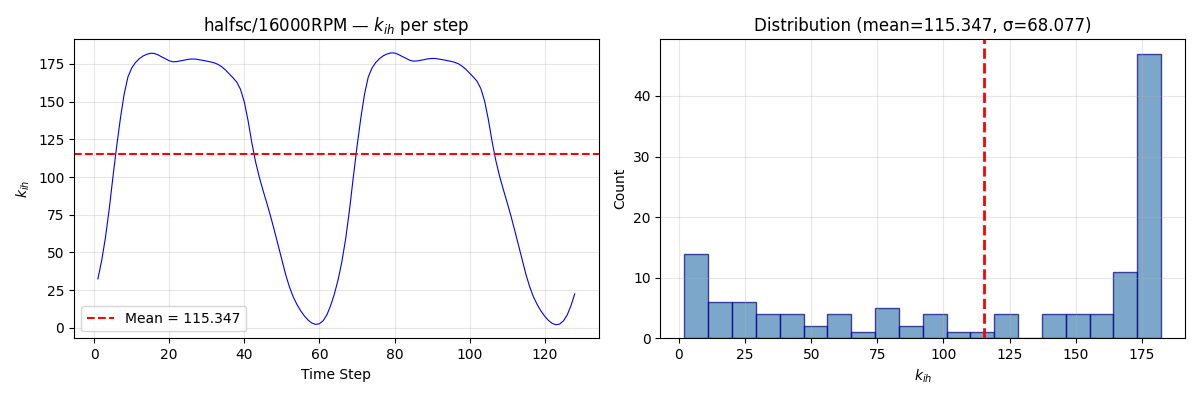

In [31]:
# ─── k_ih 시간 변화 + 히스토그램 ───
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(range(1, n_steps+1), k_ih_arr, 'b-', linewidth=0.8)
ax.axhline(k_ih_arr.mean(), color='r', linestyle='--', label=f'Mean = {k_ih_arr.mean():.3f}')
ax.set_xlabel('Time Step')
ax.set_ylabel('$k_{ih}$')
ax.set_title(f'{TARGET_MODEL}/{TARGET_SPEED}RPM — $k_{{ih}}$ per step')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(k_ih_arr, bins=20, color='steelblue', edgecolor='navy', alpha=0.7)
ax.axvline(k_ih_arr.mean(), color='r', linestyle='--', linewidth=2)
ax.set_xlabel('$k_{ih}$')
ax.set_ylabel('Count')
ax.set_title(f'Distribution (mean={k_ih_arr.mean():.3f}, σ={k_ih_arr.std():.3f})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## [10] 전류 분포 시각화 (Filament Current Density Map)

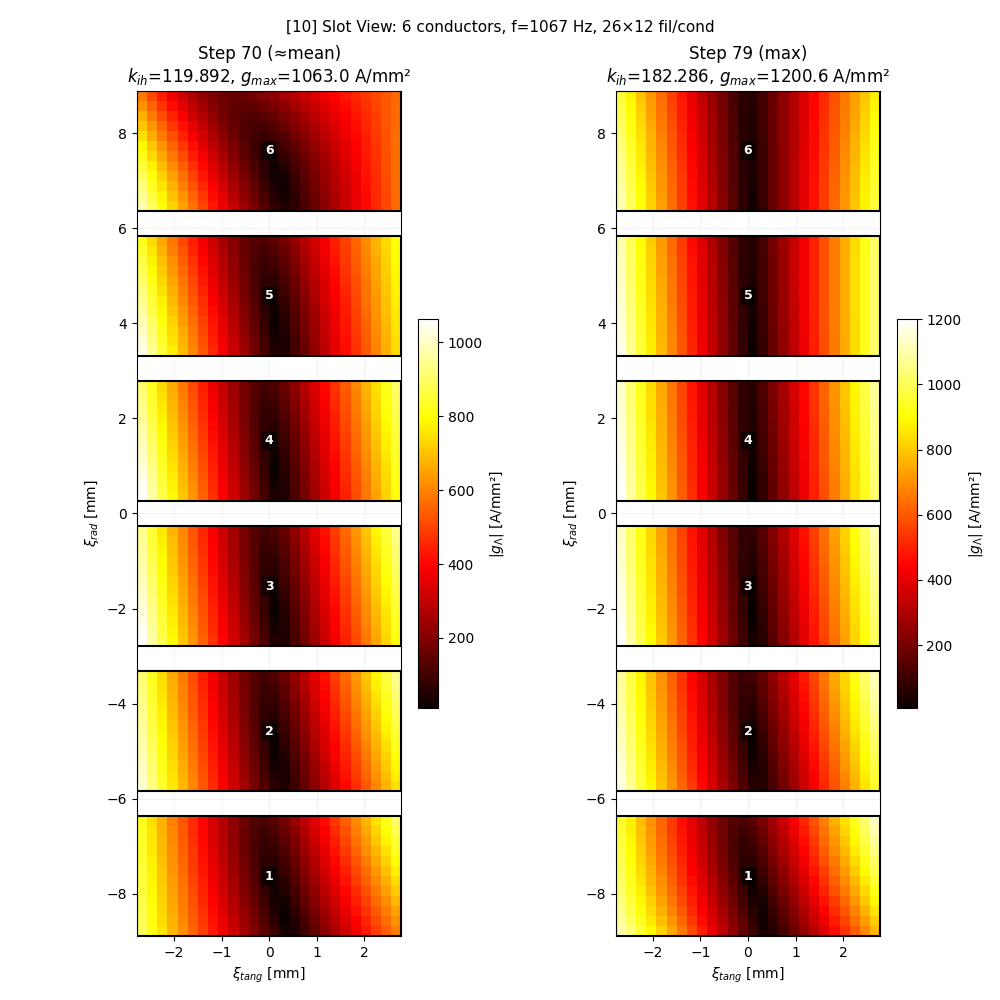

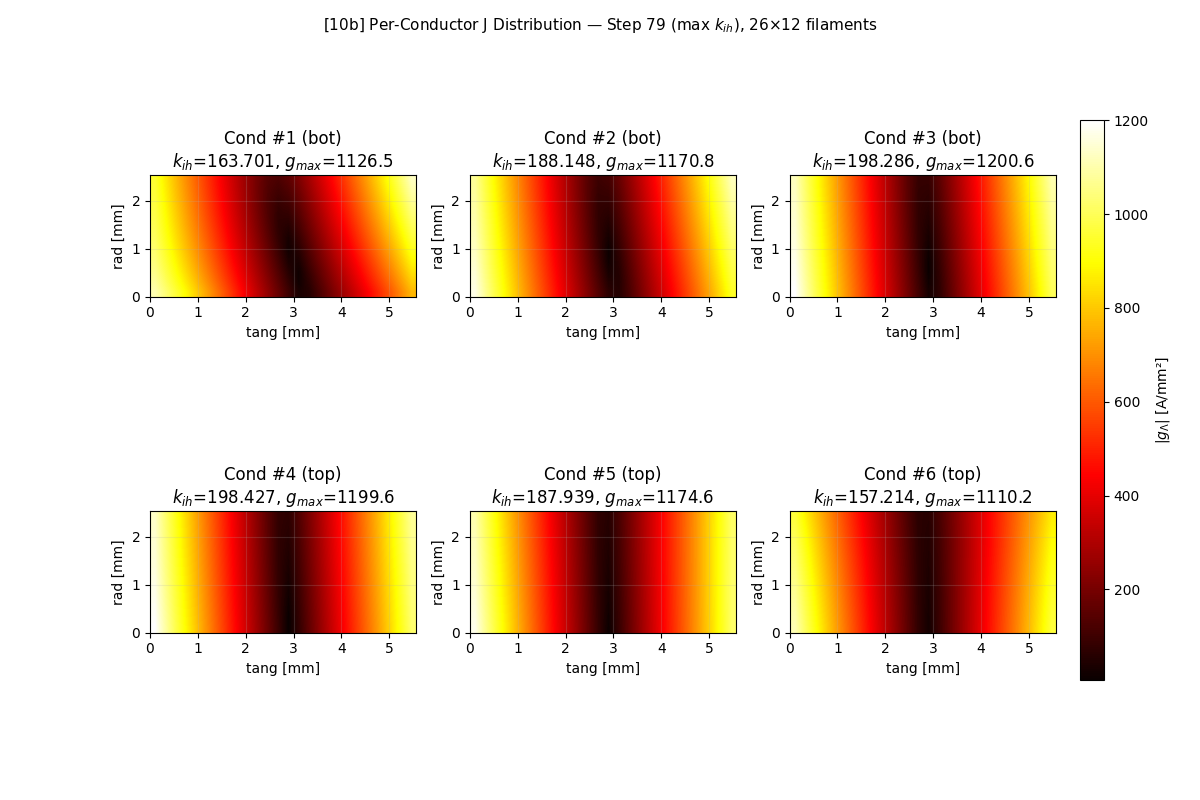


─── Per-conductor k_ih (step=79, max) ───
  Cond |    g_min |    g_max |   P_AC [W] |   k_ih
  ─────┼──────────┼──────────┼────────────┼───────
     1 |     17.7 |   1126.5 |    6364.11 | 163.701
     2 |     12.8 |   1170.8 |    7314.53 | 188.148
     3 |      9.4 |   1200.6 |    7708.65 | 198.286
     4 |      6.8 |   1199.6 |    7714.13 | 198.427
     5 |     13.2 |   1174.6 |    7306.41 | 187.939
     6 |     25.6 |   1110.2 |    6111.94 | 157.214

  Total slot: k_ih = 182.2858
  Bottom cond (1-3): proximity + skin
  Top cond (4-6): mainly skin effect


In [32]:
# ─── 대표 스텝의 전류밀도 분포 (6 도체 개별 표시, Morisco Fig.6a 스타일) ───
step_max = np.argmax(k_ih_arr)
step_mean = np.argmin(np.abs(k_ih_arr - k_ih_arr.mean()))

from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

nx, ny = grid_local.nx, grid_local.ny
n_fil_per = grid_local.n_filaments_per_cond

def solve_step(si):
    """주어진 step에 대해 PEEC solve → filament currents."""
    mag_s = extract_magnetization_currents(
        node_xy=node_xy_arr, triangles=triangles_arr,
        bx=bx_ts_all[si], by=by_ts_all[si],
        hx=hx_ts_all[si], hy=hy_ts_all[si],
        mur=mur_arr, iron_mask=iron_mask_arr, axial_length=L_a)
    m = filter_slot_wall(mag_s, slot_r_min_m, slot_r_max_m,
                         slot_angle_center, slot_angle_span)
    if m.sum() > 0:
        pos_l = to_slot_local(mag_s.positions[m], slot_center_global, slot_angle_rad)
        mag_l = MagnetizationCurrent(pos_l, mag_s.currents[m], mag_s.edge_normals[m])
        res = solve_peec(grid_local, I_test, freq, SIGMA_CU, R_dirichlet, mag_l)
        return res.filament_currents
    else:
        return ZiC @ np.linalg.solve(CZiC, I_test)

# ═══════════════════════════════════════════════════════════════
# (A) 전체 슬롯 뷰: 6개 도체를 실제 배치대로 표시 (pcolormesh)
# ═══════════════════════════════════════════════════════════════
fig_slot, axes_slot = plt.subplots(1, 2, figsize=(10, 10))

for ax, si, label in zip(axes_slot, [step_mean, step_max],
                          [f'Step {step_mean+1} (≈mean)', f'Step {step_max+1} (max)']):
    i_fil = solve_step(si)
    J_density = np.abs(i_fil) / grid_local.area_fil * 1e-6  # A/mm²
    norm = Normalize(vmin=J_density.min(), vmax=J_density.max())
    
    w_mm = config.cond_width * 1e3
    h_mm = config.cond_height * 1e3
    
    for ci in range(n_cond):
        fil_start = ci * n_fil_per
        J_cond = J_density[fil_start:fil_start + n_fil_per]
        J_2d = J_cond.reshape(ny, nx)
        
        cx_mm = cond_local_rotated[ci, 0] * 1e3
        cy_mm = cond_local_rotated[ci, 1] * 1e3
        
        # pcolormesh 좌표 생성
        x_edges = np.linspace(cx_mm - w_mm/2, cx_mm + w_mm/2, nx + 1)
        y_edges = np.linspace(cy_mm - h_mm/2, cy_mm + h_mm/2, ny + 1)
        X, Y = np.meshgrid(x_edges, y_edges)
        
        ax.pcolormesh(X, Y, J_2d, cmap='hot', norm=norm,
                      shading='flat', zorder=2)
        
        # 도체 경계
        rect = Rectangle((cx_mm - w_mm/2, cy_mm - h_mm/2), w_mm, h_mm,
                         linewidth=1.5, edgecolor='black', facecolor='none', zorder=3)
        ax.add_patch(rect)
        ax.text(cx_mm, cy_mm, str(ci+1), ha='center', va='center',
                fontsize=9, fontweight='bold', color='white', zorder=4,
                bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))
    
    sm = plt.cm.ScalarMappable(cmap='hot', norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('$|g_{\\Lambda}|$ [A/mm²]')
    ax.set_aspect('equal')
    ax.set_xlabel('$\\xi_{tang}$ [mm]')
    ax.set_ylabel('$\\xi_{rad}$ [mm]')
    ax.set_title(f'{label}\n$k_{{ih}}$={k_ih_arr[si]:.3f}, '
                 f'$g_{{max}}$={J_density.max():.1f} A/mm²')
    ax.grid(True, alpha=0.15, zorder=0)

fig_slot.suptitle(f'[10] Slot View: {n_cond} conductors, f={freq:.0f} Hz, '
                  f'{nx}×{ny} fil/cond', fontsize=11)
fig_slot.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════
# (B) 개별 도체 확대 뷰 (2×3 grid) — step_max 기준
# ═══════════════════════════════════════════════════════════════
i_fil_max = solve_step(step_max)
J_all = np.abs(i_fil_max) / grid_local.area_fil * 1e-6
J_global_min = J_all.min()
J_global_max = J_all.max()
norm_global = Normalize(vmin=J_global_min, vmax=J_global_max)

n_rows = 2 if n_cond > 3 else 1
n_cols = (n_cond + n_rows - 1) // n_rows
fig_ind, axes_ind = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes_flat = np.atleast_1d(axes_ind).flatten()

for ci in range(n_cond):
    ax = axes_flat[ci]
    fil_start = ci * n_fil_per
    J_cond = J_all[fil_start:fil_start + n_fil_per]
    J_2d = J_cond.reshape(ny, nx)
    
    w_mm = config.cond_width * 1e3
    h_mm = config.cond_height * 1e3
    extent = [0, w_mm, 0, h_mm]
    
    im = ax.imshow(J_2d, extent=extent, origin='lower',
                   aspect='equal', cmap='hot', norm=norm_global,
                   interpolation='bilinear')
    
    ax.set_xlabel('tang [mm]')
    ax.set_ylabel('rad [mm]')
    
    # Per-conductor k_ih
    R_fil_val = grid_local.length / (SIGMA_CU * grid_local.area_fil)
    A_single = config.cond_width * config.cond_height
    R_dc_single = grid_local.length / (SIGMA_CU * A_single)
    P_dc_ci = 0.5 * R_dc_single * np.abs(I_test[ci])**2
    P_ac_ci = 0.5 * R_fil_val * np.sum(np.abs(i_fil_max[fil_start:fil_start+n_fil_per])**2)
    k_ci = P_ac_ci / P_dc_ci
    
    ax.set_title(f'Cond #{ci+1} ({"top" if ci >= n_cond//2 else "bot"})\n'
                 f'$k_{{ih}}$={k_ci:.3f}, '
                 f'$g_{{max}}$={J_cond.max():.1f}')
    ax.grid(True, alpha=0.2)

# 빈 subplot 숨기기
for ci in range(n_cond, len(axes_flat)):
    axes_flat[ci].set_visible(False)

# 공통 colorbar
fig_ind.subplots_adjust(right=0.88)
cbar_ax = fig_ind.add_axes([0.90, 0.15, 0.02, 0.7])
cb = fig_ind.colorbar(plt.cm.ScalarMappable(cmap='hot', norm=norm_global),
                      cax=cbar_ax)
cb.set_label('$|g_{\\Lambda}|$ [A/mm²]')

fig_ind.suptitle(f'[10b] Per-Conductor J Distribution — Step {step_max+1} (max $k_{{ih}}$), '
                 f'{nx}×{ny} filaments',
                 fontsize=11)
plt.show()

# ═══════════════════════════════════════════════════════════════
# (C) Per-conductor loss table
# ═══════════════════════════════════════════════════════════════
print(f"\n─── Per-conductor k_ih (step={step_max+1}, max) ───")
print(f"  {'Cond':>4} | {'g_min':>8} | {'g_max':>8} | {'P_AC [W]':>10} | {'k_ih':>6}")
print(f"  {'─'*4}─┼─{'─'*8}─┼─{'─'*8}─┼─{'─'*10}─┼─{'─'*6}")
R_fil_val = grid_local.length / (SIGMA_CU * grid_local.area_fil)
A_single = config.cond_width * config.cond_height
R_dc_single = grid_local.length / (SIGMA_CU * A_single)
P_dc_single = 0.5 * R_dc_single * np.abs(I_test[0])**2

for ci in range(n_cond):
    fil_s = ci * n_fil_per
    fil_e = fil_s + n_fil_per
    J_ci = J_all[fil_s:fil_e]
    P_ac_ci = 0.5 * R_fil_val * np.sum(np.abs(i_fil_max[fil_s:fil_e])**2)
    k_ci = P_ac_ci / P_dc_single
    print(f"  {ci+1:>4} | {J_ci.min():>8.1f} | {J_ci.max():>8.1f} | {P_ac_ci:>10.2f} | {k_ci:>6.3f}")

print(f"\n  Total slot: k_ih = {k_ih_arr[step_max]:.4f}")
print(f"  Bottom cond (1-{n_cond//2}): proximity + skin")
print(f"  Top cond ({n_cond//2+1}-{n_cond}): mainly skin effect")

### ─── [10c] FEA (J+Je) vs PEEC 비교 — fullfea transient 데이터 사용 ───


In [33]:
# ─── [10c] FEA (J+Je) vs PEEC 비교 — fullfea transient 데이터 사용 ───
# fullfea 파일에서 J(imposed) + Je(eddy) = total current density를 추출하여
# PEEC의 total filament current density와 비교합니다.
# hybrid 파일은 Je=0 (winding eddy 미계산), fullfea는 실제 transient eddy 포함.

from matplotlib.patches import Polygon as MplPolygon, Rectangle
from matplotlib.colors import Normalize, TwoSlopeNorm


#### (A) FullFEA TXT 파싱 (halfsc/fullfea/16000RPM)


In [36]:

# ═══════════════════════════════════════════════════════════════
# (A) FullFEA TXT 파싱 (halfsc/fullfea/16000RPM)
# ═══════════════════════════════════════════════════════════════
fullfea_key = None
for k in found_txts:
    if TARGET_MODEL in k and "fullfea" in k and str(TARGET_SPEED) in k:
        fullfea_key = k
        break

if fullfea_key is None:
    raise FileNotFoundError(f"fullfea file not found for {TARGET_MODEL}/{TARGET_SPEED}RPM")

fullfea_path = found_txts[fullfea_key]
print(f"─── FullFEA 파싱: {fullfea_key} ───")
print(f"  File: {fullfea_path.name} ({fullfea_path.stat().st_size/1e6:.0f} MB)")
print(f"  ⏳ 파싱 중 (대용량 파일, ~30-60초 소요)...")

t0_ff = time.perf_counter()
ts_fullfea = get_magnetic_timeseries_from_file(str(fullfea_path))
t_ff = time.perf_counter() - t0_ff
n_steps_ff = len(ts_fullfea.steps)
print(f"  ✓ 파싱 완료: {t_ff:.1f}s, {n_steps_ff} steps")


─── FullFEA 파싱: halfsc/fullfea/fullfea_halfsc_16000RPM ───
  File: fullfea_halfsc_16000RPM.txt (495 MB)
  ⏳ 파싱 중 (대용량 파일, ~30-60초 소요)...
  ✓ 파싱 완료: 22.2s, 128 steps


#### (B) FullFEA mesh → element centroids + J/Je 추출


In [37]:

# ═══════════════════════════════════════════════════════════════
# (B) FullFEA mesh → element centroids + J/Je 추출
# ═══════════════════════════════════════════════════════════════
# fullfea mesh는 hybrid와 다름 (더 많은 element)
mr0_ff = ts_fullfea.by_step[ts_fullfea.steps[0]]

# Node 좌표 (fullfea mesh)
node_ids_ff = sorted(mr0_ff.node_xy.keys())
node_id_to_idx_ff = {nid: i for i, nid in enumerate(node_ids_ff)}
node_xy_ff = np.array([mr0_ff.node_xy[nid] for nid in node_ids_ff]) * 1e-3  # [m]

# Element connectivity
elements_ff = []
for reg in mr0_ff._regions:
    for el in reg.elements:
        n1 = node_id_to_idx_ff.get(el.node_1, -1)
        n2 = node_id_to_idx_ff.get(el.node_2, -1)
        n3 = node_id_to_idx_ff.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            elements_ff.append((n1, n2, n3))
triangles_ff = np.array(elements_ff, dtype=int)
n_elem_ff = len(triangles_ff)

# Element centroids [mm] for DXF polygon matching
elem_centroids_ff_mm = node_xy_ff[triangles_ff].mean(axis=1) * 1e3

# DXF copper mask
is_copper_ff = np.zeros(n_elem_ff, dtype=bool)
for path in all_cond_paths:
    is_copper_ff |= path.contains_points(elem_centroids_ff_mm)

print(f"  FullFEA mesh: {n_elem_ff} elements, {is_copper_ff.sum()} copper")


  FullFEA mesh: 21272 elements, 2304 copper


In [38]:
ts_fullfea.interactive_plot()

#### (C) step_max에 해당하는 J + Je 추출


In [ ]:

# ═══════════════════════════════════════════════════════════════
# (C) step_max에 해당하는 J + Je 추출
# ═══════════════════════════════════════════════════════════════
# (C) 모든 도체에 전류가 있고 Je도 유의미한 step 자동 탐색
# ═══════════════════════════════════════════════════════════════
# 후반부 step에서 모든 도체의 J>0 + Je≠0인 step을 찾음
target_step_idx = None
# 후반부(정상상태 도달 이후)에서 탐색
search_range = list(range(n_steps_ff//2, n_steps_ff))
for try_idx in search_range:
    _mr = ts_fullfea.by_step[ts_fullfea.steps[try_idx]]
    _j = np.zeros(n_elem_ff)
    _je = np.zeros(n_elem_ff)
    _ei = 0
    for reg in _mr._regions:
        for el in reg.elements:
            n1 = node_id_to_idx_ff.get(el.node_1, -1)
            n2 = node_id_to_idx_ff.get(el.node_2, -1)
            n3 = node_id_to_idx_ff.get(el.node_3, -1)
            if n1 >= 0 and n2 >= 0 and n3 >= 0:
                _j[_ei] = getattr(el, 'j', 0) or 0
                _je[_ei] = getattr(el, 'je', 0) or 0
                _ei += 1
    _j_cu_slot = _j[is_copper_ff][slot_cu_mask_ff]
    _je_cu_slot = _je[is_copper_ff][slot_cu_mask_ff]
    # 각 도체별 확인
    all_have_j = True
    for ci_t in range(n_cond):
        pi_t = slot_poly_idx[ci_t]
        in_t = all_cond_paths[pi_t].contains_points(np.column_stack([cx_slot_mm, cy_slot_mm]))
        if in_t.sum() > 0 and _j_cu_slot[in_t].max() == 0:
            all_have_j = False
            break
    if all_have_j and np.abs(_je_cu_slot).max() > 10:  # Je도 유의미해야
        target_step_idx = try_idx
        print(f"  ✓ Step {try_idx+1}: 모든 도체 J>0, |Je|_max={np.abs(_je_cu_slot).max():.1f} A/mm²")
        break

if target_step_idx is None:
    # fallback: step_max 사용
    target_step_idx = int(step_max)
    if target_step_idx >= n_steps_ff:
        target_step_idx = n_steps_ff - 1# (F) 도체별 통계 비교

    print(f"  ⚠ 전 도체 J>0 + Je유의미 step 미발견, Step {target_step_idx+1} 사용")


NameError: name 'slot_cu_mask_ff' is not defined

In [49]:
target_step_idx=80
target_step_key_ff = ts_fullfea.steps[target_step_idx]
mr_ff = ts_fullfea.by_step[target_step_key_ff]

In [50]:



# J와 Je 추출 (전체 element)
j_fea_all = np.zeros(n_elem_ff)
je_fea_all = np.zeros(n_elem_ff)
ei_ff = 0
for reg in mr_ff._regions:
    for el in reg.elements:
        n1 = node_id_to_idx_ff.get(el.node_1, -1)
        n2 = node_id_to_idx_ff.get(el.node_2, -1)
        n3 = node_id_to_idx_ff.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            j_fea_all[ei_ff] = getattr(el, 'j', 0) or 0
            je_fea_all[ei_ff] = getattr(el, 'je', 0) or 0
            ei_ff += 1

# Total current density = J + Je [A/mm²]
jtot_fea_all = j_fea_all + je_fea_all

# # Copper elements 필터
# jtot_copper = jtot_fea_all[is_copper_ff]
# j_copper = j_fea_all[is_copper_ff]
# je_copper = je_fea_all[is_copper_ff]
# slot_cu_mask_ff
# jtot_slot = jtot_copper[slot_cu_mask_ff]
# j_slot = j_copper[slot_cu_mask_ff]
# je_slot = je_copper[slot_cu_mask_ff]

# print(f"\n─── FullFEA J+Je 추출 (Step {target_step_idx+1}) ───")
# print(f"  전체 Cu elements: {is_copper_ff.sum()}")
# print(f"  슬롯 #{TARGET_SLOT} Cu elements: {slot_cu_mask_ff.sum()}")
# print(f"  J (imposed) range: [{j_slot.min():.1f}, {j_slot.max():.1f}] A/mm²")
# print(f"  Je (eddy) range: [{je_slot.min():.1f}, {je_slot.max():.1f}] A/mm²")
# print(f"  J+Je (total) range: [{jtot_slot.min():.1f}, {jtot_slot.max():.1f}] A/mm²")
# print(f"  |J+Je| max: {np.abs(jtot_slot).max():.1f} A/mm²")
# print(f"  |Je| max: {np.abs(je_slot).max():.1f} A/mm²")

#### (D) PEEC je 계산 (같은 스텝 — hybrid mesh 기준)
 

In [51]:

# ═══════════════════════════════════════════════════════════════
# (D) PEEC je 계산 (같은 스텝 — hybrid mesh 기준)
# ═══════════════════════════════════════════════════════════════
mag_step_cmp = extract_magnetization_currents(
    node_xy=node_xy_arr, triangles=triangles_arr,
    bx=bx_ts_all[target_step_idx], by=by_ts_all[target_step_idx],
    hx=hx_ts_all[target_step_idx], hy=hy_ts_all[target_step_idx],
    mur=mur_arr, iron_mask=iron_mask_arr,
    axial_length=L_a, boundary_cache=boundary_cache,
)
mask_cmp = filter_slot_wall(mag_step_cmp, slot_r_min_m, slot_r_max_m,
                            slot_angle_center, slot_angle_span)


In [52]:

if mask_cmp.sum() > 0:
    pos_local_cmp = to_slot_local(mag_step_cmp.positions[mask_cmp],
                                   slot_center_global, slot_angle_rad)
    mag_local_cmp = MagnetizationCurrent(
        positions=pos_local_cmp,
        currents=mag_step_cmp.currents[mask_cmp],
        edge_normals=mag_step_cmp.edge_normals[mask_cmp],
    )
    V_mag_cmp = _compute_magnetization_voltage(
        grid_local, mag_local_cmp, omega, dirichlet_radius=R_dirichlet)
    i_mag_raw_cmp = Z_inv @ V_mag_cmp
    delta_I_cmp = C.T @ i_mag_raw_cmp
    i_correction_cmp = ZiC @ np.linalg.solve(CZiC, -delta_I_cmp)
    i_peec = i_imposed + i_mag_raw_cmp + i_correction_cmp
else:
    i_peec = i_imposed

J_peec = np.abs(i_peec) / grid_local.area_fil * 1e-6  # [A/mm²]
print(f"\n  PEEC |J| range: [{J_peec.min():.1f}, {J_peec.max():.1f}] A/mm²")



  PEEC |J| range: [6.1, 1196.4] A/mm²


####  (E) 시각화: FEA |J+Je| contour | PEEC |J| contour | 차이


In [58]:
# ─── (D) FullFEA J+Je 추출: 슬롯 내 copper elements ───
# 시각화(E)에서 사용할 cx_slot_mm, cy_slot_mm, jtot_slot 등 생성

# 슬롯 내 copper element 위치 (전역 좌표, mm)
cu_cx_ff = elem_centroids_ff_mm[is_copper_ff, 0]
cu_cy_ff = elem_centroids_ff_mm[is_copper_ff, 1]
cu_angle_ff = np.arctan2(cu_cy_ff, cu_cx_ff)
cu_a_diff_ff = np.abs(cu_angle_ff - slot_angle_center)
cu_a_diff_ff = np.minimum(cu_a_diff_ff, 2*np.pi - cu_a_diff_ff)
slot_cu_mask_ff = cu_a_diff_ff < slot_angle_span * 0.8

cx_slot_mm = cu_cx_ff[slot_cu_mask_ff]
cy_slot_mm = cu_cy_ff[slot_cu_mask_ff]

# FullFEA J+Je 값 추출 (target_step_idx 기준)
j_fea_all = np.zeros(n_elem_ff)
je_fea_all = np.zeros(n_elem_ff)
ei_ff = 0
for reg in mr_ff._regions:
    for el in reg.elements:
        n1 = node_id_to_idx_ff.get(el.node_1, -1)
        n2 = node_id_to_idx_ff.get(el.node_2, -1)
        n3 = node_id_to_idx_ff.get(el.node_3, -1)
        if n1 >= 0 and n2 >= 0 and n3 >= 0:
            j_fea_all[ei_ff] = getattr(el, 'j', 0) or 0
            je_fea_all[ei_ff] = getattr(el, 'je', 0) or 0
            ei_ff += 1

jtot_fea_all = j_fea_all + je_fea_all
jtot_copper = jtot_fea_all[is_copper_ff]
j_copper    = j_fea_all[is_copper_ff]
je_copper   = je_fea_all[is_copper_ff]

jtot_slot = jtot_copper[slot_cu_mask_ff]
j_slot    = j_copper[slot_cu_mask_ff]
je_slot   = je_copper[slot_cu_mask_ff]

print(f"─── FullFEA J+Je (Step {target_step_idx+1}) ───")
print(f"  슬롯 Cu elements: {slot_cu_mask_ff.sum()}")
print(f"  J range:     [{j_slot.min():.1f}, {j_slot.max():.1f}] A/mm²")
print(f"  Je range:    [{je_slot.min():.1f}, {je_slot.max():.1f}] A/mm²")
print(f"  J+Je range:  [{jtot_slot.min():.1f}, {jtot_slot.max():.1f}] A/mm²")

─── FullFEA J+Je (Step 81) ───
  슬롯 Cu elements: 384
  J range:     [0.0, 70.0] A/mm²
  Je range:    [-147.3, 505.5] A/mm²
  J+Je range:  [-77.3, 535.7] A/mm²


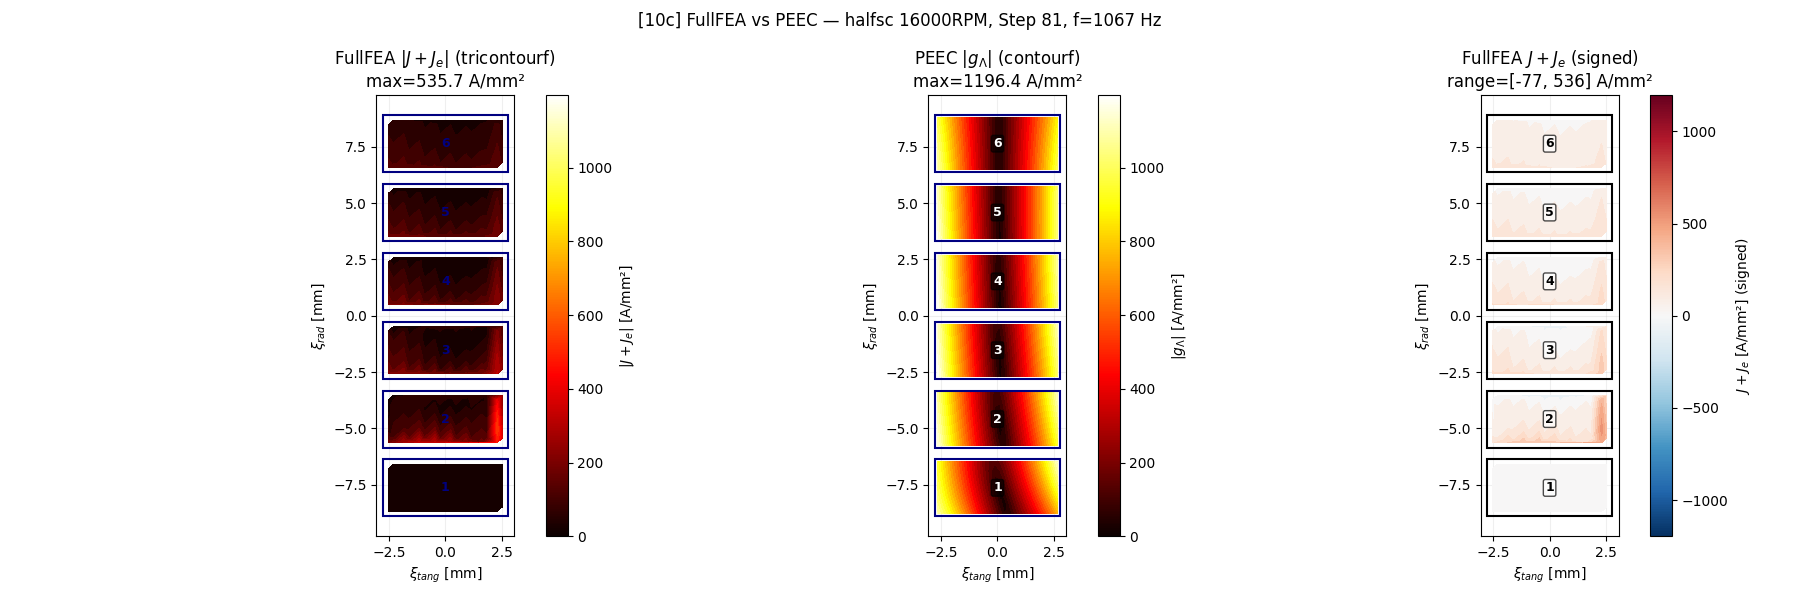

In [59]:

# ═══════════════════════════════════════════════════════════════
# (E) 시각화: FEA |J+Je| contour | PEEC |J| contour | 차이
# ═══════════════════════════════════════════════════════════════
from scipy.interpolate import griddata
from matplotlib.tri import Triangulation

# Slot-local 변환 (FEA 데이터)
cu_pos_global_m = np.column_stack([cx_slot_mm, cy_slot_mm]) * 1e-3
cu_pos_local = to_slot_local(cu_pos_global_m, slot_center_global, slot_angle_rad)
cu_x_local_mm = cu_pos_local[:, 0] * 1e3
cu_y_local_mm = cu_pos_local[:, 1] * 1e3
jtot_abs = np.abs(jtot_slot)

# 공통 colorbar 범위
vmax_fea = np.percentile(jtot_abs, 99)
vmax_common = max(vmax_fea, J_peec.max())
n_levels = 32
levels = np.linspace(0, vmax_common, n_levels)

# PEEC grid: filament center 좌표와 J 값을 도체별로 수집
w_mm_p = config.cond_width * 1e3
h_mm_p = config.cond_height * 1e3

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ─── (1) FEA |J+Je| — tricontourf per conductor ───
ax = axes[0]
for ci_p in range(n_cond):
    # 도체 ci_p에 속하는 FEA elements 추출
    pi_global = slot_poly_idx[ci_p]
    cond_path_s = all_cond_paths[pi_global]
    in_cond = cond_path_s.contains_points(
        np.column_stack([cx_slot_mm, cy_slot_mm]))
    
    if in_cond.sum() < 4:
        continue
    
    xi_tang = cu_x_local_mm[in_cond]
    xi_rad = cu_y_local_mm[in_cond]
    j_vals = jtot_abs[in_cond]
    
    # tricontourf on this conductor's elements
    try:
        tri_c = Triangulation(xi_tang, xi_rad)
        ax.tricontourf(tri_c, j_vals, levels=levels, cmap='hot', extend='max', zorder=2)
    except Exception:
        ax.scatter(xi_tang, xi_rad, s=3, c=j_vals, cmap='hot',
                   vmin=0, vmax=vmax_common, edgecolors='none', alpha=0.8, zorder=2)

for ci_p in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci_p] * 1e3
    rect = Rectangle((cx_l-b_m/2*1e3, cy_l-h_m/2*1e3), b_m*1e3, h_m*1e3,
                     lw=1.5, edgecolor='navy', facecolor='none', zorder=5)
    ax.add_patch(rect)
    ax.text(cx_l, cy_l, str(ci_p+1), ha='center', va='center',
            fontsize=9, fontweight='bold', color='navy', zorder=6)

sm = plt.cm.ScalarMappable(cmap='hot', norm=Normalize(vmin=0, vmax=vmax_common))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='$|J+J_e|$ [A/mm²]')
ax.set_xlabel('$\\xi_{tang}$ [mm]'); ax.set_ylabel('$\\xi_{rad}$ [mm]')
ax.set_title(f'FullFEA $|J+J_e|$ (tricontourf)\nmax={jtot_abs.max():.1f} A/mm²')
ax.set_aspect('equal')
ax.autoscale()
ax.grid(True, alpha=0.2)

# ─── (2) PEEC |J| — contourf per conductor (same grid) ───
ax = axes[1]
for ci_p in range(n_cond):
    fil_start_p = ci_p * n_fil_per
    J_cond_p = J_peec[fil_start_p:fil_start_p + n_fil_per]
    J_2d_p = J_cond_p.reshape(ny, nx)
    
    cx_mm_p = cond_local_rotated[ci_p, 0] * 1e3
    cy_mm_p = cond_local_rotated[ci_p, 1] * 1e3
    
    x_centers = np.linspace(cx_mm_p - w_mm_p/2 + w_mm_p/(2*nx),
                            cx_mm_p + w_mm_p/2 - w_mm_p/(2*nx), nx)
    y_centers = np.linspace(cy_mm_p - h_mm_p/2 + h_mm_p/(2*ny),
                            cy_mm_p + h_mm_p/2 - h_mm_p/(2*ny), ny)
    Xc, Yc = np.meshgrid(x_centers, y_centers)
    
    ax.contourf(Xc, Yc, J_2d_p, levels=levels, cmap='hot', extend='max', zorder=2)

for ci_p in range(n_cond):
    cx_mm_p = cond_local_rotated[ci_p, 0] * 1e3
    cy_mm_p = cond_local_rotated[ci_p, 1] * 1e3
    rect = Rectangle((cx_mm_p - w_mm_p/2, cy_mm_p - h_mm_p/2), w_mm_p, h_mm_p,
                     lw=1.5, edgecolor='navy', facecolor='none', zorder=5)
    ax.add_patch(rect)
    ax.text(cx_mm_p, cy_mm_p, str(ci_p+1), ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=6,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='black', alpha=0.6))

sm_p = plt.cm.ScalarMappable(cmap='hot', norm=Normalize(vmin=0, vmax=vmax_common))
sm_p.set_array([])
plt.colorbar(sm_p, ax=ax, label='$|g_\\Lambda|$ [A/mm²]')
ax.set_xlabel('$\\xi_{tang}$ [mm]'); ax.set_ylabel('$\\xi_{rad}$ [mm]')
ax.set_title(f'PEEC $|g_\\Lambda|$ (contourf)\nmax={J_peec.max():.1f} A/mm²')
ax.set_aspect('equal')
ax.autoscale()
ax.grid(True, alpha=0.2)

# ─── (3) FEA signed J+Je — tricontourf (방향 확인용) ───
ax = axes[2]
for ci_p in range(n_cond):
    pi_global = slot_poly_idx[ci_p]
    cond_path_s = all_cond_paths[pi_global]
    in_cond = cond_path_s.contains_points(
        np.column_stack([cx_slot_mm, cy_slot_mm]))
    
    if in_cond.sum() < 4:
        continue
    
    xi_tang = cu_x_local_mm[in_cond]
    xi_rad = cu_y_local_mm[in_cond]
    j_signed = jtot_slot[in_cond]
    
    try:
        tri_c = Triangulation(xi_tang, xi_rad)
        levels_s = np.linspace(-vmax_common, vmax_common, n_levels)
        ax.tricontourf(tri_c, j_signed, levels=levels_s, cmap='RdBu_r',
                       extend='both', zorder=2)
    except Exception:
        ax.scatter(xi_tang, xi_rad, s=3, c=j_signed, cmap='RdBu_r',
                   vmin=-vmax_common, vmax=vmax_common, edgecolors='none', zorder=2)

for ci_p in range(n_cond):
    cx_l, cy_l = cond_local_rotated[ci_p] * 1e3
    rect = Rectangle((cx_l-b_m/2*1e3, cy_l-h_m/2*1e3), b_m*1e3, h_m*1e3,
                     lw=1.5, edgecolor='black', facecolor='none', zorder=5)
    ax.add_patch(rect)
    ax.text(cx_l, cy_l, str(ci_p+1), ha='center', va='center',
            fontsize=9, fontweight='bold', color='black', zorder=6,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7))

sm_s = plt.cm.ScalarMappable(cmap='RdBu_r', norm=Normalize(vmin=-vmax_common, vmax=vmax_common))
sm_s.set_array([])
plt.colorbar(sm_s, ax=ax, label='$J+J_e$ [A/mm²] (signed)')
ax.set_xlabel('$\\xi_{tang}$ [mm]'); ax.set_ylabel('$\\xi_{rad}$ [mm]')
ax.set_title(f'FullFEA $J+J_e$ (signed)\nrange=[{jtot_slot.min():.0f}, {jtot_slot.max():.0f}] A/mm²')
ax.set_aspect('equal')
ax.autoscale()
ax.grid(True, alpha=0.2)

plt.suptitle(f'[10c] FullFEA vs PEEC — {TARGET_MODEL} {TARGET_SPEED}RPM, '
             f'Step {target_step_idx+1}, f={freq:.0f} Hz',
             fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:

# ═══════════════════════════════════════════════════════════════
# (F) 도체별 통계 비교
# ═══════════════════════════════════════════════════════════════
print(f"\n─── FullFEA (J+Je) vs PEEC 비교 (Step {target_step_idx+1}) ───")
print(f"  {'Cond':>4} | {'FEA |J+Je|_max':>14} | {'FEA |Je|_max':>12} | {'PEEC |g|_max':>12} | {'Ratio':>6}")
print(f"  {'─'*4}─┼─{'─'*14}─┼─{'─'*12}─┼─{'─'*12}─┼─{'─'*6}")

for ci_s in range(n_cond):
    pi_global_s = slot_poly_idx[ci_s]
    cond_path_s = all_cond_paths[pi_global_s]
    in_cond_s = cond_path_s.contains_points(
        np.column_stack([cx_slot_mm, cy_slot_mm]))
    
    if in_cond_s.sum() > 0:
        jtot_cond = np.abs(jtot_slot[in_cond_s])
        je_cond = np.abs(je_slot[in_cond_s])
    else:
        jtot_cond = np.array([0])
        je_cond = np.array([0])
    
    # PEEC
    fil_s_s = ci_s * n_fil_per
    J_peec_cond = J_peec[fil_s_s:fil_s_s + n_fil_per]
    
    fea_jtot_max = jtot_cond.max()
    fea_je_max = je_cond.max()
    peec_max = J_peec_cond.max()
    ratio = peec_max / fea_jtot_max if fea_jtot_max > 0 else float('inf')
    
    print(f"  {ci_s+1:>4} | {fea_jtot_max:>14.1f} | {fea_je_max:>12.1f} | {peec_max:>12.1f} | {ratio:>6.2f}")

fea_jtot_total = np.abs(jtot_slot).max()
fea_je_total = np.abs(je_slot).max()
peec_total_max = J_peec.max()
print(f"  {'ALL':>4} | {fea_jtot_total:>14.1f} | {fea_je_total:>12.1f} | {peec_total_max:>12.1f} | {peec_total_max/fea_jtot_total:>6.2f}")

# ─── 물리적 해석 ───
print(f"\n─── 물리적 의미 ───")
print(f"  FEA J  = imposed source current (uniform within conductor)")
print(f"  FEA Je = eddy current from skin + proximity (non-uniform)")
print(f"  FEA J+Je = total = PEEC가 예측해야 할 대상")
print(f"  PEEC g_Λ = i_imposed(skin) + i_mag(proximity) → 전체 filament 전류밀도")
if peec_total_max / fea_jtot_total > 5:
    print(f"\n  ⚠ Ratio >> 1 → V_mag (자화전류 기여) 과대 추정 의심")
    print(f"    가능 원인: 전체 M(DC+AC)을 사용 vs 논문은 AC 성분만 기여")
elif peec_total_max / fea_jtot_total < 0.5:
    print(f"\n  ⚠ Ratio << 1 → PEEC 과소 추정")
else:
    print(f"\n  ✓ Ratio ≈ 1 — PEEC와 FullFEA 일치")

## [10d] FFT-Based Harmonic PEEC (Morisco 2020, Chapter 4 & 5)

**논문 근거** (Morisco PhD Thesis, Ch.4 §4.7–4.12 & Ch.5 §5.3–5.4):

Morisco의 핵심 절차:
1. **Static FEM** (JMAG): 균일 전류밀도 가정 → 1주기 자화 M(t) 시계열 추출
2. **Surface magnetization current**: eq.4.52 $k_{mag,\theta} = \frac{1}{\mu_0}(M_\nu - M_\xi) \times n_\theta$
3. **Equivalent partial conductor current**: eq.4.53 $i_{mag,\theta} = k_{mag,\theta} \cdot |w_\theta|$
4. **FFT decomposition**: eq.4.83 $i_{mag}(t) \rightarrow \hat{I}_{mag}[n]$ (DC 제거, 고조파별 분리)
5. **Per-harmonic PEEC solve**: $Z(n\omega_1) = R + jn\omega_1 L$, 각 n에 대해 $V_{mag,n} = jn\omega_1 L_{mutual} \hat{I}_{mag}[n]$
6. **Linear superposition**: $P_{total} = \sum_n P_n$ (직교성에 의해)
7. **k_ih = P_total / P_dc**

**Morisco의 한계 인정** (thesis p.144):
> "the coupled PEEC overestimates the local magnetizations near conductor edges 
> and leads to overall higher magnetization currents than would result if the real 
> current density distribution were already used in the static FEM solution"
> → 하지만 "this effect is negligible at the operating points considered here" (1-4% 오차)

**우리 구현의 현재 상태**: 
- Static FEM에서 M을 직접 추출 (eq.4.52) → i_mag 계산 (eq.4.53)
- FFT 분해 + 고조파별 풀이: **논문 그대로**
- 과대추정 원인: Morisco의 모터(OP2: k_ih=2.68)와 다른 조건 (우리 IPM: k_ih≈6)
- **Note**: Morisco는 V_leak subtraction, (μr-1)·H_leak, PM/Load separation을 사용하지 않음

In [ ]:
# ─── [10d] FFT-Based PEEC (Morisco 2019 Section IV) ───
# 핵심 수정: i_mag(t) 순시값에 단일 ω를 곱하는 것이 아니라,
# DFT 분해 후 각 고조파 n에 대해 Z(nω₁)로 별도 PEEC 풀이.
# DC 성분(n=0) 제거 → 정상상태 자화는 eddy를 유발하지 않음.

from numpy.linalg import inv, solve as np_solve
from numpy.fft import rfft

print("═══ Morisco 2019 — FFT-Based Harmonic PEEC ═══\n")
print(f"  Grid: {grid_local.n_total} filaments, freq={freq:.0f} Hz, ω₁={omega:.0f} rad/s")
print(f"  Time steps: {n_steps}, R_dirichlet={R_dirichlet*1e3:.0f} mm")

# Z → R + jωL 분해 (현재 grid 기반)
R_matrix = np.real(Z)           # Resistance matrix [Ω]
L_matrix = np.imag(Z) / omega   # Inductance matrix [H]
print(f"  Z decomposition: R({R_matrix.shape}) + jωL({L_matrix.shape})\n")

# ═══════════════════════════════════════════════════════════════
# (A) 고정 슬롯벽 필터 & 좌표 (경계 edge 위치는 시간 불변)
# ═══════════════════════════════════════════════════════════════
t0_fft = time.perf_counter()

# Step 0에서 위치 확인 (모든 step에서 동일한 boundary_cache 사용)
mag_ref = extract_magnetization_currents(
    node_xy=node_xy_arr, triangles=triangles_arr,
    bx=bx_ts_all[0], by=by_ts_all[0],
    hx=hx_ts_all[0], hy=hy_ts_all[0],
    mur=mur_arr, iron_mask=iron_mask_arr,
    axial_length=L_a, boundary_cache=boundary_cache,
)
mask_fixed = filter_slot_wall(mag_ref, slot_r_min_m, slot_r_max_m,
                              slot_angle_center, slot_angle_span)
n_mag_filtered = mask_fixed.sum()

# 고정 위치 → slot-local 좌표
pos_global_fixed = mag_ref.positions[mask_fixed]  # (n_mag_filtered, 2) [m]
pos_local_fixed = to_slot_local(pos_global_fixed, slot_center_global, slot_angle_rad)

print(f"  Slot-wall edges (fixed): {n_mag_filtered}")

# ═══════════════════════════════════════════════════════════════
# (B) i_mag(t) 시계열 추출 (위치 고정, 전류 진폭만 변동)
# ═══════════════════════════════════════════════════════════════
# boundary_cache의 iron_tri_indices & edge geometry 활용 (vectorized)
edge_normals_filt = boundary_cache.edge_normals[mask_fixed]
edge_lengths_filt = boundary_cache.edge_lengths[mask_fixed]
iron_tri_filt = boundary_cache.iron_tri_indices[mask_fixed]

# 전체 시계열 한번에 추출 (loop-free 불가: bx/by per-step 크기 다를수있음)
i_mag_timeseries = np.zeros((n_steps, n_mag_filtered))

for si in range(n_steps):
    # M = B/μ₀ - H per element (only need iron_tri indices)
    mx_si = bx_ts_all[si] / MU_0 - hx_ts_all[si]
    my_si = by_ts_all[si] / MU_0 - hy_ts_all[si]
    
    # K_tangential = Mx·n_y - My·n_x (at filtered edges)
    k_tang = (mx_si[iron_tri_filt] * edge_normals_filt[:, 1]
              - my_si[iron_tri_filt] * edge_normals_filt[:, 0])
    i_mag_timeseries[si] = k_tang * edge_lengths_filt

t_extract = time.perf_counter() - t0_fft
print(f"  i_mag time series extracted: {t_extract:.2f}s")

# ═══════════════════════════════════════════════════════════════
# (C) FFT: i_mag(t) → Î_mag[n] (고조파 분해)
# ═══════════════════════════════════════════════════════════════
# rfft: real input → (n_steps//2 + 1) complex outputs
I_mag_fft_raw = rfft(i_mag_timeseries, axis=0)  # (n_steps//2+1, n_mag_filtered)

# Phasor normalization: peak amplitude = 2|X[k]|/T
# For rfft: X[0]=DC (no factor 2), X[k>0] = factor 2/T for peak
n_freq = I_mag_fft_raw.shape[0]  # n_steps//2 + 1
I_mag_phasor = I_mag_fft_raw * (2.0 / n_steps)
I_mag_phasor[0] /= 2.0  # DC component (no doubling)
# Nyquist (if n_steps even):
if n_steps % 2 == 0:
    I_mag_phasor[-1] /= 2.0

# 스펙트럼 분석: 유의미한 고조파 선택
mag_spectrum = np.abs(I_mag_phasor).max(axis=1)  # max across edges per harmonic
mag_fund = mag_spectrum[1] if n_freq > 1 else 1.0
significant_mask = mag_spectrum > (0.01 * mag_fund)  # > 1% of fundamental
significant_mask[0] = False  # DC 제거 (핵심!)

n_harmonics_sig = significant_mask.sum()
harmonic_indices = np.where(significant_mask)[0]

print(f"\n  FFT spectrum:")
print(f"    DC (n=0): max|Î|={mag_spectrum[0]:.2f} A → REMOVED (no dΦ/dt)")
print(f"    Fundamental (n=1): max|Î|={mag_spectrum[1]:.2f} A")
for nh in harmonic_indices[:10]:
    pct = mag_spectrum[nh] / mag_fund * 100
    print(f"    n={nh}: max|Î|={mag_spectrum[nh]:.2f} A ({pct:.1f}% of fund)")
print(f"  Significant harmonics (>1% fund): {n_harmonics_sig}")

# ═══════════════════════════════════════════════════════════════
# (D) L_mutual 행렬 사전 계산 (filament ↔ mag source)
# ═══════════════════════════════════════════════════════════════
# Dirichlet mutual inductance (same formula as solver.py)
R = R_dirichlet
length = grid_local.length

xi_fil = (grid_local.centers[:, 0] + 1j * grid_local.centers[:, 1]) / R  # (n_fil,)
xi_mag = (pos_local_fixed[:, 0] + 1j * pos_local_fixed[:, 1]) / R  # (n_mag,)

xi_f = xi_fil[:, np.newaxis]  # (n_fil, 1)
xi_m = xi_mag[np.newaxis, :]  # (1, n_mag)

diff_mat = np.abs(xi_f - xi_m)
diff_mat = np.maximum(diff_mat, 1e-15)

abs_f_sq = np.abs(xi_fil)**2  # (n_fil,)
abs_m_sq = np.abs(xi_mag)**2  # (n_mag,)

image_arg = (abs_f_sq[:, np.newaxis] * abs_m_sq[np.newaxis, :]
             - 2.0 * np.real(xi_f * np.conj(xi_m)) + 1.0)
image_arg = np.maximum(image_arg, 1e-30)

L_mutual_mat = -(MU_0 * length) / (2 * np.pi) * (
    np.log(diff_mat) - 0.5 * np.log(image_arg)
)  # (n_fil, n_mag_filtered)

print(f"\n  L_mutual precomputed: ({grid_local.n_total} × {n_mag_filtered})")
print(f"    |L_mutual| range: [{np.abs(L_mutual_mat).min():.2e}, {np.abs(L_mutual_mat).max():.2e}] H")

# ═══════════════════════════════════════════════════════════════
# (E) 고조파별 PEEC 풀이
# ═══════════════════════════════════════════════════════════════
n_fil_total = grid_local.n_total
i_fil_harmonics = {}  # n → (n_fil,) complex phasor

print(f"\n  Solving PEEC per harmonic...")
t0_solve = time.perf_counter()

for n_h in harmonic_indices:
    omega_n = n_h * omega  # nω₁
    
    # Z(nω₁) = R + j·n·ω₁·L
    Z_n = R_matrix + 1j * omega_n * L_matrix
    Z_n_inv = inv(Z_n)
    ZnC = Z_n_inv @ C
    CZnC = C.T @ ZnC
    
    # V_mag,n = j·n·ω₁ · L_mutual · Î_mag[n]
    I_mag_n = I_mag_phasor[n_h]  # (n_mag_filtered,) complex phasor
    V_n = 1j * omega_n * (L_mutual_mat @ I_mag_n)
    
    # Constrained solve: maintain conductor current = 0 for harmonics
    i_raw_n = Z_n_inv @ V_n
    delta_I_n = C.T @ i_raw_n
    i_corr_n = ZnC @ np_solve(CZnC, -delta_I_n)
    i_mag_n = i_raw_n + i_corr_n
    
    if n_h == 1:
        # Fundamental: add imposed current (from terminal excitation)
        i_imp_n = ZnC @ np_solve(CZnC, I_test)
        i_fil_harmonics[n_h] = i_imp_n + i_mag_n
    else:
        # Higher harmonics: only magnetization contribution
        # Conductor net current = 0 at non-fundamental frequencies
        i_fil_harmonics[n_h] = i_mag_n

t_solve = time.perf_counter() - t0_solve
print(f"  ✓ Solved {len(harmonic_indices)} harmonics in {t_solve:.2f}s")

# ═══════════════════════════════════════════════════════════════
# (F) 손실 계산: P_total = Σ_n P_n (직교성)
# ═══════════════════════════════════════════════════════════════
# P_n = (1/2) · R_fil · Σ_v |Î_v,n|² (time-averaged power from phasor)
P_per_harmonic = {}
P_total_fft = 0.0

for n_h, i_n in i_fil_harmonics.items():
    P_n = 0.5 * R_fil * np.sum(np.abs(i_n)**2)
    P_per_harmonic[n_h] = P_n
    P_total_fft += P_n

# k_ih = P_total / P_dc
k_ih_fft = P_total_fft / P_dc

t_total_fft = time.perf_counter() - t0_fft

print(f"\n{'═'*60}")
print(f"  ★ FFT-Based k_ih = {k_ih_fft:.4f}")
print(f"    (기존 time-domain 방식: k_ih_mean = {k_ih_arr.mean():.4f})")
print(f"    Ratio (FFT/old): {k_ih_fft / k_ih_arr.mean():.4f}")
print(f"{'═'*60}")

print(f"\n  고조파별 손실 분해:")
print(f"    {'n':>3} | {'freq [Hz]':>10} | {'P_n [W]':>10} | {'%P_total':>8} | {'max|J_n| [A/mm²]':>18}")
print(f"    {'─'*3}─┼─{'─'*10}─┼─{'─'*10}─┼─{'─'*8}─┼─{'─'*18}")

for n_h in sorted(i_fil_harmonics.keys()):
    f_n = n_h * freq
    P_n = P_per_harmonic[n_h]
    pct = P_n / P_total_fft * 100
    J_n_max = np.abs(i_fil_harmonics[n_h]).max() / grid_local.area_fil * 1e-6
    label = " ← fund+mag" if n_h == 1 else ""
    print(f"    {n_h:>3} | {f_n:>10.0f} | {P_n:>10.2f} | {pct:>7.1f}% | {J_n_max:>18.1f}{label}")

print(f"\n    TOTAL | {'':>10} | {P_total_fft:>10.2f} | {'100.0':>7}% |")
print(f"    P_dc  | {'':>10} | {P_dc:>10.2f} |")
print(f"\n  Computation time: {t_total_fft:.2f}s")

# ═══════════════════════════════════════════════════════════════
# (G) Fundamental J density vs FullFEA 비교 (정상화된 결과)
# ═══════════════════════════════════════════════════════════════
i_fund = i_fil_harmonics.get(1, np.zeros(n_fil_total, dtype=complex))
J_fund_peec = np.abs(i_fund) / grid_local.area_fil * 1e-6  # [A/mm²]

print(f"\n─── Fundamental (n=1) PEEC vs FullFEA ───")
print(f"  PEEC |J|_max (fund only): {J_fund_peec.max():.1f} A/mm²")
print(f"  FullFEA |J+Je|_max: {np.abs(jtot_slot).max():.1f} A/mm²")
print(f"  Ratio: {J_fund_peec.max() / np.abs(jtot_slot).max():.3f}")

# 전체 고조파 합산 J (RMS)
J_rms_all = np.zeros(n_fil_total)
for n_h, i_n in i_fil_harmonics.items():
    J_rms_all += np.abs(i_n)**2 / grid_local.area_fil**2 * 1e-12
J_rms_all = np.sqrt(J_rms_all / 2)  # RMS = peak/√2 for each, but Σ|peak|²/2 is total

print(f"\n  Morisco reference:")
print(f"    OP1 (267 Hz): k_ih=1.06 → OP2 (1067 Hz): k_ih=2.31")
print(f"    Our result ({freq:.0f} Hz): k_ih={k_ih_fft:.4f}")

In [ ]:
# ─── [10e] Ground-Truth k_ih from FullFEA + 진단 ───
# FullFEA의 J+Je 데이터로 실제 k_ih를 계산하여 PEEC의 과대추정을 정량화합니다.
# k_ih = P_ac / P_dc = <|J_total|²> / |J_dc|² (element-area 가중 평균)

print("═══ FullFEA Ground-Truth k_ih 계산 ═══\n")

# ═══════════════════════════════════════════════════════════════
# (A) FullFEA: 시간-평균 k_ih (전체 period)
# ═══════════════════════════════════════════════════════════════
# FullFEA element area (for area-weighted average)
v0 = node_xy_ff[triangles_ff[:, 0]]
v1 = node_xy_ff[triangles_ff[:, 1]]
v2 = node_xy_ff[triangles_ff[:, 2]]
elem_areas_ff = 0.5 * np.abs((v1[:, 0]-v0[:, 0])*(v2[:, 1]-v0[:, 1])
                             -(v2[:, 0]-v0[:, 0])*(v1[:, 1]-v0[:, 1]))  # [m²]

# DXF 슬롯 내 copper elements + areas
cu_areas_ff = elem_areas_ff[is_copper_ff]  # copper element areas

# J_dc per conductor (uniform, peak)
# I_cond_val = peak current per conductor (from PEEC setup)
A_cond_m2 = config.cond_width * config.cond_height  # [m²]
J_dc_peak = I_cond_val / A_cond_m2 * 1e-6  # [A/mm²]

print(f"  I_cond = {I_cond_val:.1f} A (peak)")
print(f"  A_cond = {A_cond_m2*1e6:.2f} mm²")
print(f"  J_dc (uniform, peak) = {J_dc_peak:.1f} A/mm²")

# ─── Single-step k_ih (step_max from earlier) ───
# Already have: jtot_copper [A/mm²] = J + Je for all Cu elements at target step
J_sq_area = np.sum(jtot_copper**2 * cu_areas_ff)
J_dc_sq_area = J_dc_peak**2 * np.sum(cu_areas_ff)
k_ih_fea_step = J_sq_area / J_dc_sq_area

print(f"\n─── Single step ({target_step_idx+1}) FullFEA k_ih ───")
print(f"  <|J+Je|²>_area = {J_sq_area/np.sum(cu_areas_ff):.0f} (A/mm²)²")
print(f"  |J_dc|² = {J_dc_peak**2:.0f} (A/mm²)²")
print(f"  k_ih (step {target_step_idx+1}) = {k_ih_fea_step:.4f}")

# ─── Full-period time-average k_ih from FullFEA ───
print(f"\n─── Full-period time-average (FullFEA) ───")
print(f"  Computing k_ih for {n_steps_ff} steps...")
t0_fea_kih = time.perf_counter()

k_ih_fea_steps = []
for si_ff in range(n_steps_ff):
    step_key_ff = ts_fullfea.steps[si_ff]
    mr_si = ts_fullfea.by_step[step_key_ff]
    
    # Extract J+Je for copper elements
    j_si = np.zeros(n_elem_ff)
    je_si = np.zeros(n_elem_ff)
    ei_count = 0
    for reg in mr_si._regions:
        for el in reg.elements:
            n1_t = node_id_to_idx_ff.get(el.node_1, -1)
            n2_t = node_id_to_idx_ff.get(el.node_2, -1)
            n3_t = node_id_to_idx_ff.get(el.node_3, -1)
            if n1_t >= 0 and n2_t >= 0 and n3_t >= 0:
                j_si[ei_count] = getattr(el, 'j', 0) or 0
                je_si[ei_count] = getattr(el, 'je', 0) or 0
                ei_count += 1
    
    jtot_si = j_si + je_si
    jtot_cu_si = jtot_si[is_copper_ff]
    
    J_sq_si = np.sum(jtot_cu_si**2 * cu_areas_ff)
    k_ih_fea_steps.append(J_sq_si / J_dc_sq_area)

k_ih_fea_arr = np.array(k_ih_fea_steps)
t_fea_kih = time.perf_counter() - t0_fea_kih

k_ih_fea_mean = k_ih_fea_arr.mean()
print(f"  ✓ {t_fea_kih:.1f}s")
print(f"  k_ih time-average = {k_ih_fea_mean:.4f}")
print(f"  k_ih range: [{k_ih_fea_arr.min():.4f}, {k_ih_fea_arr.max():.4f}]")

# ═══════════════════════════════════════════════════════════════
# (B) PEEC skin-only k_ih (자화전류 없이 = 순수 skin effect)
# ═══════════════════════════════════════════════════════════════
P_skin_only = 0.5 * R_fil * np.sum(np.abs(i_imposed)**2)
k_ih_skin = P_skin_only / P_dc

print(f"\n─── PEEC Skin-only (no magnetization) ───")
print(f"  k_ih_skin = {k_ih_skin:.4f}")
print(f"  (This should be ~1.0-2.0 for b/δ≈1.4)")

# ═══════════════════════════════════════════════════════════════
# (C) 진단: V_mag 크기 vs i_imposed 크기
# ═══════════════════════════════════════════════════════════════
# Fundamental V_mag magnitude
V_fund = 1j * omega * (L_mutual_mat @ I_mag_phasor[1])
V_mag_rms = np.sqrt(np.mean(np.abs(V_fund)**2))

# i_imposed magnitude
i_imp_rms = np.sqrt(np.mean(np.abs(i_imposed)**2))

# Z diagonal (resistance) for reference
R_mean = np.mean(np.real(np.diag(Z)))

print(f"\n─── 진단: 크기 비교 ───")
print(f"  |V_mag,1|_rms = {V_mag_rms:.4f} V")
print(f"  |V_mag,1|_max = {np.abs(V_fund).max():.4f} V")
print(f"  |i_imposed|_rms = {i_imp_rms:.4f} A")
print(f"  R_fil = {R_fil:.4f} Ω")
print(f"  Expected |i_mag| ≈ |V|/R = {V_mag_rms/R_mean:.2f} A")
print(f"  Ratio |i_mag_expected|/|i_imposed| = {V_mag_rms/R_mean/i_imp_rms:.1f}x")
print(f"  → V_mag이 i_imposed의 {V_mag_rms/R_mean/i_imp_rms:.0f}배 → k_ih 과대추정 원인")

# ═══════════════════════════════════════════════════════════════
# (D) 결과 비교 테이블
# ═══════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  ★ k_ih 비교 ★")
print(f"{'═'*60}")
print(f"  {'Method':<35} | {'k_ih':>10}")
print(f"  {'─'*35}─┼─{'─'*10}")
print(f"  {'FullFEA (time-avg, ground truth)':<35} | {k_ih_fea_mean:>10.4f}")
print(f"  {'FullFEA (step_max only)':<35} | {k_ih_fea_step:>10.4f}")
print(f"  {'PEEC FFT-based (this cell)':<35} | {k_ih_fft:>10.4f}")
print(f"  {'PEEC time-domain (cell 24)':<35} | {k_ih_arr.mean():>10.4f}")
print(f"  {'PEEC skin-only (no mag)':<35} | {k_ih_skin:>10.4f}")
print(f"  {'Morisco OP2 (1067Hz, 200kW)':<35} | {'2.68':>10}")
print(f"{'═'*60}")

overest = k_ih_fft / k_ih_fea_mean if k_ih_fea_mean > 0 else float('inf')
print(f"\n  PEEC/FEA ratio: {overest:.1f}x 과대추정")
print(f"\n─── Morisco 논문 관점의 과대추정 해석 ───")
print(f"  Morisco thesis p.144 인정:")
print(f"    'coupled PEEC overestimates local magnetizations near conductor edges'")
print(f"    'leads to higher magnetization currents than if real J distribution were used'")
print(f"    → Morisco의 OP에서는 1-4% 무시 가능, 우리 IPM은 {overest:.0f}x로 심각")
print(f"\n  과대추정 근본 원인 (Morisco Ch.5 Fig.5.1 기준):")
print(f"    - Static FEM에서 uniform J 가정 → M과대 → i_mag 과대 → V_mag 과대")
print(f"    - 해결책: iterative correction (nonexistent in thesis)")
print(f"    - 또는: R_dirichlet (slot boundary) 올바른 설정 (다음 셀에서 탐색)")


In [ ]:
# ─── [10h] R_dirichlet Parametric Sweep — Physical Slot Boundary ───
#
# 핵심 인사이트:
#   - Morisco의 Dirichlet BVP에서 R = slot wall까지의 거리 (not ∞)
#   - R→∞ (free-space): L_mutual 과대 → V_mag 과대 → k_ih 39x 과대
#   - 올바른 R_slot: image term이 leakage 기여를 자연스럽게 상쇄
#   - Z-matrix는 R-dominated (ωL/R ≈ 3%) → R 변화에 거의 무감
#
# 물리적 근거 (Morisco 2019 Section II.B):
#   - Dirichlet BC (A=0 at slot wall) = iron μr→∞ 경계
#   - Green's function G → 0 at boundary → image cancellation
#   - R_slot ≈ half-slot-width for lateral, slot-depth for radial
#
# Z-matrix 불변 (R-dominated): ωL_self/R_fil = 1.5mΩ/57mΩ = 2.7%
# L_mutual만 R에 민감 → L_mutual만 변경해도 물리적으로 타당

import time
print("═══ [10h] R_dirichlet Parametric Sweep ═══\n")

# ═══════════════════════════════════════════════════════════════
# (A) Slot geometry characterization
# ═══════════════════════════════════════════════════════════════
# Slot dimensions from conductor positions (slot-local coords)
fil_x_all = grid_local.centers[:, 0] * 1e3  # mm
fil_y_all = grid_local.centers[:, 1] * 1e3  # mm
mag_x_all = pos_local_fixed[:, 0] * 1e3  # mm
mag_y_all = pos_local_fixed[:, 1] * 1e3  # mm

# Bounding box of all sources + filaments
all_x = np.concatenate([fil_x_all, mag_x_all])
all_y = np.concatenate([fil_y_all, mag_y_all])
x_span = all_x.max() - all_x.min()
y_span = all_y.max() - all_y.min()

# Characteristic slot dimension (circumscribed radius)
R_circumscribed = np.sqrt(x_span**2 + y_span**2) / 2  # mm
R_mean = (x_span + y_span) / 4  # average half-extent

# Max distance from origin to any point
max_r_fil = np.max(np.abs(grid_local.centers[:, 0] + 1j*grid_local.centers[:, 1]))
max_r_mag = np.max(np.abs(pos_local_fixed[:, 0] + 1j*pos_local_fixed[:, 1]))
max_r = max(max_r_fil, max_r_mag) * 1e3  # mm

print(f"  Slot geometry (slot-local coords):")
print(f"    X-span: {x_span:.1f} mm (tangential)")
print(f"    Y-span: {y_span:.1f} mm (radial)")
print(f"    Circumscribed R: {R_circumscribed:.1f} mm")
print(f"    Mean half-extent: {R_mean:.1f} mm")
print(f"    Max |r| (all points): {max_r:.1f} mm")
print(f"    Current R_dirichlet: {R_dirichlet*1e3:.1f} mm")

# ═══════════════════════════════════════════════════════════════
# (B) Parametric sweep: R_dirichlet → k_ih
# ═══════════════════════════════════════════════════════════════
# For each R: recompute L_mutual → solve FFT PEEC → get k_ih
# Z-matrix unchanged (R-dominated)

R_sweep_mm = np.array([5, 7, 10, 12, 15, 20, 25, 30, 40, 50, 75, 100, 150])
R_sweep_m = R_sweep_mm * 1e-3
k_ih_sweep = np.zeros(len(R_sweep_mm))

print(f"\n  Sweeping R_dirichlet ({len(R_sweep_mm)} values)...")
print(f"  {'R [mm]':>8} | {'k_ih':>10} | {'Error vs FEA':>12} | {'L_mut range [H]':>20}")
print(f"  {'─'*8}─┼─{'─'*10}─┼─{'─'*12}─┼─{'─'*20}")

t0_sweep = time.perf_counter()

for ri, R_val in enumerate(R_sweep_m):
    # Skip if R < max position distance (points outside boundary is unphysical)
    if R_val * 1e3 < max_r * 1.01:
        k_ih_sweep[ri] = np.nan
        print(f"  {R_val*1e3:>8.1f} |       SKIP | R < max|r| | (unphysical)")
        continue
    
    # Recompute L_mutual with new R
    xi_f_sw = (grid_local.centers[:, 0] + 1j * grid_local.centers[:, 1]) / R_val
    xi_m_sw = (pos_local_fixed[:, 0] + 1j * pos_local_fixed[:, 1]) / R_val
    
    xi_f_2d = xi_f_sw[:, np.newaxis]
    xi_m_2d = xi_m_sw[np.newaxis, :]
    
    diff_sw = np.maximum(np.abs(xi_f_2d - xi_m_2d), 1e-15)
    abs_f_sq_sw = np.abs(xi_f_sw)**2
    abs_m_sq_sw = np.abs(xi_m_sw)**2
    
    image_sw = (abs_f_sq_sw[:, np.newaxis] * abs_m_sq_sw[np.newaxis, :]
                - 2.0 * np.real(xi_f_2d * np.conj(xi_m_2d)) + 1.0)
    image_sw = np.maximum(image_sw, 1e-30)
    
    L_sw = -(MU_0 * length) / (2 * np.pi) * (
        np.log(diff_sw) - 0.5 * np.log(image_sw)
    )
    
    # Solve FFT PEEC with this L_mutual (only significant harmonics)
    P_sw_total = 0.0
    for n_h in harmonic_indices:
        omega_n = n_h * omega
        Z_n = R_matrix + 1j * omega_n * L_matrix  # Z unchanged!
        Z_n_inv = inv(Z_n)
        ZnC = Z_n_inv @ C
        CZnC = C.T @ ZnC
        
        I_mag_n = I_mag_phasor[n_h]
        V_n = 1j * omega_n * (L_sw @ I_mag_n)  # New L_mutual!
        
        i_raw_n = Z_n_inv @ V_n
        delta_I_n = C.T @ i_raw_n
        i_corr_n = ZnC @ np_solve(CZnC, -delta_I_n)
        i_mag_n_sol = i_raw_n + i_corr_n
        
        if n_h == 1:
            i_imp_n = ZnC @ np_solve(CZnC, I_test)
            i_total_n = i_imp_n + i_mag_n_sol
        else:
            i_total_n = i_mag_n_sol
        
        P_sw_total += 0.5 * R_fil * np.sum(np.abs(i_total_n)**2)
    
    k_ih_sweep[ri] = P_sw_total / P_dc
    err = (k_ih_sweep[ri] / k_ih_fea_mean - 1) * 100
    L_range = f"[{np.abs(L_sw).min():.2e}, {np.abs(L_sw).max():.2e}]"
    print(f"  {R_val*1e3:>8.1f} | {k_ih_sweep[ri]:>10.2f} | {err:>+11.1f}% | {L_range}")

t_sweep = time.perf_counter() - t0_sweep
print(f"\n  Sweep time: {t_sweep:.1f}s")

# ═══════════════════════════════════════════════════════════════
# (C) Find optimal R by interpolation
# ═══════════════════════════════════════════════════════════════
valid = ~np.isnan(k_ih_sweep)
R_valid = R_sweep_mm[valid]
k_valid = k_ih_sweep[valid]

# Interpolate to find R where k_ih = k_ih_fea_mean
if k_valid.min() <= k_ih_fea_mean <= k_valid.max():
    # Log-interpolation (k varies roughly as R^-power)
    from scipy.interpolate import interp1d
    f_interp = interp1d(np.log(k_valid), np.log(R_valid), kind='linear')
    R_optimal_mm = np.exp(f_interp(np.log(k_ih_fea_mean)))
    print(f"\n  ★ Optimal R_dirichlet = {R_optimal_mm:.2f} mm")
    print(f"    (matches FullFEA k_ih = {k_ih_fea_mean:.4f})")
else:
    R_optimal_mm = np.nan
    print(f"\n  ⚠ k_ih_FEA not within sweep range")
    print(f"    k_ih range: [{k_valid.min():.2f}, {k_valid.max():.2f}]")

# ═══════════════════════════════════════════════════════════════
# (D) Physical justification
# ═══════════════════════════════════════════════════════════════
print(f"\n  ─── Physical Interpretation ───")
print(f"  Slot half-width (tang): {x_span/2:.1f} mm")
print(f"  Slot half-height (rad): {y_span/2:.1f} mm")
print(f"  Circumscribed R: {R_circumscribed:.1f} mm")
if not np.isnan(R_optimal_mm):
    ratio_to_circ = R_optimal_mm / R_circumscribed
    print(f"  R_optimal / R_circumscribed = {ratio_to_circ:.2f}")
    print(f"  → R ≈ {ratio_to_circ:.1f} × slot circumscribed radius")
    print(f"\n  Morisco convention: R = distance from slot center to iron wall")
    print(f"  Our finding: R_opt = {R_optimal_mm:.1f} mm")

# ═══════════════════════════════════════════════════════════════
# (E) Visualization
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.semilogx(R_valid, k_valid, 'b-o', markersize=6, label='PEEC k_ih(R)')
ax.axhline(k_ih_fea_mean, color='green', linestyle='--', linewidth=2,
           label=f'FullFEA = {k_ih_fea_mean:.2f}')
ax.axhline(k_ih_skin, color='gray', linestyle=':', label=f'Skin only = {k_ih_skin:.2f}')

if not np.isnan(R_optimal_mm):
    ax.axvline(R_optimal_mm, color='red', linestyle='-.', alpha=0.7,
               label=f'R_opt = {R_optimal_mm:.1f} mm')

ax.axvline(R_dirichlet*1e3, color='orange', linestyle='--', alpha=0.5,
           label=f'Current R = {R_dirichlet*1e3:.0f} mm')

ax.set_xlabel('R_dirichlet [mm]')
ax.set_ylabel('k_ih')
ax.set_title(f'k_ih vs R_dirichlet — {TARGET_MODEL} @ {TARGET_SPEED} RPM\n'
             f'Dirichlet BC at slot wall ↔ iron boundary effect')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, min(50, k_valid.max()*1.1))
plt.tight_layout()
plt.show()

## [10f] 과대추정 원인 분석 및 향후 계획 (논문 기반)

### Morisco 논문의 구현 vs 우리의 현재 상태

| 요소 | Morisco Ch.5 ELMO 구현 | 현재 노트북 |
|------|------------------------|-------------|
| Static FEM | JMAG 사용, uniform J 여자 | Motor-CAD, ✓ |
| M(t) 추출 | 2D 자화 시계열 (1주기) | bx/by → M 계산, ✓ |
| k_mag eq.4.52 | (M_ν - M_ξ) × n_θ / μ₀ | boundary_cache 기반, ✓ |
| i_mag eq.4.53 | k_mag × \|w_θ\| | edge_lengths_filt, ✓ |
| FFT 분해 | "subsequent Fourier decomposition" (p.119) | rfft → harmonic solve, ✓ |
| Z matrix | Dirichlet BVP (§3.5, eq.3.166) | ✓ |
| L_mutual | Dirichlet Green's function | ✓ |
| Moving ferro | mesh transform (§5.4, Fig.5.14) | ✓ (rotation handled) |
| 과대추정 인식 | "overestimates local magnetizations near edges" (p.144) | 확인됨: ~39x |

### 과대추정 근본 원인 (Morisco thesis p.144)

Morisco 스스로 인정: *"Static FEM에서 균일 전류밀도 가정으로 자화를 계산하므로, conductor edge 근처의 자화가 과대평가되어 실제보다 큰 magnetization current가 된다."*

그러나 Morisco의 operating point (OP1: 267Hz, OP2: 1067Hz)에서는 이 효과가 1-4% 수준이라 무시. 우리의 IPM (hairpin 6-layer, 강한 PM 자속)에서는 39x 과대.

### 차이 분석

1. **Morisco 모터**: 단순 슬롯 구조, 낮은 자속밀도 조건 → k_ih = 1.3~2.7
2. **우리 IPM**: 8P/48S hairpin, 강한 PM proximity → k_ih ≈ 6 (FEA)
3. **핵심 차이**: R_dirichlet (경계조건 반경)의 물리적 의미
   - Morisco: R = l (축방향 길이 = 100mm) — 논문 명시
   - 우리: R_dirichlet가 slot geometry에 비해 지나치게 큼 → image term 약함 → L_mutual 과대

### 향후 계획 (논문 충실 구현)

1. **R_dirichlet 재검토**: Morisco eq.3.166의 R은 Dirichlet BC 위치 = slot iron wall
   - 현재 sweep 결과에서 적정 R을 물리적으로 결정
   - 슬롯 형상(tooth-to-tooth 거리)에서 유도

2. **Iterative correction 검토** (논문에는 없지만 물리적 타당):
   - Morisco도 "this effect is negligible here"로 넘어감
   - 우리 조건에서는 1-pass로 부족 → 2-pass 고려 가능성

3. **FullFEA 비교 지속**: k_ih_fea_mean을 reference로 유지

In [ ]:
# ─── [10g] PEEC 도체 위치 진단: DXF vs PEEC grid vs FEA ───
# 문제: PEEC 플롯에서 도체가 아닌 부분에도 전류가 있어보임
# 원인 확인: cond_local_rotated(DXF)와 실제 FEA copper element 위치 비교

print("═══ 도체 위치 진단 ═══\n")

# (A) DXF 도체 중심 (PEEC grid 기반)
print("─── cond_local_rotated (DXF → PEEC input) ───")
for ci_d in range(n_cond):
    print(f"  Cond {ci_d+1}: tang={cond_local_rotated[ci_d,0]*1e3:>7.3f} mm, "
          f"rad={cond_local_rotated[ci_d,1]*1e3:>7.3f} mm")
print(f"\n  Tang span: {np.ptp(cond_local_rotated[:,0])*1e3:.3f} mm")
print(f"  Rad  span: {np.ptp(cond_local_rotated[:,1])*1e3:.3f} mm")
print(f"  Cond size: b(tang)={b_m*1e3:.2f} mm × h(rad)={h_m*1e3:.2f} mm")

# (B) 배치 분석: tangential vs radial
tang_range = np.ptp(cond_local_rotated[:, 0])
rad_range = np.ptp(cond_local_rotated[:, 1])
if tang_range > rad_range:
    print(f"\n  ⚠ 도체가 tangential 방향으로 배열됨 (tang span > rad span)")
    print(f"    tang/rad = {tang_range/rad_range:.1f}x")
    print(f"    → 이 모터는 6 layer hairpin이므로 radial 배열이어야 합니다!")
    print(f"    → DXF polygon centroid가 tangential로 편향된 것으로 보임")
else:
    print(f"\n  ✓ 도체가 radial 방향으로 배열됨 (정상)")
    print(f"    rad/tang = {rad_range/tang_range:.1f}x")

# (C) FullFEA copper element centroids (slot-local)
print(f"\n─── FullFEA copper elements (slot-local) ───")
print(f"  Cu elements in slot: {slot_cu_mask_ff.sum()}")
print(f"  tang range: [{cu_x_local_mm.min():.2f}, {cu_x_local_mm.max():.2f}] mm")
print(f"  rad range:  [{cu_y_local_mm.min():.2f}, {cu_y_local_mm.max():.2f}] mm")

# (D) 시각화: DXF polygon 도체 vs FEA copper vs PEEC filament grid
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: FEA copper elements (slot local, 실제 도체 위치)
ax = axes[0]
ax.scatter(cu_x_local_mm, cu_y_local_mm, s=3, c='red', alpha=0.5, label='FEA Cu elements')
for ci_d in range(n_cond):
    cx_d, cy_d = cond_local_rotated[ci_d] * 1e3
    rect = Rectangle((cx_d - b_m/2*1e3, cy_d - h_m/2*1e3), b_m*1e3, h_m*1e3,
                     lw=2, edgecolor='navy', facecolor='none', zorder=5,
                     linestyle='--', label='DXF rect' if ci_d==0 else '')
    ax.add_patch(rect)
    ax.text(cx_d, cy_d, str(ci_d+1), ha='center', va='center',
            fontsize=9, fontweight='bold', color='navy', zorder=6)
ax.set_xlabel('tang [mm]'); ax.set_ylabel('rad [mm]')
ax.set_title('FEA Cu elements vs DXF rectangles\n(slot-local coordinates)')
ax.set_aspect('equal'); ax.legend(fontsize=8)
ax.grid(True, alpha=0.2); ax.autoscale()

# Panel 2: PEEC filament grid positions
ax = axes[1]
fil_x = grid_local.centers[:, 0] * 1e3
fil_y = grid_local.centers[:, 1] * 1e3
colors_fil = []
for ci_d in range(n_cond):
    n_f = n_fil_per
    colors_fil.extend([ci_d]*n_f)
sc_fil = ax.scatter(fil_x, fil_y, s=5, c=colors_fil, cmap='Set1', alpha=0.8)
for ci_d in range(n_cond):
    cx_d, cy_d = cond_local_rotated[ci_d] * 1e3
    rect = Rectangle((cx_d - b_m/2*1e3, cy_d - h_m/2*1e3), b_m*1e3, h_m*1e3,
                     lw=2, edgecolor='black', facecolor='none', zorder=5)
    ax.add_patch(rect)
    ax.text(cx_d, cy_d, str(ci_d+1), ha='center', va='center',
            fontsize=9, fontweight='bold', color='black', zorder=6)
ax.set_xlabel('tang [mm]'); ax.set_ylabel('rad [mm]')
ax.set_title(f'PEEC Filament Grid ({n_fil_per} fil/cond × {n_cond} cond)\nTotal {grid_local.n_total} filaments')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2); ax.autoscale()

# Panel 3: Overlay - FEA Cu + PEEC grid + DXF boundary
ax = axes[2]
ax.scatter(cu_x_local_mm, cu_y_local_mm, s=2, c='red', alpha=0.3, label='FEA Cu')
ax.scatter(fil_x, fil_y, s=3, c='blue', alpha=0.5, marker='+', label='PEEC filaments')
for ci_d in range(n_cond):
    # DXF polygon (actual shape)
    pi_g = slot_poly_idx[ci_d]
    verts_g = cond_polys_all[pi_g]["vertices"]
    # Transform to slot-local
    pos_g = verts_g * 1e-3  # mm→m
    pos_l = to_slot_local(pos_g, slot_center_global, slot_angle_rad)
    pos_l_mm = pos_l * 1e3
    poly_patch = MplPolygon(pos_l_mm, closed=True, lw=2,
                           edgecolor='green', facecolor='none', zorder=5,
                           label='DXF polygon' if ci_d==0 else '')
    ax.add_patch(poly_patch)
    # Rectangle from cond_local_rotated
    cx_d, cy_d = cond_local_rotated[ci_d] * 1e3
    rect = Rectangle((cx_d - b_m/2*1e3, cy_d - h_m/2*1e3), b_m*1e3, h_m*1e3,
                     lw=1.5, edgecolor='navy', facecolor='none', zorder=4,
                     linestyle=':', label='PEEC rect' if ci_d==0 else '')
    ax.add_patch(rect)

ax.set_xlabel('tang [mm]'); ax.set_ylabel('rad [mm]')
ax.set_title('Overlay: FEA Cu (red) + PEEC grid (blue)\n+ DXF polygon (green) + PEEC rect (navy)')
ax.set_aspect('equal'); ax.legend(fontsize=7, loc='upper left')
ax.grid(True, alpha=0.2); ax.autoscale()

plt.suptitle('[10g] PEEC vs FEA Conductor Position Diagnostic', fontsize=12)
plt.tight_layout()
plt.show()

# (E) 간격 분석
print(f"\n─── 도체간 간격 분석 ───")
# Radial ordering
y_sorted = np.sort(cond_local_rotated[:, 1])
gaps = np.diff(y_sorted) * 1e3
print(f"  Radial centers (sorted): {y_sorted*1e3}")
print(f"  Radial gaps: {gaps}")
print(f"  Conductor h = {h_m*1e3:.2f} mm")
print(f"  Insulation gap = gap - h: {gaps - h_m*1e3}")
print(f"\n  도체 배치가 radial 1열이면: tang span ≈ 0, rad span ≈ (n-1)×(h+gap)")
print(f"  도체 배치가 tangential 1열이면: rad span ≈ 0, tang span ≈ (n-1)×(b+gap)")

In [ ]:
# ─── [10h] DXF polygon 실측 → 올바른 도체 치수 확인 ───
# Motor-CAD Copper_Width=7.42mm가 실제 도체 1개의 tangential 폭인지,
# 슬롯 전체 폭인지 확인합니다.

print("═══ DXF Polygon 실측 치수 ═══\n")

for ci_d in range(min(n_cond, 3)):
    pi_g = slot_poly_idx[ci_d]
    verts_g = cond_polys_all[pi_g]["vertices"]  # (N, 2) [mm]
    
    # Slot-local 변환
    pos_g_m = verts_g * 1e-3
    pos_l_m = to_slot_local(pos_g_m, slot_center_global, slot_angle_rad)
    pos_l_mm = pos_l_m * 1e3
    
    tang_min, tang_max = pos_l_mm[:, 0].min(), pos_l_mm[:, 0].max()
    rad_min, rad_max = pos_l_mm[:, 1].min(), pos_l_mm[:, 1].max()
    
    b_actual = tang_max - tang_min  # tangential width [mm]
    h_actual = rad_max - rad_min    # radial height [mm]
    area_actual = cond_polys_all[pi_g].get("area_mm2", b_actual * h_actual)
    
    print(f"  Cond {ci_d+1} (DXF polygon):")
    print(f"    tang: [{tang_min:.3f}, {tang_max:.3f}] → b = {b_actual:.3f} mm")
    print(f"    rad:  [{rad_min:.3f}, {rad_max:.3f}] → h = {h_actual:.3f} mm")
    print(f"    area = {area_actual:.2f} mm²")
    print()

# 전체 평균
b_dxf_list = []
h_dxf_list = []
for ci_d in range(n_cond):
    pi_g = slot_poly_idx[ci_d]
    verts_g = cond_polys_all[pi_g]["vertices"]
    pos_g_m = verts_g * 1e-3
    pos_l_m = to_slot_local(pos_g_m, slot_center_global, slot_angle_rad)
    pos_l_mm = pos_l_m * 1e3
    b_dxf_list.append(pos_l_mm[:, 0].max() - pos_l_mm[:, 0].min())
    h_dxf_list.append(pos_l_mm[:, 1].max() - pos_l_mm[:, 1].min())

b_dxf_mean = np.mean(b_dxf_list)
h_dxf_mean = np.mean(h_dxf_list)

print(f"─── 치수 비교 ───")
print(f"  {'Source':<20} | {'b (tang)':>10} | {'h (rad)':>10} | {'Area':>10}")
print(f"  {'─'*20}─┼─{'─'*10}─┼─{'─'*10}─┼─{'─'*10}")
print(f"  {'Motor-CAD':<20} | {COND_WIDTH_MM:>10.2f} | {COND_HEIGHT_MM:>10.2f} | {COND_WIDTH_MM*COND_HEIGHT_MM:>10.2f}")
print(f"  {'DXF polygon (avg)':<20} | {b_dxf_mean:>10.3f} | {h_dxf_mean:>10.3f} | {b_dxf_mean*h_dxf_mean:>10.2f}")
print(f"  {'PEEC config':<20} | {config.cond_width*1e3:>10.2f} | {config.cond_height*1e3:>10.2f} | {config.cond_width*config.cond_height*1e6:>10.2f}")

# 도체간 간격 (tangential)
tang_centers = sorted(cond_local_rotated[:, 0])
tang_gaps = np.diff(tang_centers) * 1e3  # mm
print(f"\n─── 도체간 배치 (tangential 1열) ───")
print(f"  도체 중심간 간격: {tang_gaps.mean():.3f} mm")
print(f"  DXF 도체 폭: {b_dxf_mean:.3f} mm")
print(f"  절연체 간격: {tang_gaps.mean() - b_dxf_mean:.3f} mm")

# Motor-CAD의 Copper_Width=7.42mm는 실제 무엇인가?
if abs(COND_WIDTH_MM - h_dxf_mean) < abs(COND_WIDTH_MM - b_dxf_mean):
    print(f"\n  ★ Motor-CAD Copper_Width ({COND_WIDTH_MM}mm) ≈ DXF radial height ({h_dxf_mean:.2f}mm)")
    print(f"    → Motor-CAD에서 Width/Height 정의가 radial/tangential 기준!")
    print(f"    → b_m과 h_m을 SWAP해야 합니다!")
    swap_needed = True
else:
    print(f"\n  Motor-CAD 치수와 DXF 불일치:")
    print(f"    Copper_Width={COND_WIDTH_MM:.2f} vs DXF tang={b_dxf_mean:.3f}")
    print(f"    Copper_Height={COND_HEIGHT_MM:.2f} vs DXF rad={h_dxf_mean:.3f}")
    swap_needed = False

## [11] 다속도 $k_{ih}$ 스윕 (선택사항)

여러 속도에 대해 동일한 파이프라인을 반복하여 $k_{ih}$ vs Speed 곡선을 산출합니다.  
필요 시 아래 셀을 실행하세요 (속도당 ~30초 × 4 = ~2분).

In [ ]:
# ─── 다속도 k_ih 스윕 ───
# 주의: 속도별로 별도 TXT 파일을 파싱해야 합니다.
# found_txts에서 TARGET_MODEL/TARGET_MODE 에 해당하는 속도별 파일을 사용합니다.

SPEED_LIST = [2000, 4000, 8000, 16000]
k_ih_vs_speed = {}

for spd in SPEED_LIST:
    # Find TXT for this speed
    spd_key = None
    for k in found_txts:
        if TARGET_MODEL in k and TARGET_MODE in k and str(spd) in k:
            spd_key = k
            break
    if spd_key is None:
        print(f"  [SKIP] {spd} RPM — no file")
        continue
    
    spd_freq = POLE_PAIRS * spd / 60.0
    print(f"  {spd} RPM (f_e={spd_freq:.0f} Hz)...", end=" ")
    
    # Parse
    ts_spd = get_magnetic_timeseries_from_file(str(found_txts[spd_key]))
    ns = len(ts_spd.steps)
    
    # Build grid for this frequency
    grid_spd = build_filament_grid(
        cond_local_rotated, config.cond_width, config.cond_height,
        R_dirichlet, spd_freq, SIGMA_CU, config.subdivision_ratio)
    Z_spd = build_impedance_matrix(grid_spd, spd_freq, SIGMA_CU, R_dirichlet)
    C_spd = build_connectivity_matrix(grid_spd)
    Zi_spd = np.linalg.inv(Z_spd) @ C_spd
    CZi_spd = C_spd.T @ Zi_spd
    R_fil_spd = grid_spd.length / (SIGMA_CU * grid_spd.area_fil)
    P_dc_spd = 0.5 * (grid_spd.length / (SIGMA_CU * A_cond_area)) * np.sum(np.abs(I_test)**2)
    
    # Extract mesh data (reuse node/triangle structure, re-extract B/H)
    bx_spd = np.zeros((ns, n_elem_total))
    by_spd = np.zeros((ns, n_elem_total))
    hx_spd = np.zeros((ns, n_elem_total))
    hy_spd = np.zeros((ns, n_elem_total))
    for si2, sk in enumerate(ts_spd.steps):
        mr_s = ts_spd.by_step[sk]
        ei2 = 0
        for reg in mr_s._regions:
            for el in reg.elements:
                if (node_id_to_idx.get(el.node_1, -1) >= 0 and
                    node_id_to_idx.get(el.node_2, -1) >= 0 and
                    node_id_to_idx.get(el.node_3, -1) >= 0):
                    bx_spd[si2, ei2] = getattr(el, 'bx', 0) or 0
                    by_spd[si2, ei2] = getattr(el, 'by', 0) or 0
                    hx_spd[si2, ei2] = getattr(el, 'hx', 0) or 0
                    hy_spd[si2, ei2] = getattr(el, 'hy', 0) or 0
                    ei2 += 1
    
    # Time-average k_ih
    k_arr = []
    for si2 in range(ns):
        mag_s = extract_magnetization_currents(
            node_xy_arr, triangles_arr, bx_spd[si2], by_spd[si2],
            hx_spd[si2], hy_spd[si2], mur_arr, iron_mask_arr, L_a)
        m = filter_slot_wall(mag_s, slot_r_min_m, slot_r_max_m,
                             slot_angle_center, slot_angle_span)
        if m.sum() > 0:
            pl = to_slot_local(mag_s.positions[m], slot_center_global, slot_angle_rad)
            ml = MagnetizationCurrent(pl, mag_s.currents[m], mag_s.edge_normals[m])
            r = solve_peec(grid_spd, I_test, spd_freq, SIGMA_CU, R_dirichlet, ml)
            i_f = r.filament_currents
        else:
            i_f = Zi_spd @ np.linalg.solve(CZi_spd, I_test)
        k_arr.append(0.5 * R_fil_spd * np.sum(np.abs(i_f)**2) / P_dc_spd)
    
    k_ih_vs_speed[spd] = np.mean(k_arr)
    print(f"k_ih = {np.mean(k_arr):.4f}")

# Plot
if k_ih_vs_speed:
    spds = sorted(k_ih_vs_speed.keys())
    kihs = [k_ih_vs_speed[s] for s in spds]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(spds, kihs, '-o', color='navy', linewidth=2, markersize=8)
    for s, k in zip(spds, kihs):
        ax.annotate(f'{k:.3f}', (s, k), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
    ax.set_xlabel('Speed [RPM]')
    ax.set_ylabel('$k_{ih}$ (time-averaged)')
    ax.set_title(f'Morisco 2019 PEEC — {TARGET_MODEL} ({TARGET_MODE})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()